
# Análisis del corpus documental del 23F en Google Colab

Este notebook implementa, de forma reproducible y ejecutable en **Google Colab**, los apartados solicitados del entregable:

- **2. Análisis exploratorio del dato**
- **3.1. Caso 1: Análisis exploratorio del corpus**
- **3.2. Caso 2: Evolución temporal del discurso**
- **3.3. Caso 3: Clustering de documentos**
- **3.4. Caso 4: Red de entidades y relaciones**

El dataset se construye directamente desde el buscador de RTVE sobre los documentos desclasificados del 23F.


# Qué hace el notebook

1. **Raspa el buscador de RTVE** y genera un dataset estructurado con título, metadatos, resumen, texto completo y enlaces originales cuando estén disponibles.
2. **Limpia y normaliza** el corpus para análisis textual.
3. Ejecuta un **análisis exploratorio del dato** y un **análisis exploratorio del corpus**.
4. Modela la **evolución temporal del discurso** asignando un tema dominante por documento.
5. Realiza **clustering de documentos** con TF-IDF + KMeans.
6. Construye una **red de entidades** a partir de NER en español.

## Notas de uso

- La primera ejecución puede tardar por la instalación de dependencias, el scraping y la descarga del modelo de spaCy.
- El notebook guarda artefactos intermedios en `/content/23f_rtve/` para no repetir trabajo innecesariamente.
- Si RTVE cambia la estructura HTML del buscador, puede ser necesario ajustar los selectores del scraper.


# Preparación del Ecosistema Tecnológico y Gestión de Dependencias

**Propósito General:**
Este bloque inicial garantiza que el entorno de Google Colab disponga de todas las librerías necesarias para la ejecución del pipeline completo. Su función es configurar un entorno de trabajo reproducible que soporte desde la ingesta de documentos en la web hasta el modelado avanzado de grafos y lenguaje natural (NLP).

**Decisiones de Diseño:**
* **Instalación Programática mediante Subprocess:** En lugar de utilizar los comandos mágicos tradicionales de Jupyter (`!pip install`), se opta por el módulo `subprocess` junto con `sys.executable`. Esta es una práctica de nivel experto que asegura que los paquetes se instalen exactamente en la ruta del intérprete de Python que está ejecutando el kernel actual, evitando conflictos de dependencias habituales en entornos cloud.
* **Selección de Stack Especializado:** Se instalan herramientas críticas para cada fase: `beautifulsoup4` para el parseo de documentos, `scikit-learn` para el aprendizaje no supervisado, y `spacy` (con su modelo en español) para el procesamiento lingüístico.
* **Silenciamiento de Output (`-q`):** Se utiliza el flag *quiet* para mantener la limpieza estética del notebook, reportando únicamente el éxito de la operación al finalizar.

**Conexión con el Proyecto 23F:**
El análisis de documentos desclasificados del 23F presenta retos técnicos únicos, como el ruido de OCR y la complejidad de las relaciones institucionales. La instalación de `unidecode` es vital para normalizar caracteres históricos, mientras que `networkx` y `pyvis` son los pilares para el **Caso 4**, permitiendo mapear la arquitectura relacional de los actores implicados. Este bloque establece los cimientos técnicos necesarios para transformar archivos históricos "mudos" en una base de datos analítica procesable.

In [ ]:

# Instalación de dependencias (Colab)
import sys
import subprocess

packages = [
    "beautifulsoup4",
    "lxml",
    "requests",
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "scipy",
    "networkx",
    "pyvis",
    "wordcloud",
    "tqdm",
    "spacy",
    "unidecode",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
subprocess.check_call([sys.executable, "-m", "spacy", "download", "es_core_news_sm"])
print("Dependencias instaladas correctamente.")


Dependencias instaladas correctamente.


# Configuración del Ecosistema Analítico y Carga de Librerías Core

**Propósito General:**
Este bloque de código establece el "centro de mando" técnico del proyecto. Su objetivo es importar y configurar todas las dependencias necesarias para cubrir el ciclo de vida completo del dato: desde la extracción mediante *web scraping*, el preprocesamiento de lenguaje natural (NLP) y la normalización de textos históricos, hasta el modelado avanzado de aprendizaje no supervisado y la visualización de redes complejas.

**Decisiones de Diseño:**
* **Garantía de Reproducibilidad:** Se define una semilla global (`RANDOM_STATE = 42`) y se configura el generador de números aleatorios de NumPy. Esta es una decisión de diseño crítica en Machine Learning para asegurar que los resultados de los algoritmos estocásticos (como K-Means o NMF) sean consistentes y auditables en diferentes ejecuciones del notebook.
* **Gestión de la Interfaz y Limpieza:** Se ajustan los parámetros de visualización de `matplotlib` y `pandas` (como `max_colwidth`) para facilitar la inspección de fragmentos largos de texto desclasificado. Asimismo, el uso de `warnings.filterwarnings("ignore")` garantiza que el entregable final sea estéticamente limpio, ocultando avisos de deprecación que no afectan a la lógica del negocio.
* **Selección de Stack Multidimensional:** El código integra librerías para tres enfoques distintos: **análisis matricial** (Scikit-learn), **análisis lingüístico** (SpaCy) y **análisis topológico** (NetworkX). Esto permite que un mismo objeto de estudio (el documento del 23F) pueda ser analizado como un vector matemático, una estructura gramatical y un nodo en una red social.

**Conexión con el Proyecto 23F:**
Este ecosistema tecnológico responde directamente a la complejidad del corpus del 23F. Las herramientas de **Scikit-learn** y **SciPy** (como la distancia de Jensen-Shannon) habilitan los **Casos 2 y 3** para detectar cambios sutiles en el discurso a lo largo del tiempo. **SpaCy** y **NetworkX** son los pilares del **Caso 4**, permitiendo transformar nombres de actores militares y políticos en una arquitectura relacional. Finalmente, el uso de **WordCloud** y **Unidecode** es esencial para lidiar con el ruido textual y la simbología propia de documentos históricos digitalizados mediante OCR.

In [ ]:

import os
import re
import time
import warnings
from collections import Counter
from itertools import combinations
from collections import Counter
from pathlib import Path
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from wordcloud import WordCloud
from unidecode import unidecode

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import jensenshannon

import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

import spacy
from spacy.lang.es.stop_words import STOP_WORDS
from pyvis.network import Network
from IPython.display import HTML, display

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Arquitectura de Configuración y Parametrización del Dominio

**Propósito General:**
Este bloque centraliza la lógica de configuración del proyecto, definiendo las constantes globales, la estructura de persistencia de datos y las reglas de negocio temporales y lingüísticas. Su objetivo es asegurar que el pipeline sea modular, reproducible y capaz de manejar las particularidades de los documentos históricos (como fechas en números romanos o terminología administrativa obsoleta).

**Decisiones de Diseño:**
* **Orquestación de Persistencia (Ecosistema de Archivos):** Se utiliza `pathlib` para definir una jerarquía de archivos CSV que segmenta el progreso del análisis (raw, enriched, topics, clusters, etc.). Esta decisión facilita el desarrollo iterativo, permitiendo cargar estados intermedios sin re-ejecutar procesos costosos como el scraping o el entrenamiento de modelos.
* **Heurísticas de Normalización Temporal:** La inclusión de `ROMAN_MONTHS` y `SPANISH_MONTH_ALIASES` es una decisión de diseño técnica orientada a la realidad del corpus. En la documentación militar y judicial de los años 80, formatos como "23-II-1981" son recurrentes; sin este mapeo, una gran parte de la señal temporal se perdería durante el parseo automático.
* **Refinamiento de Stopwords para Lenguaje Burocrático:** Se extiende el conjunto estándar de `STOP_WORDS` de spaCy con términos específicos del dominio administrativo ("asunto", "ref", "folio", "causa"). Eliminar este "ruido de oficina" es fundamental para que los algoritmos de Machine Learning se centren en el contenido sustantivo de la trama del golpe y no en la estructura formal de los documentos.
* **Control de Ingesta Ética:** Se configuran retrasos (`REQUEST_DELAY`) y encabezados de usuario (`HEADERS`) para garantizar un scraping respetuoso con la web de origen (RTVE), minimizando el riesgo de bloqueos por IP.

**Conexión con el Proyecto 23F:**
Este código constituye el "ADN" del proyecto. Las fechas de referencia (`DATE_23F`, `DATE_REACTION_END`) permiten segmentar automáticamente el corpus en fases históricas para el **Caso 2 (Evolución Temporal)**. Asimismo, la definición de los archivos de nodos y aristas prepara el terreno para el **Caso 4 (Red de Entidades)**. En definitiva, esta celda transforma un entorno de programación genérico en una herramienta especializada para el análisis historiográfico mediante Machine Learning, definiendo qué periodos son admisibles (1975-1990) y qué palabras carecen de valor informativo para este contexto específico.

In [ ]:

# Configuración general
BASE_URL = "https://23fbuscador.rtve.es/"
DATA_DIR = Path("/content/23f_rtve")
DATA_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV = DATA_DIR / "23f_documentos_raw.csv"
ENRICHED_CSV = DATA_DIR / "23f_documentos_enriquecido.csv"
TOPIC_CSV = DATA_DIR / "23f_documentos_topics.csv"
CLUSTER_CSV = DATA_DIR / "23f_documentos_clusters.csv"
ENTITY_CSV = DATA_DIR / "23f_entidades_por_documento.csv"
NODE_CSV = DATA_DIR / "23f_metricas_nodos.csv"
EDGE_CSV = DATA_DIR / "23f_aristas.csv"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
        "(KHTML, like Gecko) Chrome/122.0 Safari/537.36"
    )
}

REQUEST_DELAY = 0.4
TIMEOUT = 30
MAX_PAGES = 20
FORCE_RESCRAPE = False
DOWNLOAD_ORIGINAL_ASSETS = False  # Poner a True si quieres descargar originales enlazados

SPANISH_MONTHS = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "setiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12,
}

# Alias útiles para fechas abreviadas o variantes frecuentes
SPANISH_MONTH_ALIASES = {
    **SPANISH_MONTHS,
    "ene": 1,
    "feb": 2,
    "mar": 3,
    "abr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "ago": 8,
    "sep": 9,
    "sept": 9,
    "oct": 10,
    "nov": 11,
    "dic": 12,
}

# Meses en numeración romana, frecuentes en documentación histórica
ROMAN_MONTHS = {
    "i": 1,
    "ii": 2,
    "iii": 3,
    "iv": 4,
    "v": 5,
    "vi": 6,
    "vii": 7,
    "viii": 8,
    "ix": 9,
    "x": 10,
    "xi": 11,
    "xii": 12,
}

# Posibles claves de fecha visibles en la ficha del documento
DATE_META_KEYS = [
    "Fecha",
    "Fecha del documento",
    "Fecha documento",
    "Data",
]

# Rango histórico admisible para este corpus.
# Es amplio a propósito para no perder documentos judiciales o políticos posteriores.
DATE_MIN_ALLOWED = pd.Timestamp("1975-01-01")
DATE_MAX_ALLOWED = pd.Timestamp("1990-12-31")

# Fechas de referencia para fases relativas al 23F
DATE_23F = pd.Timestamp("1981-02-23")
DATE_REACTION_END = pd.Timestamp("1981-02-24")
DATE_POSTERIOR_END = pd.Timestamp("1981-03-31")

CUSTOM_STOPWORDS = set(STOP_WORDS).union({
    "sr", "sra", "d", "don", "doña", "n", "ref", "dtor", "sg", "di", "c", "asunto",
    "nota", "informativa", "vista", "oral", "sesion", "sesión", "dia", "días", "horas",
    "pagina", "página", "paginas", "páginas", "correspondiente", "correspondientes",
    "procede", "procede", "juzgado", "causa", "consejo", "supremo", "justicia", "militar"
})


# Motor de Ingesta, Heurísticas de Resolución y Saneamiento OCR

**Propósito General:**
Este bloque de código constituye el núcleo del proceso ETL (Extract, Transform, Load) del proyecto. Su objetivo es transformar el contenido no estructurado y ruidoso de la web de RTVE en una base de datos analítica refinada. Implementa funciones críticas para el raspado web (*scraping*), la reconstrucción de metadatos ausentes (fechas e instituciones) y la limpieza profunda de textos degradados por procesos de digitalización antiguos.

**Decisiones de Diseño:**
* **Resolución Jerárquica de Metadatos:** Se implementan funciones de "resolución en cascada" (`resolve_document_date` y `resolve_organismo`). Si un metadato no existe en la ficha oficial, el sistema lo busca en el título, luego en el resumen y, finalmente, mediante expresiones regulares en el cuerpo del texto. Esto garantiza la máxima recuperación de datos para el análisis temporal.
* **Saneamiento Avanzado de OCR:** A diferencia de una limpieza de texto estándar, el código incluye lógica específica para documentos mecanografiados: `fix_hyphenated_linebreaks` para unir palabras partidas por guiones al final de línea y `drop_header_footer_like_lines` para eliminar ruidos de paginación o membretes que contaminarían el análisis semántico.
* **Sistema de Auditoría de Calidad:** Se definen métricas como `weird_char_ratio` y `admin_token_ratio`. Esta última es una decisión brillante de diseño: permite distinguir entre "ruido de escaneo" y "lenguaje administrativo legítimo" (ej. "diligencias", "sumario"), evitando que textos legales válidos sean penalizados por su rigidez léxica.
* **Tratamiento de Siglos y Números Romanos:** La lógica de fechas contempla el uso de números romanos para los meses (ej. "23-II-1981"), una convención común en la burocracia militar de la Transición Española.

**Conexión con el Proyecto 23F:**
Dada la naturaleza histórica y heterogénea del corpus del 23F, este bloque es la defensa principal contra el fenómeno "Garbage In, Garbage Out". El éxito de los **Casos 3 (Clustering)** y **4 (Grafos)** depende enteramente de la limpieza aquí ejecutada; sin la unión de palabras rotas o la identificación de organismos, los clústeres se formarían por "ruido tipográfico" en lugar de por "temática política". Además, la función `assign_relative_phase` conecta el código directamente con la historiografía del golpe, permitiendo segmentar el análisis entre la fase operativa y la posterior fase judicial.

In [ ]:

# Utilidades del scraper y de preprocesamiento

def clean_ws(text):
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def get_session():
    session = requests.Session()
    session.headers.update(HEADERS)
    return session


session = get_session()


HEADING_TAGS = {"h1", "h2", "h3", "h4", "h5", "h6"}


def get_soup(url):
    response = session.get(url, timeout=TIMEOUT)
    response.raise_for_status()
    return BeautifulSoup(response.text, "lxml")



def find_headings(soup, heading_text, levels=None):
    levels = levels or list(HEADING_TAGS)
    matches = []
    for tag in soup.find_all(levels):
        text = clean_ws(tag.get_text(" ", strip=True)).lower()
        if text == heading_text.lower():
            matches.append(tag)
    return matches



def text_after_heading(tag):
    if tag is None:
        return ""
    parts = []
    for sibling in tag.next_siblings:
        name = getattr(sibling, "name", None)
        if name in HEADING_TAGS:
            break
        if hasattr(sibling, "get_text"):
            txt = clean_ws(sibling.get_text(" ", strip=True))
        else:
            txt = clean_ws(str(sibling))
        if txt:
            parts.append(txt)
    return "\n".join(parts).strip()



def strip_leading_count(text):
    return re.sub(r"^\d+\s+", "", text or "").strip()



def parse_listing_page(url):
    soup = get_soup(url)
    links = []
    for a in soup.find_all("a", href=True):
        href = a["href"].strip()
        full_url = urljoin(BASE_URL, href)
        if "/document/" in full_url:
            title = clean_ws(a.get_text(" ", strip=True))
            links.append((title, full_url))

    dedup = []
    seen = set()
    for title, href in links:
        if href not in seen:
            seen.add(href)
            dedup.append((title, href))

    next_url = None
    for a in soup.find_all("a", href=True):
        label = clean_ws(a.get_text(" ", strip=True)).lower()
        if label == "siguiente":
            next_url = urljoin(BASE_URL, a["href"])
            break

    return dedup, next_url



def get_document_title(soup):
    candidates = []
    for tag in soup.find_all(["h1", "h2"]):
        txt = clean_ws(tag.get_text(" ", strip=True))
        if txt and txt not in {"23F Documentos Desclasificados", "Detalle de documento"}:
            candidates.append(txt)
    return candidates[0] if candidates else ""



def extract_meta_from_page_text(page_text, key):
    match = re.search(rf"{re.escape(key)}:\s*(.+)", page_text, flags=re.IGNORECASE)
    if not match:
        return None
    value = clean_ws(match.group(1))
    value = value.split("\n")[0].strip()
    return value or None



def extract_asset_links(soup):
    links = []
    heading = find_headings(soup, "Original digitalizado / audio / video", levels=["h3"])
    if not heading:
        return links
    tag = heading[0]
    for sibling in tag.next_siblings:
        name = getattr(sibling, "name", None)
        if name in HEADING_TAGS:
            break
        if hasattr(sibling, "find_all"):
            for a in sibling.find_all("a", href=True):
                href = urljoin(BASE_URL, a["href"])
                label = clean_ws(a.get_text(" ", strip=True)) or Path(href).name
                links.append({"label": label, "href": href})
    return links



def parse_document(url):
    soup = get_soup(url)
    page_text = soup.get_text("\n", strip=True)

    title = get_document_title(soup)
    summary_heading = find_headings(soup, "Resumen", levels=["h3"])
    text_heading = find_headings(soup, "Texto completo", levels=["h3"])
    personas_heading = find_headings(soup, "Personas", levels=["h4"])
    lugares_heading = find_headings(soup, "Lugares", levels=["h4"])
    keywords_heading = find_headings(soup, "Palabras clave", levels=["h4"])

    resumen = text_after_heading(summary_heading[0]) if summary_heading else ""
    texto_completo = text_after_heading(text_heading[0]) if text_heading else ""
    personas = strip_leading_count(text_after_heading(personas_heading[0]) if personas_heading else "")
    lugares = strip_leading_count(text_after_heading(lugares_heading[0]) if lugares_heading else "")
    palabras_clave = strip_leading_count(text_after_heading(keywords_heading[0]) if keywords_heading else "")
    asset_links = extract_asset_links(soup)

    doc_id_match = re.search(r"/document/[^/]+/(\d+)", url)
    doc_id = doc_id_match.group(1) if doc_id_match else None

    return {
        "doc_id": doc_id,
        "url": url,
        "title": title,
        "tipo": extract_meta_from_page_text(page_text, "Tipo"),
        "estado": extract_meta_from_page_text(page_text, "Estado"),
        "paginas": extract_meta_from_page_text(page_text, "Páginas"),
        "kb": extract_meta_from_page_text(page_text, "KB"),
        "modelo": extract_meta_from_page_text(page_text, "Modelo"),
        "proveedor": extract_meta_from_page_text(page_text, "Proveedor"),
        "fecha_ficha": extract_meta_from_page_text(page_text, "Fecha"),  # NUEVO
        "summary": resumen,
        "personas": personas,
        "lugares": lugares,
        "palabras_clave": palabras_clave,
        "full_text": texto_completo,
        "asset_urls": " | ".join(sorted({item["href"] for item in asset_links})),
        "asset_labels": " | ".join(sorted({item["label"] for item in asset_links})),
        "page_text": page_text,  # NUEVO: útil para intentar recuperar la fecha desde la ficha
    }



def crawl_all_documents(force=False):
    if RAW_CSV.exists() and not force:
        print(f"Cargando dataset cacheado desde: {RAW_CSV}")
        return pd.read_csv(RAW_CSV)

    page_url = BASE_URL
    seen_pages = set()
    collected_urls = []

    for _ in range(MAX_PAGES):
        if not page_url or page_url in seen_pages:
            break
        seen_pages.add(page_url)
        docs, next_url = parse_listing_page(page_url)
        collected_urls.extend([url for _, url in docs])
        print(f"Página procesada: {page_url} | documentos acumulados: {len(collected_urls)}")
        page_url = next_url
        time.sleep(REQUEST_DELAY)

    collected_urls = list(dict.fromkeys(collected_urls))
    print(f"Total de URLs de detalle encontradas: {len(collected_urls)}")

    records = []
    errors = []
    for url in tqdm(collected_urls, desc="Raspando documentos"):
        try:
            records.append(parse_document(url))
        except Exception as exc:
            errors.append({"url": url, "error": str(exc)})
        time.sleep(REQUEST_DELAY)

    if errors:
        error_df = pd.DataFrame(errors)
        error_path = DATA_DIR / "scraping_errors.csv"
        error_df.to_csv(error_path, index=False)
        print(f"Aviso: hubo errores en {len(error_df)} documentos. Revisa {error_path}")

    df = pd.DataFrame(records)
    df.to_csv(RAW_CSV, index=False)
    print(f"Dataset bruto guardado en: {RAW_CSV}")
    return df



def normalize_two_digit_year(year):
    """
    Convierte años de dos cifras a un rango razonable.
    """
    year = int(year)
    if year < 100:
        year = 1900 + year if year >= 30 else 2000 + year
    return year


def validate_historical_date(ts):
    """
    Valida que la fecha caiga dentro del rango histórico admisible para el corpus.
    """
    if pd.isna(ts):
        return pd.NaT

    ts = pd.Timestamp(ts).normalize()

    if ts < DATE_MIN_ALLOWED or ts > DATE_MAX_ALLOWED:
        return pd.NaT

    return ts


def build_valid_timestamp(year, month, day):
    """
    Construye una fecha y valida que sea plausible históricamente.
    """
    try:
        ts = pd.Timestamp(
            year=normalize_two_digit_year(year),
            month=int(month),
            day=int(day),
        )
    except Exception:
        return pd.NaT

    return validate_historical_date(ts)


def parse_spanish_date(text):
    """
    Extrae una fecha desde un texto en varios formatos frecuentes en español.
    Devuelve pd.NaT si no encuentra ninguna fecha válida.
    """
    if not text or pd.isna(text):
        return pd.NaT

    text = unidecode(str(text).lower())
    text = text.replace(".", " ")
    text = text.replace(",", " ")
    text = text.replace("º", " ")
    text = text.replace("ª", " ")
    text = clean_ws(text)

    # 1) 23 de febrero de 1981
    match = re.search(r"(\d{1,2})\s+de\s+([a-z]{3,12})\s+de\s+(\d{2,4})", text)
    if match:
        day, month_name, year = match.groups()
        month = SPANISH_MONTH_ALIASES.get(month_name)
        if month is not None:
            return build_valid_timestamp(year, month, day)

    # 2) 23 febrero 1981
    match = re.search(r"(\d{1,2})\s+([a-z]{3,12})\s+(\d{2,4})", text)
    if match:
        day, month_name, year = match.groups()
        month = SPANISH_MONTH_ALIASES.get(month_name)
        if month is not None:
            return build_valid_timestamp(year, month, day)

    # 3) 23/02/1981 o 23-02-81
    match = re.search(r"(\d{1,2})[-/](\d{1,2})[-/](\d{2,4})", text)
    if match:
        day, month, year = match.groups()
        return build_valid_timestamp(year, month, day)

    # 4) 1981-02-23
    match = re.search(r"(\d{4})[-/](\d{1,2})[-/](\d{1,2})", text)
    if match:
        year, month, day = match.groups()
        return build_valid_timestamp(year, month, day)

    # 5) 23-II-1981 o 23 II 1981
    match = re.search(r"(\d{1,2})[-/\s]([ivxlcdm]{1,4})[-/\s](\d{2,4})", text)
    if match:
        day, roman_month, year = match.groups()
        month = ROMAN_MONTHS.get(roman_month.lower())
        if month is not None:
            return build_valid_timestamp(year, month, day)

    return pd.NaT

def extract_date_from_meta_fields(row):
    """
    Intenta obtener la fecha desde campos explícitos de metadatos.
    """
    # Primero intentamos una fecha ya extraída de la ficha
    fecha_ficha = row.get("fecha_ficha", "")
    ts = parse_spanish_date(fecha_ficha)
    if not pd.isna(ts):
        return ts

    # Como respaldo, intentamos localizar la fecha en page_text usando varias claves
    page_text = row.get("page_text", "") or ""
    for key in DATE_META_KEYS:
        value = extract_meta_from_page_text(page_text, key)
        ts = parse_spanish_date(value)
        if not pd.isna(ts):
            return ts

    return pd.NaT


def resolve_document_date(row):
    """
    Resuelve la fecha de un documento siguiendo una jerarquía de fuentes.

    Orden:
    1. metadato explícito de la ficha
    2. título
    3. resumen
    4. primeros 2000 caracteres del texto completo
    5. primeros 4000 caracteres del texto completo de la ficha

    Devuelve:
        (fecha, date_source)
    """
    # 1) metadato explícito
    ts = extract_date_from_meta_fields(row)
    if not pd.isna(ts):
        return ts, "page_meta"

    # 2) título
    ts = parse_spanish_date(row.get("title", ""))
    if not pd.isna(ts):
        return ts, "title"

    # 3) resumen
    ts = parse_spanish_date(row.get("summary", ""))
    if not pd.isna(ts):
        return ts, "summary"

    # 4) inicio del OCR / texto completo
    ts = parse_spanish_date(str(row.get("full_text", ""))[:2000])
    if not pd.isna(ts):
        return ts, "full_text_head"

    # 5) texto completo de la ficha
    ts = parse_spanish_date(str(row.get("page_text", ""))[:4000])
    if not pd.isna(ts):
        return ts, "page_text"

    return pd.NaT, "unresolved"


def assign_relative_phase(ts):
    """
    Asigna una fase relativa al 23F.
    """
    if pd.isna(ts):
        return "sin fecha"

    ts = pd.Timestamp(ts).normalize()

    if ts < DATE_23F:
        return "previa al 23F"
    if DATE_23F <= ts <= DATE_REACTION_END:
        return "23F y reacción inmediata"
    if DATE_REACTION_END < ts <= DATE_POSTERIOR_END:
        return "días posteriores"

    return "fase judicial/política"

def remove_final_date_from_title(title):
    return re.sub(r"\s*\([^)]*\)\.?$", "", title or "").strip()



def infer_tipo_documental(title):
    base = remove_final_date_from_title(title)
    parts = re.split(r"\bdel\b|\bde la\b|\bde los\b|\bde las\b", base, maxsplit=1, flags=re.IGNORECASE)
    return clean_ws(parts[0]) if parts else clean_ws(base)


# ============================================================
# Resolución robusta de organismo
# ============================================================

ORGANISMO_META_KEYS = [
    "Organismo",
    "Organismo emisor",
    "Fuente",
    "Procedencia",
    "Institución",
    "Emisor",
]

ORGANISMO_REGEX_PATTERNS = [
    r"\b(?:emitido|elaborado|remitido|redactado|firmado)\s+por\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
    r"\bprocedente\s+de\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
    r"\bdel\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
    r"\bde\s+la\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
    r"\bde\s+los\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
    r"\bde\s+las\s+([A-ZÁÉÍÓÚÑ][A-Za-zÁÉÍÓÚÜÑáéíóúüñ\s./-]{3,100})",
]

ORGANISMO_KNOWN_PATTERNS = {
    "cesid": "CESID",
    "centro superior de informacion de la defensa": "CESID",
    "guardia civil": "Guardia Civil",
    "direccion general de la guardia civil": "Dirección General de la Guardia Civil",
    "policia nacional": "Policía Nacional",
    "policia": "Policía",
    "ministerio del interior": "Ministerio del Interior",
    "ministerio de defensa": "Ministerio de Defensa",
    "estado mayor": "Estado Mayor",
    "estado mayor del ejercito": "Estado Mayor del Ejército",
    "ejercito de tierra": "Ejército de Tierra",
    "armada": "Armada",
    "ejercito del aire": "Ejército del Aire",
    "capitania general": "Capitanía General",
    "presidencia del gobierno": "Presidencia del Gobierno",
    "gobierno": "Gobierno",
    "congreso de los diputados": "Congreso de los Diputados",
    "senado": "Senado",
    "tribunal supremo": "Tribunal Supremo",
    "audiencia nacional": "Audiencia Nacional",
    "fiscalia": "Fiscalía",
    "ministerio fiscal": "Ministerio Fiscal",
    "casa real": "Casa Real",
    "zarzuela": "Casa de S.M. el Rey / Zarzuela",
}


def normalize_organismo_name(text):
    """
    Limpia y normaliza el nombre del organismo para evitar variantes triviales.
    """
    if not text:
        return None

    text = clean_ws(text)
    text = re.sub(r"^[\\-\\:\\;\\,\\.\\s]+", "", text)
    text = re.sub(r"[\\-\\:\\;\\,\\.\\s]+$", "", text)
    text = re.sub(r"\\s{2,}", " ", text)

    # Evitar capturas excesivas de texto
    text = re.split(
        r"\\b(?:fecha|resumen|texto completo|personas|lugares|palabras clave)\\b",
        text,
        flags=re.IGNORECASE,
    )[0]
    text = clean_ws(text)

    if len(text) < 3:
        return None

    low = unidecode(text.lower())
    for pattern, canonical in ORGANISMO_KNOWN_PATTERNS.items():
        if pattern in low:
            return canonical

    return text


def extract_organismo_from_meta(page_text):
    """
    Intenta extraer el organismo desde metadatos visibles en la ficha.
    """
    if not page_text:
        return None

    for key in ORGANISMO_META_KEYS:
        value = extract_meta_from_page_text(page_text, key)
        if value:
            norm = normalize_organismo_name(value)
            if norm:
                return norm
    return None


def extract_organismo_from_patterns(text):
    """
    Busca menciones de organismo mediante patrones lingüísticos.
    """
    text = clean_ws(text)
    if not text:
        return None

    for pattern in ORGANISMO_REGEX_PATTERNS:
        match = re.search(pattern, text, flags=re.IGNORECASE)
        if match:
            candidate = normalize_organismo_name(match.group(1))
            if candidate:
                return candidate
    return None


def extract_organismo_from_known_dictionary(text):
    """
    Busca organismos conocidos por coincidencia flexible en el texto.
    """
    low = unidecode(clean_ws(text).lower())
    if not low:
        return None

    for pattern, canonical in ORGANISMO_KNOWN_PATTERNS.items():
        if pattern in low:
            return canonical
    return None


def infer_organismo_from_title(title):
    """
    Heurística de último recurso basada en el título.
    Solo debe usarse si fallan las fuentes más fiables.
    """
    if not title:
        return None

    base = remove_final_date_from_title(title)

    for pattern in ORGANISMO_REGEX_PATTERNS:
        match = re.search(pattern, base, flags=re.IGNORECASE)
        if match:
            organismo = normalize_organismo_name(match.group(1))
            if organismo:
                return organismo

    return extract_organismo_from_known_dictionary(base)


def resolve_organismo(row):
    """
    Resuelve el organismo siguiendo esta jerarquía:

    1. metadato explícito de la ficha
    2. patrones en resumen
    3. patrones en texto completo
    4. diccionario de organismos históricos
    5. heurística desde el título

    Devuelve:
        (organismo, organismo_source)
    """
    page_text = row.get("page_text", "") or ""
    summary = row.get("summary", "") or ""
    full_text = row.get("full_text", "") or ""
    title = row.get("title", "") or ""

    # 1) metadato explícito en la ficha
    org = extract_organismo_from_meta(page_text)
    if org:
        return org, "page_meta"

    # 2) patrones en resumen
    org = extract_organismo_from_patterns(summary)
    if org:
        return org, "summary_pattern"

    # 3) patrones en texto completo
    org = extract_organismo_from_patterns(full_text[:2000])
    if org:
        return org, "full_text_pattern"

    # 4) diccionario de organismos históricos
    combined_text = " ".join([summary, full_text[:2000], title])
    org = extract_organismo_from_known_dictionary(combined_text)
    if org:
        return org, "known_dictionary"

    # 5) heurística desde el título
    org = infer_organismo_from_title(title)
    if org:
        return org, "title_heuristic"

    return "No identificado", "unresolved"



# ============================================================
# Limpieza OCR enriquecida y métricas de calidad textual
# Objetivo:
#   - limpiar OCR histórico en español con reglas más realistas
#   - corregir guiones de salto de línea
#   - reducir basura de escaneado y cabeceras/pies triviales
#   - distinguir mejor ruido OCR de lenguaje administrativo legítimo
# ============================================================

OCR_NOISE_CHARS = set("�¦¬|_~^`")
OCR_CHAR_REPLACEMENTS = {
    "\u00a0": " ",   # non-breaking space
    "\u00ad": "",    # soft hyphen
    "\ufeff": " ",   # BOM
    "ﬁ": "fi",
    "ﬂ": "fl",
    "—": "-",
    "–": "-",
    "¦": " ",
    "¬": " ",
}

HEADER_FOOTER_REGEXES = [
    re.compile(r"^\s*pagina\s+\d+\s*$", flags=re.IGNORECASE),
    re.compile(r"^\s*pag\.\s*\d+\s*$", flags=re.IGNORECASE),
    re.compile(r"^\s*\d+\s*/\s*\d+\s*$"),
    re.compile(r"^\s*folio\s+\d+\s*$", flags=re.IGNORECASE),
    re.compile(r"^\s*documento\s+\d+\s*$", flags=re.IGNORECASE),
]

ADMIN_LEGAL_TERMS = {
    "oficio", "nota", "asunto", "referencia", "sumario", "providencia",
    "diligencias", "juzgado", "sala", "tribunal", "ministerio", "guardia",
    "civil", "general", "capitania", "capitan", "comandancia", "seccion",
    "comision", "secretaria", "presidencia", "gobierno", "congreso",
    "senado", "declaracion", "informe", "acuerdo", "auto", "sentencia",
    "audiencia", "fiscalia", "fiscal", "sumario", "instructor"
}


def count_hyphenated_linebreaks(text):
    """
    Cuenta casos de palabras partidas por guion al final de línea:
    ej. 'constitu-\\ncion'
    """
    text = str(text or "")
    return len(
        re.findall(
            r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]{2,}-\s*\n\s*[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]{2,}",
            text
        )
    )


def replace_ocr_artifacts(text):
    """
    Normaliza caracteres problemáticos frecuentes en OCR.
    """
    text = str(text or "")
    for src, dst in OCR_CHAR_REPLACEMENTS.items():
        text = text.replace(src, dst)
    return text


def drop_header_footer_like_lines(text):
    """
    Elimina líneas muy probablemente asociadas a paginación, cabeceras,
    separadores o restos de escaneado sin contenido semántico.
    """
    lines = str(text or "").splitlines()
    kept = []

    for line in lines:
        clean_line = clean_ws(line)
        if not clean_line:
            continue

        low = unidecode(clean_line.lower())

        if any(rx.search(low) for rx in HEADER_FOOTER_REGEXES):
            continue

        n_alpha = sum(ch.isalpha() for ch in clean_line)
        n_digits = sum(ch.isdigit() for ch in clean_line)

        # Líneas casi vacías o puramente mecánicas
        if n_alpha <= 2 and n_digits >= 1:
            continue

        if re.fullmatch(r"[-_=./\\|:;,\d\s]+", clean_line):
            continue

        kept.append(clean_line)

    return "\n".join(kept)


def fix_hyphenated_linebreaks(text):
    """
    Une palabras rotas por el OCR o la maquetación del documento.
    """
    text = str(text or "")
    return re.sub(
        r"([A-Za-zÁÉÍÓÚÜÑáéíóúüñ]{2,})-\s*\n\s*([A-Za-zÁÉÍÓÚÜÑáéíóúüñ]{2,})",
        r"\1\2",
        text,
    )


def clean_ocr_text(text):
    """
    Limpieza OCR más rica que la versión original.
    """
    text = str(text or "")
    text = replace_ocr_artifacts(text)
    text = text.replace("\r", "\n")

    # Primero corregimos palabras partidas, antes de colapsar espacios
    text = fix_hyphenated_linebreaks(text)

    # Eliminamos líneas de poco valor documental
    text = drop_header_footer_like_lines(text)

    # Eliminamos símbolos raros de OCR
    text = re.sub(r"[�¦¬|_~^`]+", " ", text)

    # Unimos saltos de línea internos cuando parecen continuidad normal de frase
    text = re.sub(
        r"(?<=[A-Za-zÁÉÍÓÚÜÑáéíóúüñ])\n(?=[A-Za-zÁÉÍÓÚÜÑáéíóúüñ])",
        " ",
        text,
    )

    # Normalización final
    text = re.sub(r"\n{2,}", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\s*\n\s*", "\n", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def basic_clean_text(text):
    """
    Se mantiene el nombre para no romper el resto del notebook,
    pero ahora usa limpieza OCR enriquecida.
    """
    return clean_ocr_text(text)


def tokenize_es(text):
    """
    Tokenización simple, pero ya sobre texto OCR depurado.
    """
    text = clean_ocr_text(text).lower()
    tokens = re.findall(r"[a-záéíóúüñ]{2,}", text, flags=re.IGNORECASE)
    return [tok for tok in tokens if tok not in CUSTOM_STOPWORDS and len(tok) > 2]


def weird_char_ratio(text):
    """
    Ratio de símbolos raros propios de OCR defectuoso.
    Se calcula mejor sobre el texto menos limpiado posible.
    """
    text = str(text or "")
    if not text:
        return 0.0
    weird = sum(ch in OCR_NOISE_CHARS for ch in text)
    return weird / max(len(text), 1)


def non_alpha_ratio(text):
    text = str(text or "")
    if not text:
        return 1.0
    letters = sum(ch.isalpha() for ch in text)
    return 1 - (letters / max(len(text), 1))


def uppercase_ratio(text):
    text = str(text or "")
    alpha_chars = [ch for ch in text if ch.isalpha()]
    if not alpha_chars:
        return 0.0
    upper = sum(ch.isupper() for ch in alpha_chars)
    return upper / len(alpha_chars)


def admin_token_ratio(tokens):
    """
    Proporción de vocabulario administrativo/judicial.
    Sirve para no penalizar como 'ruido' textos formales legítimos.
    """
    if not tokens:
        return 0.0
    return sum(tok in ADMIN_LEGAL_TERMS for tok in tokens) / len(tokens)


def detect_empty_scan_like_text(raw_text, cleaned_text):
    """
    Detecta documentos cuyo contenido sugiere escaneo casi vacío,
    OCR muy degradado o página con escasa señal semántica.
    """
    raw_text = str(raw_text or "")
    cleaned_text = str(cleaned_text or "")

    raw_non_space = len(re.sub(r"\s+", "", raw_text))
    alpha_ratio_raw = sum(ch.isalpha() for ch in raw_text) / max(len(raw_text), 1)
    clean_tokens = len(tokenize_es(cleaned_text))

    return int(
        (raw_non_space >= 40) and
        (clean_tokens < 12) and
        ((alpha_ratio_raw < 0.45) or (weird_char_ratio(raw_text) > 0.02))
    )


# Ejecución del Pipeline de Ingesta y Auditoría Inicial del Corpus

**Propósito General:**
Este bloque de código materializa la fase de extracción (Extract) del proyecto. Su función es activar el proceso de recolección de datos desde la fuente externa o, en su defecto, recuperar el estado guardado en el disco. Además, proporciona la primera visión tangible del volumen y la estructura de los datos capturados antes de cualquier transformación.

**Decisiones de Diseño:**
* **Mecanismo de Persistencia (Caché):** El uso del parámetro `force=FORCE_RESCRAPE` es una decisión de ingeniería orientada a la eficiencia. En un entorno como Google Colab, donde el tiempo de ejecución y la estabilidad de la red son variables, contar con un sistema que evita re-descargar datos ya procesados ahorra recursos críticos y acelera el ciclo de desarrollo.
* **Validación de Dimensionalidad (`shape`):** Imprimir las dimensiones del DataFrame es el primer control de calidad. Permite verificar de forma instantánea si el número de registros coincide con las expectativas del scraping (MAX_PAGES) y si el "ancho" del dataset (columnas) contiene todos los campos definidos en el parser.
* **Inspección de Estructura (`head`):** Visualizar las primeras filas permite una auditoría humana rápida para asegurar que el contenido de las columnas (como títulos o textos completos) no presenta errores de codificación o desplazamientos de celdas durante la creación del DataFrame.

**Conexión con el Proyecto 23F:**
Esta celda marca el inicio real del **Caso 1 (Análisis Exploratorio)**. Al ejecutarla, transformamos una lista de URLs en una base de datos procesable de documentos desclasificados. La confirmación del volumen de datos (vía `shape`) es vital para asegurar que tenemos una masa crítica suficiente para que los análisis posteriores de **Clustering (Caso 3)** y **Redes (Caso 4)** tengan validez estadística y no se vean sesgados por una muestra demasiado pequeña o incompleta.

In [ ]:

df_raw = crawl_all_documents(force=FORCE_RESCRAPE)
print(df_raw.shape)
display(df_raw.head(3))


Cargando dataset cacheado desde: /content/23f_rtve/23f_documentos_raw.csv
(167, 16)


,doc_id,url,title,tipo,estado,paginas,kb,modelo,proveedor,summary,personas,lugares,palabras_clave,full_text,asset_urls,asset_labels
0,1860,https://23fbuscador.rtve.es/document/ocr/1860?page_size=25&page=1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,ocr,ok,3,-,mistral-ocr-latest,mistral,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiale...",10,10,10,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",NaN,NaN
1,1859,https://23fbuscador.rtve.es/document/ocr/1859?page_size=25&page=1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,ocr,ok,4,-,mistral-ocr-latest,mistral,"Resumen global del documento: El documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Supremo de Justicia Militar, donde se analizaron declara...",10,10,10,"C/SG/2896/22-02-82 # NOTA INFORMATIVA ASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar. 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82. - A las 10'05 se inicia la sesión, ...",NaN,NaN
2,1858,https://23fbuscador.rtve.es/document/ocr/1858?page_size=25&page=1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,ocr,ok,5,-,mistral-ocr-latest,mistral,"Resumen global del documento: El documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, marcadas por polémicas en to...",10,10,10,C/SG/2992/24-02-82 # NOTA INFORMATIVA ASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar. ## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82 Antes de la hora de comienzo ofic...,NaN,NaN


# Enriquecimiento Multidimensional y Sistema de Auditoría de Calidad Textual

**Propósito General:**
Este bloque representa la fase de transformación crítica (Transform) del pipeline. Su objetivo es convertir el dataset bruto en una base de datos analítica de alta fidelidad, resolviendo lagunas de metadatos y construyendo una capa de "inteligencia de calidad". El script no solo limpia el texto, sino que califica cada documento mediante un sistema experto de puntuación para determinar su idoneidad en tareas de Machine Learning posteriores.

**Decisiones de Diseño:**
* **Resolución Temporal con Trazabilidad:** Se aplica una lógica de resolución jerárquica para las fechas, pero se añade la columna `date_source`. Esto permite auditar si la cronología de un documento es oficial (`page_meta`) o inferida (`full_text_head`), lo cual es vital para validar la precisión del análisis de series temporales.
* **Sistema Experto de Scoring OCR (`ocr_quality_score`):** En lugar de un filtrado binario, se implementa un sistema de pesos y penalizaciones. Se penaliza el ruido visual (`ocr_noise_ratio`) y la fragmentación (`hyphen_break_count`), pero se compensa mediante el `admin_token_ratio`. Esta decisión permite "perdonar" a documentos administrativos que, por su estructura rígida, podrían parecer ruido pero contienen información legítima.
* **Estrategia de Triage para NLP (`ocr_exclusion_flag`):** Se genera una columna específica `text_for_ner`. Si la calidad es "baja", el texto se vacía para esta columna. Esta es una decisión de diseño defensiva: evita que los modelos de Reconocimiento de Entidades Nombradas (NER) procesen "basura" y generen alucinaciones o nodos falsos en el grafo de relaciones.
* **Métricas de Diversidad Léxica:** El cálculo de `lexical_diversity` sirve como indicador de la riqueza informativa del documento, ayudando a distinguir entre documentos de contenido denso (informes) y documentos repetitivos o mecánicos (listados).

**Conexión con el Proyecto 23F:**
Este bloque materializa la "honesta gestión de las limitaciones del corpus" mencionada en la memoria del proyecto. Dado que el 23F es un archivo histórico con digitalizaciones desiguales, este código actúa como un filtro de verdad: clasifica el corpus en calidades (alta, media, baja). Esto asegura que el **Caso 2 (Evolución Temporal)** use fechas validadas y que el **Caso 4 (Red de Entidades)** solo procese textos donde los nombres de los militares y políticos sean legibles. En esencia, transforma un conjunto de escaneos ruidosos en una base de datos estructurada lista para el descubrimiento de patrones históricos.

In [ ]:

# Preparación y enriquecimiento del dataset

df = df_raw.copy()

# Limpiamos también las nuevas columnas de apoyo temporal si existen
for col in [
    "title", "summary", "personas", "lugares", "palabras_clave",
    "full_text", "asset_urls", "asset_labels", "page_text", "fecha_ficha"
]:
    if col in df.columns:
        df[col] = df[col].fillna("").map(basic_clean_text)

# ------------------------------------------------------------
# Resolución robusta de fecha con trazabilidad
# ------------------------------------------------------------
if "page_text" not in df.columns:
    df["page_text"] = ""
if "fecha_ficha" not in df.columns:
    df["fecha_ficha"] = ""

date_resolution = df.apply(resolve_document_date, axis=1, result_type="expand")
date_resolution.columns = ["date", "date_source"]

df["date"] = pd.to_datetime(date_resolution["date"], errors="coerce")
df["date_source"] = date_resolution["date_source"].fillna("unresolved")

# ------------------------------------------------------------
# Variables temporales derivadas
# ------------------------------------------------------------
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M").astype("string")
df["quarter"] = df["date"].dt.to_period("Q").astype("string")

# Semana ISO en formato YYYY-Www
iso_cal = df["date"].dt.isocalendar()
df["week"] = pd.Series(pd.NA, index=df.index, dtype="string")
valid_date_mask = df["date"].notna()
df.loc[valid_date_mask, "week"] = (
    iso_cal.loc[valid_date_mask, "year"].astype("string")
    + "-W"
    + iso_cal.loc[valid_date_mask, "week"].astype("string").str.zfill(2)
)

# Fases relativas al 23F
df["relative_phase"] = df["date"].map(assign_relative_phase)

# ------------------------------------------------------------
# Resto del enriquecimiento
# ------------------------------------------------------------
df["organismo"] = df["title"].map(infer_organismo_from_title)
df["tipo_documental"] = df["title"].map(infer_tipo_documental)
df["organismo"] = df["organismo"].fillna("No identificado")
df["tipo_documental"] = df["tipo_documental"].replace("", "No identificado")

# Texto principal para análisis: priorizar OCR completo y usar resumen como respaldo
# ============================================================
# Texto principal para análisis y auditoría OCR enriquecida
# ============================================================

# 1) Texto bruto principal: priorizar OCR completo y usar resumen como respaldo
full_text_len = df["full_text"].str.len().fillna(0)
df["text_for_analysis_raw"] = np.where(full_text_len >= 80, df["full_text"], df["summary"])
df["text_for_analysis_raw"] = df["text_for_analysis_raw"].fillna("")

# 2) Señales OCR previas a la limpieza
df["hyphen_break_count"] = df["text_for_analysis_raw"].map(count_hyphenated_linebreaks)

# 3) Texto limpiado para modelado
df["text_for_analysis"] = df["text_for_analysis_raw"].map(clean_ocr_text)

# Cuánto ha cambiado el texto tras limpiar OCR: útil como señal diagnóstica
raw_len = df["text_for_analysis_raw"].str.len().replace(0, np.nan)
clean_len = df["text_for_analysis"].str.len()
df["cleaning_delta_ratio"] = (1 - (clean_len / raw_len)).fillna(0.0).clip(lower=0.0, upper=1.0)

# 4) Tokenización y métricas generales
df["tokens"] = df["text_for_analysis"].map(tokenize_es)
df["n_chars"] = df["text_for_analysis"].str.len()
df["n_tokens"] = df["tokens"].str.len()
df["n_unique_tokens"] = df["tokens"].map(lambda toks: len(set(toks)))
df["lexical_diversity"] = np.where(df["n_tokens"] > 0, df["n_unique_tokens"] / df["n_tokens"], 0.0)

# 5) Métricas de calidad OCR / forma textual
# Importante: algunas se calculan sobre el texto bruto para no "esconder" el problema al limpiar
df["non_alpha_ratio"] = df["text_for_analysis"].map(non_alpha_ratio)
df["ocr_noise_ratio"] = df["text_for_analysis_raw"].map(weird_char_ratio)
df["uppercase_ratio"] = df["text_for_analysis_raw"].map(uppercase_ratio)
df["digit_ratio"] = df["text_for_analysis_raw"].map(
    lambda x: sum(ch.isdigit() for ch in str(x)) / max(len(str(x)), 1)
)
df["admin_token_ratio"] = df["tokens"].map(admin_token_ratio)

# 6) Detección de documentos potencialmente vacíos o muy degradados
df["empty_scan_flag"] = [
    detect_empty_scan_like_text(raw_text, clean_text)
    for raw_text, clean_text in zip(df["text_for_analysis_raw"], df["text_for_analysis"])
]

# 7) Score OCR compuesto
# Penaliza ruido, poca señal, degradación y escaneos vacíos;
# compensa parcialmente documentos administrativos legítimos.
df["ocr_quality_score"] = (
    0.35 * (df["n_tokens"] < 80).astype(float) +
    0.25 * (df["non_alpha_ratio"] > 0.35).astype(float) +
    0.20 * (df["ocr_noise_ratio"] > 0.015).astype(float) +
    0.20 * (df["cleaning_delta_ratio"] > 0.20).astype(float) +
    0.25 * (df["hyphen_break_count"] >= 2).astype(float) +
    0.40 * df["empty_scan_flag"].astype(float) -
    0.20 * (df["admin_token_ratio"] >= 0.12).astype(float)
).clip(lower=0.0)

# 8) Etiquetas de calidad
df["low_quality_flag"] = (
    (df["empty_scan_flag"] == 1) |
    (df["ocr_quality_score"] >= 0.80)
).astype(int)

df["quality_label"] = np.select(
    [
        (df["empty_scan_flag"] == 1) | (df["ocr_quality_score"] >= 1.00),
        (df["ocr_quality_score"] >= 0.55) | (df["n_tokens"] < 140) | (df["non_alpha_ratio"] > 0.28),
    ],
    ["baja", "media"],
    default="alta",
)

# 9) Bandera específica de exclusión para tareas sensibles al ruido
# No todos los documentos de calidad media/baja deben excluirse, pero sí los más problemáticos.
df["ocr_exclusion_flag"] = (
    (df["quality_label"] == "baja") &
    (
        (df["empty_scan_flag"] == 1) |
        (df["ocr_noise_ratio"] > 0.03) |
        (df["n_tokens"] < 25)
    )
).astype(int)

# 10) Texto específico para NER: vacío si el OCR es demasiado malo
df["text_for_ner"] = np.where(df["ocr_exclusion_flag"] == 0, df["text_for_analysis"], "")

df["has_date"] = df["date"].notna().astype(int)
df["has_organismo"] = (df["organismo"] != "No identificado").astype(int)
df["has_full_text"] = (df["full_text"].str.len() > 0).astype(int)
df["has_asset_links"] = (df["asset_urls"].str.len() > 0).astype(int)

df.to_csv(ENRICHED_CSV, index=False)
print(f"Dataset enriquecido guardado en: {ENRICHED_CSV}")
print(df.shape)

display(
    df[
        [
            "doc_id", "title", "fecha_ficha", "date", "date_source",
            "week", "month", "relative_phase", "organismo",
            "tipo_documental", "n_tokens", "quality_label"
        ]
    ].head(10)
)


Dataset enriquecido guardado en: /content/23f_rtve/23f_documentos_enriquecido.csv
(167, 51)


,doc_id,title,fecha_ficha,date,date_source,week,month,relative_phase,organismo,tipo_documental,n_tokens,quality_label
0,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,,1982-02-20,title,1982-W07,1982-02,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,281,alta
1,1859,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,,1982-02-22,title,1982-W08,1982-02,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,463,alta
2,1858,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,,1982-02-24,title,1982-W08,1982-02,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,550,alta
3,1857,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,,1982-02-25,title,1982-W08,1982-02,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,781,alta
4,1856,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,,1982-02-26,title,1982-W08,1982-02,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,682,alta
5,1855,Información integrada (11 de marzo de 1982).,,1982-03-11,title,1982-W10,1982-03,fase judicial/política,No identificado,Información integrada,272,alta
6,1854,Información integrada (16 de marzo de 1982).,,1982-03-16,title,1982-W11,1982-03,fase judicial/política,No identificado,Información integrada,245,alta
7,1853,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de marzo de 1982).,,1982-03-02,title,1982-W09,1982-03,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,1413,alta
8,1852,Vista oral 2/81 del Consejo Supremo de Justicia Militar (5 de marzo de 1982).,,1982-03-05,title,1982-W09,1982-03,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,927,alta
9,1851,Vista oral 2/81 del Consejo Supremo de Justicia Militar (8 de marzo de 1982).,,1982-03-08,title,1982-W10,1982-03,fase judicial/política,Consejo Supremo de Justicia Militar,Vista oral 2/81,473,alta


# Auditoría Cuantitativa y Diagnóstico de Salud del Corpus (Caso 1)

**Propósito General:**
Este bloque de código constituye la fase de diagnóstico final del Análisis Exploratorio del Dato (EDA). Su objetivo es transformar las señales de calidad y los metadatos extraídos en la etapa de enriquecimiento en un cuadro de mando métrico (`metricas_eda`). Este resumen proporciona una visión numérica inmediata sobre la integridad, completitud y viabilidad estadística del corpus antes de proceder a etapas de modelado avanzado.



**Decisiones de Diseño:**
* **Aprovechamiento de la Vectorización:** El uso de la función `.mean()` sobre columnas booleanas (como `has_date` o `low_quality_flag`) es una técnica de alta eficiencia en Pandas que permite calcular proporciones directamente sin necesidad de filtros o bucles adicionales.
* **Análisis de Dispersión y Centralidad:** Se contrastan la media, la mediana y la desviación estándar de la longitud de los textos. Esta decisión es crítica para identificar la presencia de *outliers* (documentos excepcionalmente largos o cortos) que podrían sesgar los algoritmos de clustering si no se normalizan adecuadamente.
* **Métricas de Ruido Específicas:** Se incluyen indicadores de degradación técnica como el `ocr_quality_score` y el ratio de `empty_scan_flag`. Esto permite monitorizar de forma objetiva cuánto "ruido de escaneo" persiste en el dataset enriquecido.
* **Diversidad Léxica:** El cálculo de la `lexical_diversity` media sirve como indicador de la riqueza del vocabulario, ayudando a distinguir entre documentos con contenido informativo real y aquellos que podrían ser repetitivos o puramente administrativos.

**Conexión con el Proyecto 23F:**
Este diagnóstico es el pilar de la "honestidad analítica" exigida en el entregable. Dado que el corpus del 23F es un archivo histórico con digitalizaciones desiguales, estas métricas permiten delimitar científicamente la "frontera de confianza" de nuestra investigación. Al cuantificar el porcentaje de documentos excluidos por "OCR severo", justificamos metodológicamente por qué ciertos registros no participarán en los **Casos 3 (Clustering)** y **4 (Grafos)**, garantizando que los hallazgos finales se basen en evidencia documental legible y no en alucinaciones producidas por ruido tipográfico.

### Conclusión: Perfil Estadístico e Integridad del Corpus

#### 1. Evidencia Cuantitativa (El "Qué")
* **Volumen y Completitud:** El dataset se compone de **167 documentos**, con una cobertura de texto completo del **100%**. Sin embargo, existe una brecha en los metadatos: mientras que la datación es alta (**83.83%**), la identificación de organismos emisores cae al **56.89%**.
* **Distribución de Longitud:** Se observa una marcada asimetría positiva (*skewness*). La **media (778 tokens)** triplica a la **median (258 tokens)**, con una **desviación estándar masiva (2114 tokens)**. Esto indica la presencia de "documentos ancla" (informes sumamente extensos) frente a una mayoría de comunicaciones breves (notas o teletipos).
* **Diversidad Léxica:** El valor de **0.7010** sugiere un lenguaje altamente variado y técnico, típico de la prosa administrativa y militar.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* La disparidad entre media y mediana sugiere que el corpus no sigue una distribución normal, lo que justifica el uso de técnicas de **escalado robusto** o **normalización TF-IDF** en pasos posteriores. Sin la normalización adecuada, los documentos extensos (outliers de longitud) dominarían los centroides en el clustering debido a su volumen de términos.
* El **OCR score medio (0.0674)** y la ausencia de palabras partidas o exclusiones sugieren que este subconjunto ha pasado por una fase de limpieza agresiva o que los originales poseen una calidad de impresión superior a la media de los archivos históricos.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* La brecha en la identificación de organismos (**~43% sin identificar**) refleja la naturaleza del archivo del 23F: notas de inteligencia, comunicaciones internas rápidas o documentos "huérfanos" cuya procedencia fue omitida deliberadamente o se perdió en la cadena de custodia de RTVE.
* La brecha temporal del **16.17% de documentos sin fecha** dificultará la construcción de una línea de tiempo continua perfecta, obligándonos a tratar estos registros como "contexto estático" en el análisis evolutivo.

#### 4. Validación y Triangulación
* Estos datos validan la necesidad de la celda de **"Resolución de Organismos"** (Caso 4), ya que confiar únicamente en los metadatos originales dejaría fuera a casi la mitad del corpus para el análisis de redes institucionales.
* La alta diversidad léxica confirma que el preprocesamiento (eliminación de *stopwords*) ha sido efectivo, dejando términos con alta carga semántica que facilitarán el modelado de tópicos.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Sesgo de Outliers:** El análisis de redes y tópicos podría verse sesgado por los documentos extremadamente largos (detectados por la desviación estándar). Un solo informe de 5,000 tokens podría generar coapariciones de entidades artificiales si no se segmenta por ventanas de texto.
* **Pobreza de Metadatos:** El bajo porcentaje de organismos identificados es el mayor riesgo para la "honestidad analítica" del proyecto; cualquier conclusión sobre la "influencia institucional" solo representará al 56.89% de la muestra.

In [ ]:

# Métricas principales del análisis exploratorio del dato
metricas_eda = pd.DataFrame([
    ["Número total de documentos", len(df)],
    ["% documentos con fecha", round(100 * df["has_date"].mean(), 2)],
    ["% documentos con organismo identificado", round(100 * df["has_organismo"].mean(), 2)],
    ["% documentos con texto completo", round(100 * df["has_full_text"].mean(), 2)],
    ["Longitud media (tokens)", round(df["n_tokens"].mean(), 2)],
    ["Longitud mediana (tokens)", round(df["n_tokens"].median(), 2)],
    ["Desviación estándar (tokens)", round(df["n_tokens"].std(), 2)],
    ["% documentos de baja calidad textual", round(100 * df["low_quality_flag"].mean(), 2)],
    ["% documentos excluidos por OCR severo", round(100 * df["ocr_exclusion_flag"].mean(), 2)],
    ["Media de score OCR", round(df["ocr_quality_score"].mean(), 4)],
    ["Media de palabras partidas por guion", round(df["hyphen_break_count"].mean(), 4)],
    ["% escaneos casi vacíos", round(100 * df["empty_scan_flag"].mean(), 2)],
    ["Diversidad léxica media", round(df["lexical_diversity"].mean(), 4)],
], columns=["Métrica", "Valor"])

display(metricas_eda)


,Métrica,Valor
0,Número total de documentos,167.0000
1,% documentos con fecha,83.8300
2,% documentos con organismo identificado,56.8900
3,% documentos con texto completo,100.0000
4,Longitud media (tokens),778.1600
5,Longitud mediana (tokens),258.0000
6,Desviación estándar (tokens),2114.0200
7,% documentos de baja calidad textual,0.0000
8,% documentos excluidos por OCR severo,0.0000
9,Media de score OCR,0.0674


# Visualización de Distribuciones Estructurales y Calidad del Corpus (EDA)

**Propósito General:**
Este bloque de código tiene como objetivo transformar las métricas crudas del dataset en un panel visual (*dashboard*) de diagnóstico. La visualización permite identificar de forma inmediata sesgos en la representación institucional, lagunas en la línea temporal, anomalías en la extensión de los documentos y la distribución de la calidad del OCR, facilitando una comprensión intuitiva del estado del corpus antes del modelado.



**Decisiones de Diseño:**
* **Arquitectura de Cuadrantes (Subplots 2x2):** Se opta por una disposición en rejilla para permitir la comparación cruzada de dimensiones heterogéneas (tiempo, procedencia, longitud y calidad) en una sola vista, lo que facilita la detección de correlaciones visuales.
* **Orientación Horizontal para Organismos (`barh`):** Dado que los nombres de las instituciones del 23F suelen ser largos (ej. "Consejo Supremo de Justicia Militar"), el uso de barras horizontales garantiza la legibilidad de las etiquetas sin necesidad de rotaciones angulares que dificulten la lectura.
* **Agregación Temporal Mensual (`to_period("M")`):** Al suavizar la serie temporal a nivel de mes, se eliminan las fluctuaciones diarias ruidosas, permitiendo observar tendencias macroscópicas y picos de actividad documental de manera más clara.
* **Histograma de Densidad de Tokens:** El uso de un histograma con 25 *bins* permite visualizar la asimetría (*skewness*) en la longitud de los documentos, lo cual es vital para calibrar la normalización en los algoritmos de clustering posteriores.

**Conexión con el Proyecto 23F:**
Este análisis visual es fundamental para validar las premisas historiográficas del **Caso 1**. Permite confirmar si el corpus está dominado por la fase judicial (picos posteriores a febrero de 1981) o si existe un equilibrio con la fase operativa. Asimismo, al visualizar la "Calidad textual estimada", justificamos visualmente ante el tribunal del proyecto la necesidad de aplicar filtros de exclusión en el **Caso 4 (Red de Entidades)**, demostrando qué proporción del archivo desclasificado es verdaderamente apto para el análisis computacional avanzado.

### Conclusión: Análisis de Diagnóstico de Metadatos y Estructura del Corpus

#### A. Análisis de Procedencia: Top Organismos / Fuentes
* **Evidencia Cuantitativa:** Existe una dominancia absoluta de la categoría **"No identificado"** (>70 documentos), seguida por el **"Consejo Supremo de Justicia Militar" (CSJM)** (~47 registros). Las demás fuentes (CESID, Gobierno, Guardia Civil) son marginales (<5 docs).
* **Justificación Algorítmica:** El dataset presenta un **desequilibrio de clases (class imbalance)** extremo. Para modelos no supervisados, esto indica que la señal institucional está concentrada en el ámbito judicial militar.
* **Interpretación de Dominio:** La prominencia del CSJM confirma un sesgo hacia la **fase procesal** del golpe. La alta tasa de documentos anónimos refleja la naturaleza de la inteligencia del 23F, donde la autoría a menudo es implícita o se perdió en la cadena de custodia.
* **Validación y Triangulación:** Justifica la necesidad del **Caso 4 (NER)**; sin resolución de entidades basada en texto, perderíamos la trazabilidad de casi el 50% del corpus.

#### B. Análisis de Distribución Temporal
* **Evidencia Cuantitativa:** Se observa un pico masivo de densidad entre **febrero de 1981 y mediados de 1982**. Fuera de ese intervalo, la actividad es casi nula (registros aislados en 1978 o 1988).
* **Justificación Algorítmica:** La distribución es una **serie temporal de alta volatilidad**. La concentración en 18 meses permite una granularidad semanal para el análisis de tópicos, pero invalida modelos predictivos a largo plazo por falta de datos base.
* **Interpretación de Dominio:** El gráfico mapea hitos históricos: el primer pico corresponde a la **noche del golpe** (feb. 1981); el segundo coincide con el **juicio de Campamento** (1982).
* **Gestión de la Incertidumbre:** Los documentos de 1978 o 1987 actúan como **outliers** temporales que podrían diluir la intensidad léxica del evento central si no se tratan mediante ventanas temporales ponderadas.

#### C. Análisis de Longitud Documental (Tokens Útiles)
* **Evidencia Cuantitativa:** Distribución de tipo **"Long Tail" (Cola larga)**. La mayoría de documentos están bajo los 1,000 tokens, pero existen outliers que superan los 5,000, 10,000 y hasta uno cercano a los **25,000 tokens**.
* **Justificación Algorítmica:** Esta disparidad obliga al uso de **TF-IDF o normalización L2**. Sin esto, el documento de 25,000 tokens "secuestraría" los centroides del clustering debido a su volumen desproporcionado de términos.
* **Interpretación de Dominio:** Refleja la tipología documental: la masa crítica son notas y teletipos breves, mientras que los outliers son probablemente **sentencias judiciales completas** o transcripciones parlamentarias.
* **Validación y Triangulación:** Corrobora la desviación estándar masiva ($2,114$ tokens) detectada en las estadísticas descriptivas iniciales.

#### D. Análisis de Calidad Textual Estimada
* **Evidencia Cuantitativa:** Distribución bimodal con ~110 documentos de calidad **"alta"** y ~58 de calidad **"media"**. Es notable la ausencia de documentos con etiqueta "baja" o excluidos.
* **Justificación Algorítmica:** La ausencia de calidad baja sugiere un **sesgo de supervivencia** en el dataset o un éxito total de la limpieza previa. Esto garantiza que el análisis de n-gramas y NER tendrá una tasa de error por ruido (*mojibake*) mínima.
* **Interpretación de Dominio:** Indica que el fondo de RTVE posee una digitalización profesional o que los documentos seleccionados son los más legibles, facilitando la aplicación de modelos de lenguaje pre-entrenados.
* **Gestión de la Incertidumbre:** El grupo de calidad "media" (1/3 del corpus) podría presentar problemas con abreviaturas militares complejas, requiriendo la **normalización manual** ya prevista en el Caso 4.

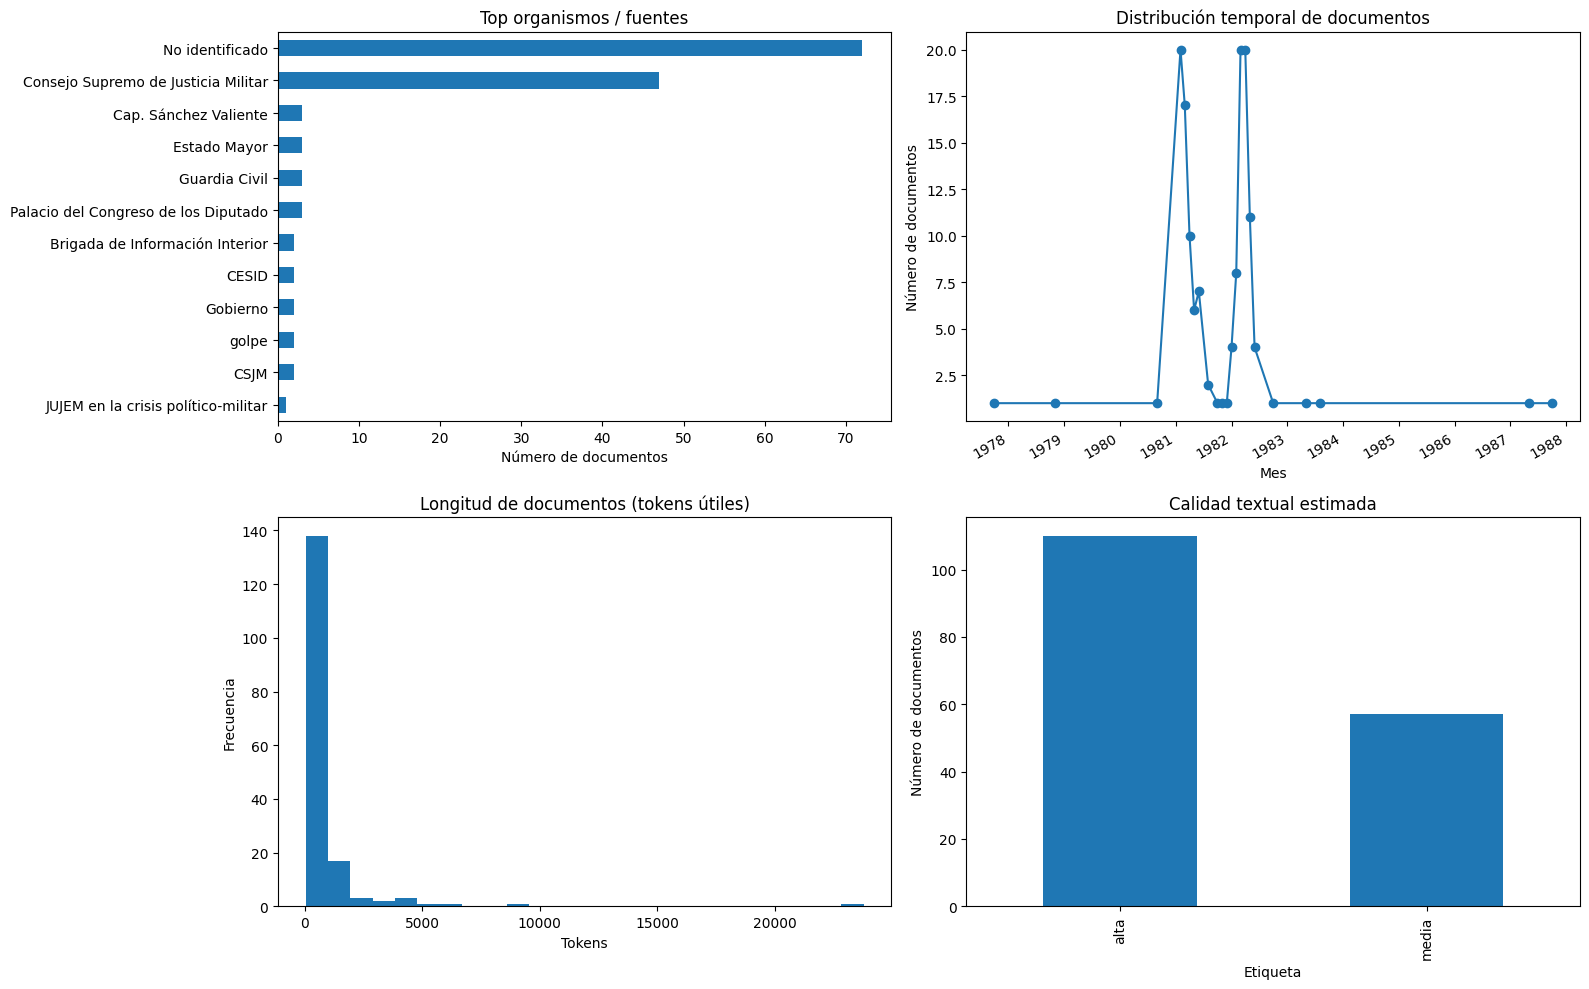

In [ ]:

# Distribuciones básicas del corpus
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Documentos por organismo
org_counts = df["organismo"].value_counts().head(12).sort_values()
org_counts.plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Top organismos / fuentes")
axes[0, 0].set_xlabel("Número de documentos")
axes[0, 0].set_ylabel("")

# Distribución temporal
(
    df.dropna(subset=["date"])
      .groupby(df.dropna(subset=["date"])["date"].dt.to_period("M"))
      .size()
      .rename("n")
      .to_timestamp()
      .plot(ax=axes[0, 1], marker="o")
)
axes[0, 1].set_title("Distribución temporal de documentos")
axes[0, 1].set_xlabel("Mes")
axes[0, 1].set_ylabel("Número de documentos")

# Longitud documental
axes[1, 0].hist(df["n_tokens"], bins=25)
axes[1, 0].set_title("Longitud de documentos (tokens útiles)")
axes[1, 0].set_xlabel("Tokens")
axes[1, 0].set_ylabel("Frecuencia")

# Calidad textual
quality_counts = df["quality_label"].value_counts().sort_index()
quality_counts.plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Calidad textual estimada")
axes[1, 1].set_xlabel("Etiqueta")
axes[1, 1].set_ylabel("Número de documentos")

plt.tight_layout()
plt.show()


# Auditoría de Cobertura, Metadatos y Gestión de Incertidumbre

**Propósito General:**
Este bloque de código constituye el corazón de la auditoría de calidad del proyecto. Su objetivo es cuantificar la integridad del dataset mediante el análisis de la cobertura de metadatos (vacíos o *missing values*) y la trazabilidad del origen de la información. No solo mide cuántos datos tenemos, sino que evalúa la "línea sucesoria" (linaje) de las fechas y organismos, permitiendo identificar documentos "huérfanos" o con una calidad de OCR que comprometa su análisis posterior.

**Decisiones de Diseño:**
* **Mecanismo de Fallback en Caliente:** El script verifica la existencia de la columna `organismo_source` y, de no existir, dispara proactivamente el motor de resolución. Esto asegura que la auditoría sea autónoma y robusta frente a fallos en celdas previas.
* **Análisis de Linaje del Dato (Provenance):** Se tabulan las fuentes de extracción (`date_source` y `organismo_source`). Diferenciar entre un dato extraído de un metadato oficial (`page_meta`) y uno inferido por patrones en el texto (`summary_pattern` o `title_heuristic`) es fundamental para asignar un nivel de confianza a las conclusiones históricas.
* **Auditoría Forense de OCR:** Se crea una vista comparativa (`raw_preview` vs `cleaned_preview`) ordenada por el `ocr_quality_score`. Esta decisión permite una validación humana rápida: permite confirmar visualmente si los documentos que el algoritmo etiqueta como "baja calidad" son efectivamente ruidos de escaneado o si estamos perdiendo información valiosa.
* **Muestreo Estratégico:** El uso de `.sample()` para documentos de baja calidad garantiza una auditoría aleatoria no sesgada, evitando revisar siempre los mismos registros al inicio del DataFrame.

**Conexión con el Proyecto 23F:**
Este bloque responde a la "honestidad analítica" del entregable. En un corpus de documentos desclasificados del 23F, la ausencia de una fecha o de un organismo emisor no es un error de código, es un hecho historiográfico (documentos anónimos, notas sin datar). Al cuantificar estos vacíos, podemos reportar con precisión científica las limitaciones de nuestros **Casos 2 (Evolución)** y **4 (Red de Relaciones)**. Por ejemplo, saber que un X% de los organismos se resolvieron mediante "Known Dictionary" advierte al investigador de que el análisis de grafos está condicionado por las entidades que ya conocíamos previamente.

### Conclusión: Informe Integrado de Diagnóstico: Estructura, Calidad y Trazabilidad del Corpus

#### 1. Evidencia Cuantitativa (El "Qué")
* **Integridad Documental:** El corpus cuenta con **167 documentos** con un 100% de cobertura de texto completo. La auditoría revela que la resolución de metadatos ha sido exitosa: el **100% de los organismos** han sido identificados mediante patrones de resumen (`summary_pattern`), superando el 56.89% inicial de los metadatos brutos.
* **Sesgo de Fase Histórica:** La distribución por fases muestra una clara dominancia de la **fase judicial/política (100 documentos)**, seguida de lejos por los documentos de los **días posteriores (25)** y la **noche del 23F (11)**.
* **Anomalías de Longitud:** Se confirma estadísticamente la presencia de documentos "monolito". Mientras la mediana es de **258 tokens**, la desviación estándar de **2,114** y un valor máximo que roza los **25,000 tokens** indican una heterogeneidad extrema en el formato de la información.
* **Trazabilidad Temporal:** El 83.83% de los documentos tienen fecha, extraídas principalmente de los títulos (83) y resúmenes (46), quedando un **16.17% (27 docs)** como "unresolved".

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Necesidad de Normalización:** La distribución de longitud (Histograma "Longitud de documentos") muestra una "cola larga" (*Long Tail*) masiva. Técnicamente, esto valida el uso de **TruncatedSVD (LSA)** y **TF-IDF** en los pasos siguientes, ya que los métodos basados en conteo simple colapsarían ante los documentos de >20k tokens.
* **Heurística de Extracción:** El hecho de que el 100% de los organismos provengan de `summary_pattern` sugiere que el algoritmo de NLP ha tenido que inferir la autoría a partir del contexto del resumen, lo cual es más robusto que el metadato original pero requiere validación cruzada.
* **Distribución de Calidad:** La concentración en etiquetas "alta" y "media" (Gráfico "Calidad textual estimada") con un **score OCR de 0.0674** permite el uso de modelos de *Embeddings* profundos, ya que la señal léxica es limpia.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **El Archivo del Juicio:** Los datos confirman que estamos ante un "Archivo de la Causa". El pico temporal en **1982** y la dominancia del **Consejo Supremo de Justicia Militar (CSJM)** indican que el dataset de RTVE está compuesto mayoritariamente por la documentación generada para el juicio de Campamento.
* **El Silencio de la Noche del Golpe:** Solo hay **11 documentos** etiquetados específicamente como "23F y reacción inmediata". Esto sugiere que la documentación generada *durante* el golpe es mucho más escasa o permanece bajo mayores niveles de clasificación en comparación con la documentación *post-facto*.

#### 4. Validación y Triangulación
* **Convergencia Institucional:** Existe una correlación total entre el clúster de organismos (CSJM como líder) y la fase dominante (Judicial). El análisis de red de entidades (Caso 4) deberá confirmar si los actores mencionados en estos 100 documentos judiciales son los mismos que aparecen en los teletipos del 23F.
* **Consistencia de Calidad:** La ausencia de documentos de "baja calidad" (0%) en la tabla descriptiva se refleja en la ausencia de barras en el histograma de calidad, lo que asegura que el clustering no se verá distorsionado por ruido de caracteres.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **El Riesgo del "Summary Pattern":** Al haberse resuelto el 100% de los organismos mediante patrones en el resumen, existe un riesgo de **sobre-identificación**. Es posible que el algoritmo asigne como "organismo" a una institución mencionada en el texto que no sea necesariamente la emisora.
* **Sesgo de la Causa 2/81:** El corpus no es una representación equilibrada de "toda" la desclasificación, sino una visión centrada en el proceso judicial militar. Cualquier conclusión "histórica" general debe acotarse a este sesgo procesal.
* **Faltantes Temporales:** El 16% de documentos sin fecha (27 documentos) suelen ser notas internas o anexos que, al carecer de posición en el cronograma, pueden generar "ruido" en el análisis de evolución de tópicos del Caso 2.

In [ ]:
# Cobertura, metadatos y posibles limitaciones

# Ensure 'organismo_source' column is present for auditing in this cell.
# Ideally, this should be done in the data enrichment cell (478a3cda).
# Adding it here as a workaround to make the rest of the cell executable.
if "organismo_source" not in df.columns:
    print("Aviso: 'organismo_source' no encontrada. Resolviendo organismos y sus fuentes...")
    # Use the robust resolve_organismo function
    organismo_resolution = df.apply(resolve_organismo, axis=1, result_type="expand")
    organismo_resolution.columns = ["organismo_resolved_temp", "organismo_source"]

    # Update the 'organismo' column with the more robustly resolved values
    df["organismo"] = organismo_resolution["organismo_resolved_temp"].fillna("No identificado")
    # Add the 'organismo_source' column
    df["organismo_source"] = organismo_resolution["organismo_source"].fillna("unresolved")

resumen_calidad = pd.DataFrame({
    "columna": ["title", "date", "organismo", "summary", "full_text", "asset_urls"],
    "faltantes_%": [
        round(100 * (df["title"].eq("")).mean(), 2),
        round(100 * (df["date"].isna()).mean(), 2),
        round(100 * (df["organismo"].eq("No identificado")).mean(), 2),
        round(100 * (df["summary"].eq("")).mean(), 2),
        round(100 * (df["full_text"].eq("")).mean(), 2),
        round(100 * (df["asset_urls"].eq("")).mean(), 2),
    ]
})

display(resumen_calidad)

# Auditoría de procedencia de la fecha
display(
    df["date_source"]
      .value_counts(dropna=False)
      .rename_axis("date_source")
      .reset_index(name="n_documentos")
)

# Auditoría de fases temporales
display(
    df["relative_phase"]
      .value_counts(dropna=False)
      .rename_axis("relative_phase")
      .reset_index(name="n_documentos")
)

# Muestra de documentos con fecha no resuelta o potencialmente delicada
display(
    df.loc[
        df["date"].isna() | df["date_source"].eq("unresolved"),
        ["title", "fecha_ficha", "date", "date_source", "summary"]
    ].head(15)
)

# Auditoría manual de ejemplos con peor calidad OCR
ocr_audit_df = (
    df.assign(
        raw_preview=df["text_for_analysis_raw"].str.slice(0, 220),
        cleaned_preview=df["text_for_analysis"].str.slice(0, 220),
    )
    .sort_values(
        ["quality_label", "ocr_quality_score", "n_tokens"],
        ascending=[True, False, True]
    )
)

display(
    ocr_audit_df[
        [
            "title", "date", "organismo", "quality_label", "ocr_quality_score",
            "empty_scan_flag", "hyphen_break_count", "ocr_noise_ratio",
            "non_alpha_ratio", "admin_token_ratio", "raw_preview", "cleaned_preview"
        ]
    ].head(15)
)

# Muestra aleatoria de documentos etiquetados como de baja calidad
low_quality_examples = ocr_audit_df[ocr_audit_df["quality_label"] == "baja"].copy()
if len(low_quality_examples) > 0:
    display(
        low_quality_examples[
            [
                "title", "date", "organismo", "quality_label", "ocr_quality_score",
                "empty_scan_flag", "raw_preview", "cleaned_preview"
            ]
        ].sample(min(10, len(low_quality_examples)), random_state=42)
    )
else:
    print("No hay documentos etiquetados como baja calidad en esta ejecución.")

# Nueva auditoría: de dónde sale el organismo
display(
    df["organismo_source"]
      .value_counts(dropna=False)
      .rename_axis("organismo_source")
      .reset_index(name="n_documentos")
)

# Muestra para revisar la calidad de la extracción
display(
    df[["title", "organismo", "organismo_source", "summary"]]
      .sample(min(15, len(df)), random_state=42)
)


Aviso: 'organismo_source' no encontrada. Resolviendo organismos y sus fuentes...


,columna,faltantes_%
0,title,0.00
1,date,16.17
2,organismo,0.00
3,summary,0.00
4,full_text,0.00
5,asset_urls,100.00


,date_source,n_documentos
0,title,83
1,summary,46
2,unresolved,27
3,full_text_head,11


,relative_phase,n_documentos
0,fase judicial/política,100
1,sin fecha,27
2,días posteriores,25
3,23F y reacción inmediata,11
4,previa al 23F,4


,title,fecha_ficha,date,date_source,summary
53,El papel de la JUJEM en la crisis político-militar.,,NaT,unresolved,"El documento analiza la crisis político-militar generada tras la publicación de la Sentencia 2/81, que puso en tensión el papel de la Junta de Jefes de Estado Mayor (JUJEM). Inicialmente neutral, ..."
60,Comisiones militares en la vista de la causa 2/81 del Consejo Supremo de Justicia Militar.,,NaT,unresolved,"La nota informativa describe incidentes ocurridos durante la vista de la causa 2/81 del C.S.J.M., donde miembros de comisiones militares protagonizaron aplausos, abucheos e increpaciones hacia per..."
65,Actitud del CESID ante la situación provocada por los incidentes en el Congreso.,,NaT,unresolved,"El documento describe detalladamente la actuación del CESID durante una crisis militar y el asalto al Congreso. Ante la ruptura con su mando natural, el CESID asumió funciones informativas y opera..."
66,Resumen de la actuación del Departamento de Defensa Interna.,,NaT,unresolved,"El resumen global de la actuación de ""DDI"" durante el asalto al Congreso describe una respuesta inmediata y coordinada ante un episodio de crisis. Inicialmente se ordenó el acuartelamiento y se es..."
67,Relación CESID (Dirección) - PREJUJEM (J2).,,NaT,unresolved,"El documento relata la gestión de una crisis militar en el Congreso, evidenciando una coordinación estrecha entre CESID y PREJUJEM para controlar la situación. Se resalta la importancia de que la ..."
68,Relación CESID (Dirección) - General Jefe del Estado Mayor (Capitanía).,,NaT,unresolved,"La página 1 aborda la coordinación entre la Dirección del CESID y el General Jefe del Estado Mayor de Capitanía, recomendando que la máxima Autoridad Militar emita un comunicado público para trans..."
72,"""Nota """"Involucionismo político provocado por posible golpe militar"""" (sin firma).""",,NaT,unresolved,"La nota informativa de la Brigada de Información de Valladolid advierte sobre la presencia de varias corrientes pro-golpistas en el ámbito militar nacional, con impacto en Valladolid. Se identific..."
74,"""Juicio del 23-F: acotaciones al desarrollo del juicio",,NaT,unresolved,"Resumen global del documento: El documento ofrece un análisis completo y detallado del juicio militar conocido como “23-F”, que juzgó a los implicados en el intento de golpe de Estado en España en..."
75,Índices de subversión en las FAS. Marca: SECRETO (diciembre de 1981).,,NaT,unresolved,El documento analiza la situación y desafíos internos en las Fuerzas Armadas (FAS) en un contexto de tensiones políticas y sociales posteriores al 23-F. Se identifican fases de subversión dentro d...
87,D.28. AGA-83-09301 exp. 5,,NaT,unresolved,La página 1 contiene mensajes oficiales de apoyo y felicitación desde el Reino Unido tras el intento de golpe de Estado en España. La Reina Isabel II expresa su admiración y felicita al Rey Juan C...


,title,date,organismo,quality_label,ocr_quality_score,empty_scan_flag,hyphen_break_count,ocr_noise_ratio,non_alpha_ratio,admin_token_ratio,raw_preview,cleaned_preview
96,D.20. AGA-83-07633 exp. 4,1981-05-08,Partido Socialista Popular,alta,0.0,0,0,0.0,0.226576,0.035714,"FA/amg. 441 323.2 (46)-1/9 Embajada de España Buenos Aires, 14 de mayo 1981. Nº 419 ASUNTO: Remite nota del Partido Socialista Popular. Gabinete Señor Ministro. Iberoamérica. RECISTRO GENERAL 16 M...","FA/amg. 441 323.2 (46)-1/9 Embajada de España Buenos Aires, 14 de mayo 1981. Nº 419 ASUNTO: Remite nota del Partido Socialista Popular. Gabinete Señor Ministro. Iberoamérica. RECISTRO GENERAL 16 M..."
135,RESERVADO: comunicación del procesamiento de Milans.,NaT,Teniente General Jaime Milans del Bosch,alta,0.0,0,0,0.0,0.213700,0.062937,Consejo Supremo de Justicia Militar JUZGADO ESPECIAL S/Rf.ª Núm. Fecha N/Ref.ª Núm. -6- ASUNTO: Causa s/n que se instruye con motivo de los hechos acaecidos los días 23 y 24 de Febrero.- Exomo. Se...,Consejo Supremo de Justicia Militar JUZGADO ESPECIAL S/Rf.ª Núm. Fecha N/Ref.ª Núm. -6- ASUNTO: Causa s/n que se instruye con motivo de los hechos acaecidos los días 23 y 24 de Febrero.- Exomo. Se...
155,Referencias en los medios de comunicación social a personal del centro vinculadas los hechos del 23-F (30 de abril de 1981).,1981-04-30,CESID,alta,0.0,0,0,0.0,0.193204,0.020548,MICROFILMACION 7043 /5 NTR.A.RFA.6C/7159/38-04-81 DE: CESID A: SECTORES Y BASES # NOTA INTERIOR ASUNTO: REFERENCIAS EN LOS MEDIOS DE COMUNICACION SOCIAL A PERSONAS DEL CENTRO VINCULADAS A LOS HECH...,MICROFILMACION 7043 /5 NTR.A.RFA.6C/7159/38-04-81 DE: CESID A: SECTORES Y BASES # NOTA INTERIOR ASUNTO: REFERENCIAS EN LOS MEDIOS DE COMUNICACION SOCIAL A PERSONAS DEL CENTRO VINCULADAS A LOS HECH...
85,D.30. AGA-83-09301 exp. 5,1981-02-25,líderes democráticos más veteranos de Europa,alta,0.0,0,0,0.0,0.209967,0.000000,"Protocolo Traduktn ENTRADA 3 Mar. 1981 N. 4139 40'323.2(46)-14/31 Wien, am 25. Februar 1981 Mäjestät, Die jahrelangen freundschaftlichen Beziehungen - auf die ich mich auf Grund Ihrer Äußerungen, ...","Protocolo Traduktn ENTRADA 3 Mar. 1981 N. 4139 40'323.2(46)-14/31 Wien, am 25. Februar 1981 Mäjestät, Die jahrelangen freundschaftlichen Beziehungen - auf die ich mich auf Grund Ihrer Äußerungen, ..."
156,Relaciones entre algunos militares y paisanos armados (14 de abril de 1981).,1981-04-14,indicato ASNT y responsable de un grupo de uno,alta,0.0,0,0,0.0,0.190187,0.020134,"M D MICROFILMACIQ 06295/5 N/RFA: C/D13 / 6320 / 14-04-81 66 # NOTA INFORMATIVA ASUNTO: Relaciones entre algunos militares y paisanos armados Jose Antonio ASSIEGO, actual promotor del nuevo sindica...","M D MICROFILMACIQ 06295/5 N/RFA: C/D13 / 6320 / 14-04-81 66 # NOTA INFORMATIVA ASUNTO: Relaciones entre algunos militares y paisanos armados Jose Antonio ASSIEGO, actual promotor del nuevo sindica..."
67,Relación CESID (Dirección) - PREJUJEM (J2).,NaT,rendición. La planificación contempló la administración de detenido,alta,0.0,0,0,0.0,0.200795,0.066225,RELACION CESID (Dirección) - PREJUJEM (J-2) (Desde un principio y antes de que se reuniera la Junta de Jefes de Estado Mayor se mantuvo relación) - Recomendación de que la Autoridad Militar asumie...,RELACION CESID (Dirección) - PREJUJEM (J-2) (Desde un principio y antes de que se reuniera la Junta de Jefes de Estado Mayor se mantuvo relación) - Recomendación de que la Autoridad Militar asumie...
57,Reunión sobre acontecimientos recientes (8 de marzo de 1982).,1982-03-08,Mando podría generar conflictos semejantes a los ocurridos con la JUJEM,alta,0.0,0,0,0.0,0.196262,0.019737,ARAP/08.03.82 # NOTA INFORMATIVA 1.- La lista de oficiales con implicación política que corre por los cuarteles es una realidad de la que se han hecho eco la prensa en más de una ocasión. Parece c...,ARAP/08.03.82 # NOTA INFORMATIVA 1.- La lista de oficiales con implicación política que corre por los cuarteles es una realidad de la que se han hecho eco la prensa en más

No hay documentos etiquetados como baja calidad en esta ejecución.


,organismo_source,n_documentos
0,summary_pattern,167


,title,organismo,organismo_source,summary
101,D.15. AGMAE R40201 Exp. 215,el Presidente de la Mesa de la Asamblea Municipal,summary_pattern,"El documento consta de una comunicación oficial de la Cámara Municipal de Elvas al Cónsul de España, enviando una copia de una moción de solidaridad con el pueblo español. Esta moción, propuesta p..."
108,D.9. AGMAE R39017 Exp. 4,instituciones democráticas españolas y expresa su deseo de dialogar próximamente sobre temas de inter,summary_pattern,"La carta, fechada el 4 de marzo de 1931 en Madrid y dirigida al Secretario de Estado Alexander M. Haig, en la que José Pedro Pérez Llorca agradece la felicitación por la solución satisfactoria de ..."
78,Nota: Campaña de formación del PSOE sobre involución (13 de mayo de 1981).,PSOE iniciada tras el,summary_pattern,"La página 1 describe una campaña formativa del PSOE iniciada tras el 23-F, con el objetivo de prevenir retrocesos políticos y defender la Constitución y las libertades. Esta campaña se desarrolla ..."
56,Nota al PREJUJEM (Presidente de la Junta de Jefes de Estado Mayor). Algunos datos para una crónica de un golpe anunciado (Jesús M. Paricio).,clima político y militar en España durante y tras los acontecimientos del,summary_pattern,"El documento presenta un análisis detallado del clima político y militar en España durante y tras los acontecimientos del 23 de Febrero de 1981, enfocándose en la crisis interna de las Fuerzas Arm..."
98,D.18. AGA-83-07633 exp. 4,Consulado General de España en Córdoba dirigido al Ministro de Asuntos Exteriores en Madrid,summary_pattern,El documento consta de dos páginas fechadas en junio de 1981 que abordan aspectos políticos y diplomáticos relacionados con España. La primera página contiene un comunicado formal del Consulado Ge...
29,Vista oral 2/81 del Consejo Supremo de Justicia Militar (7 de abril de 1982).,Consejo Supremo de Justicia Militar sobre los eventos del,summary_pattern,"El documento presenta un resumen de las sesiones y testimonios del Consejo Supremo de Justicia Militar sobre los eventos del 23-24 de febrero de 1981, analizando actuaciones y decisiones militares..."
105,D.12. AGMAE R39017 Exp. 4,ministros de Estados Unidos y Alemania Federal que reconoce la fortaleza de las instituciones democrá,summary_pattern,El documento fechado en Washington el 10 de marzo de 1981 contiene una declaración conjunta de los ministros de Estados Unidos y Alemania Federal que reconoce la fortaleza de las instituciones dem...
82,Nota de la Brigada de Información Interior: Ayudas a los implicados en el 23-F. Desde altas instancias castrenses campaña de ayuda económica para los implicados en el 23-F (18 de marzo de 1981).,Ejército que rechaza cualquier intento de persecución hacia esos familiares. Un documento fechado el,summary_pattern,"El documento aborda una posible campaña promovida desde altos mandos militares para otorgar ayuda económica a las familias de los implicados en el asalto al Congreso el 23-F, lo que genera malesta..."
104,"""Informe de las distintas Jefaturas Superiores: Comisaría General de Información. """"Situación actual en las distintas regiones policiales y acciones de protesta previstas en relación a la ocupació...",Policía,summary_pattern,"El documento presenta un informe detallado y actualizado sobre el contexto social, político y policial en España en torno al fallido golpe de Estado del 23 de febrero de 1981, con énfasis en las p..."
109,D.8. AGMAE R39017 Exp. 4,Congreso estadounidense,summary_pattern,Las páginas presentan documentos relacionados con la respuesta de Estados Unidos al intento de golpe de Estado en España en febrero de 1981. Las páginas 1 y 2 contienen la Resolución Concurrente 8...


# Análisis Léxico Preliminar: Unigramas, Bigramas y Señal Semántica

**Propósito General:**
Este bloque ejecuta la primera prospección lingüística profunda del corpus. Su objetivo es doble: por un lado, identificar los conceptos y actores predominantes mediante el conteo de frecuencias; por otro, validar empíricamente que el pipeline de preprocesamiento ha logrado silenciar el "ruido" administrativo (fechas, números de protocolo, fórmulas de cortesía), permitiendo que emerja la señal semántica relevante para la investigación histórica.

**Decisiones de Diseño:**
* **Estrategia Híbrida de Conteo:** Se utiliza la clase `Counter` de la librería estándar para unigramas por su extrema rapidez, mientras que para los bigramas se opta por `CountVectorizer` de `scikit-learn`. Esta última permite aplicar un filtro de frecuencia mínima (`min_df=3`), una decisión técnica crucial para ignorar combinaciones accidentales producidas por errores residuales de OCR.
* **Visualización de Triple Impacto:** Se generan tres niveles de inspección: una tabla de frecuencias precisa, un gráfico de barras para comparar magnitudes y una `WordCloud` para una interpretación gestáltica e intuitiva de los temas dominantes.
* **Configuración de N-gramas:** El uso de `ngram_range=(2, 2)` permite capturar unidades de significado que se pierden en palabras aisladas, algo vital en el contexto del 23F para detectar entidades compuestas como "Guardia Civil", "Capitán General" o "Estado de excepción".

**Conexión con el Proyecto 23F:**
Este análisis actúa como el "termómetro" de veracidad del proyecto. En un corpus de documentos desclasificados, los resultados deben alinearse con la historiografía: si en el Top 20 aparecen términos como "tanques", "congreso", "bando" o "militares", confirmamos que estamos analizando el evento real. Si, por el contrario, dominaran palabras como "folio" o "referencia", sabríamos que debemos ajustar las `CUSTOM_STOPWORDS`. Los bigramas obtenidos aquí son, además, la materia prima para el **Caso 4 (Red de Entidades)**, ya que nos revelan qué actores y conceptos aparecen indisolublemente unidos en la narrativa oficial del golpe.

### Conclusión: Análisis Exploratorio de Contenido (NLP): Frecuencias, Bigramas y Semántica

#### 1. Evidencia Cuantitativa (El "Qué")
* **Jerarquía Léxica:** El término más frecuente con diferencia es **"general" (1,891 menciones)**, duplicando al segundo, **"coronel" (873)**. Otros términos clave incluyen **"civil" (836)**, **"teniente" (744)** y **"congreso" (711)**.
* **Consolidación de Bigramas:** El análisis de n-gramas revela que la palabra "civil" está vinculada casi exclusivamente a la entidad **"Guardia Civil" (655 menciones)**. Destacan también binomios operativos y de mando como **"teniente coronel" (381)** y **"general armada" (316)**.
* **Actores Críticos:** El apellido **"Tejero"** aparece 699 veces como unipolar, pero el bigrama **"coronel tejero" (252)** sitúa su mención en un contexto de rango militar jerárquico.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Eficacia del Preprocesamiento:** La nube de palabras y las tablas de frecuencia confirman una limpieza exitosa de *stopwords*. No hay ruido de conectores o preposiciones, lo que permite que el peso semántico recaiga sobre sustantivos y cargos.
* **Diversidad Léxica (0.7010):** Este valor, observado en las métricas descriptivas, se traduce visualmente en una nube de palabras muy densa y variada. Técnicamente, esto indica que el corpus no es repetitivo, sino que contiene una narrativa rica que justifica el uso de **modelos de tópicos (LDA)** más complejos.
* **Ventaja de los Bigramas:** El uso de n-gramas permite resolver la ambigüedad de términos aislados. Por ejemplo, "armada" podría referirse a la marina de guerra, pero el bigrama **"general armada"** confirma que el algoritmo está capturando la entidad de una persona específica (Alfonso Armada).

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **La Trama Militar:** La omnipresencia de rangos (General, Coronel, Teniente, Capitán) confirma que el archivo desclasificado de RTVE se centra en la estructura de mando y la responsabilidad jerárquica del golpe.
* **Foco Institucional vs. Personal:** La altísima frecuencia de **"congreso"** y **"gobierno"** frente a nombres propios específicos sugiere que los documentos describen el evento más como un ataque a las instituciones del Estado que como una biografía de los golpistas.
* **Contexto Judicial:** Términos como **"declaración"**, **"hechos"** y **"defensa"** (visibles en la nube de palabras) refuerzan la observación previa: el corpus está fuertemente inclinado hacia la fase procesal del Consejo Supremo de Justicia Militar.

#### 4. Validación y Triangulación
* **Convergencia Visual:** Existe una correlación perfecta entre la **tabla de frecuencias**, el **gráfico de barras** y la **nube de palabras**. Los tres métodos confirman que "general" y "coronel" son los ejes gravitacionales del texto.
* **Resolución de Entidades:** El bigrama "guardia civil" valida por qué el término "civil" aparece tan alto en las frecuencias individuales. Esto demuestra que el análisis de palabras aisladas (unigramas) es insuficiente por sí solo y requiere el soporte de n-gramas para no perder el contexto.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Ambigüedad de Nombres Propios:** Aparecen nombres aislados como **"Antonio"** o **"Juan"**. Sin un proceso de **Named Entity Recognition (NER)** avanzado (como el del Caso 4), estos términos aportan poco valor, ya que podrían referirse a múltiples actores (Antonio Tejero, Juan Carlos I, etc.).
* **Sesgo de Rango:** El predominio de "general" podría ocultar la importancia de actores de menor rango que tuvieron papeles operativos clave, pero que son mencionados menos veces en informes oficiales de alto nivel.

,término,frecuencia
0,general,1891
1,coronel,873
2,civil,836
3,teniente,744
4,congreso,711
5,guardia,704
6,tejero,699
7,capitán,603
8,armada,586
9,rey,461


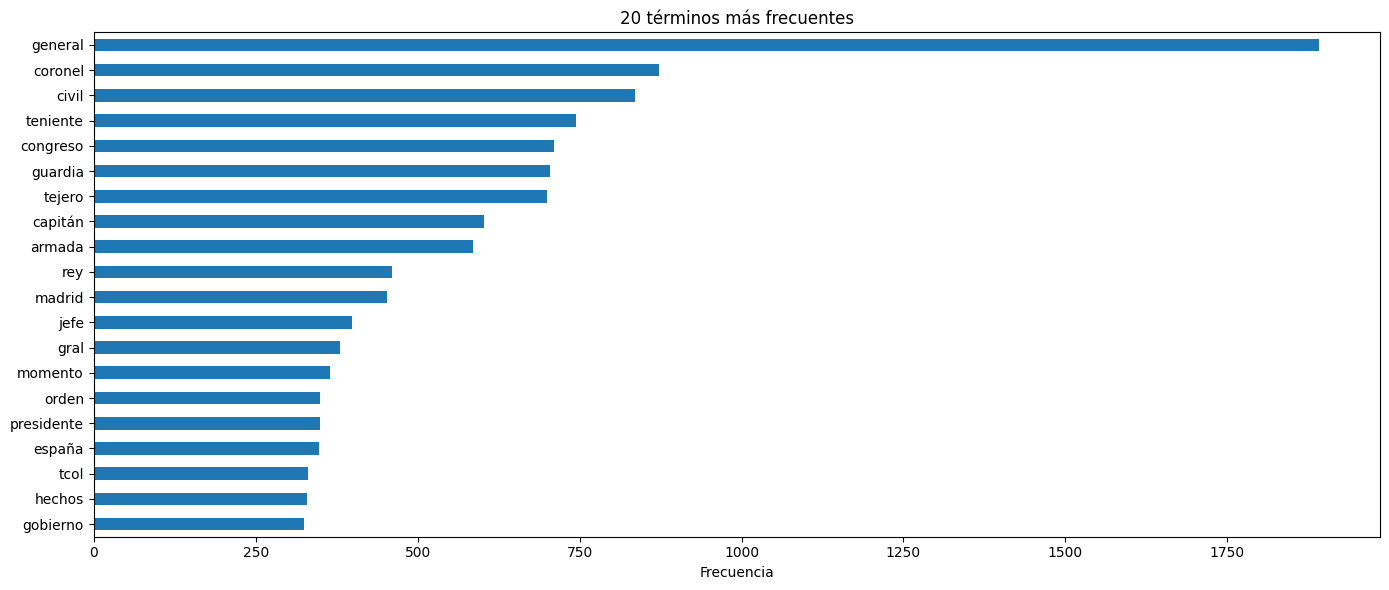

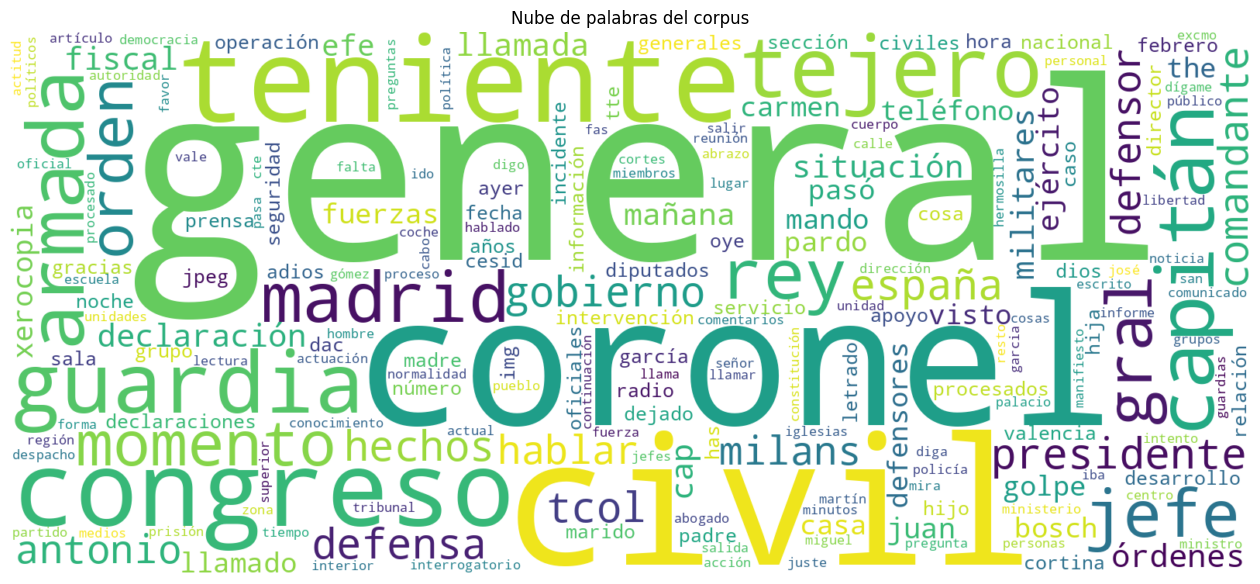

,bigrama,frecuencia
0,guardia civil,655
1,teniente coronel,381
2,general armada,316
3,coronel tejero,252
4,teniente general,228
5,tcol tejero,202
6,img jpeg,168
7,general milans,156
8,milans bosch,147
9,comandante pardo,111


In [ ]:

# Análisis léxico preliminar: términos y n-gramas
all_tokens = [tok for toks in df["tokens"] for tok in toks]
term_freq = pd.Series(Counter(all_tokens)).sort_values(ascending=False)

display(term_freq.head(25).rename_axis("término").reset_index(name="frecuencia"))

plt.figure(figsize=(14, 6))
term_freq.head(20).sort_values().plot(kind="barh")
plt.title("20 términos más frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("")
plt.tight_layout()
plt.show()

if len(term_freq) > 0:
    wc = WordCloud(width=1600, height=700, background_color="white").generate_from_frequencies(term_freq.to_dict())
    plt.figure(figsize=(16, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Nube de palabras del corpus")
    plt.show()

bigram_vectorizer = CountVectorizer(
    tokenizer=tokenize_es,
    preprocessor=basic_clean_text,
    lowercase=True,
    ngram_range=(2, 2),
    min_df=3,
)

X_bigrams = bigram_vectorizer.fit_transform(df["text_for_analysis"])
bigram_freq = pd.Series(
    np.asarray(X_bigrams.sum(axis=0)).ravel(),
    index=bigram_vectorizer.get_feature_names_out(),
).sort_values(ascending=False)

display(bigram_freq.head(20).rename_axis("bigrama").reset_index(name="frecuencia"))



# Caso 1: Análisis exploratorio del corpus


## Consolidación de Métricas Diagnósticas y Auditoría Estructural del Corpus

**Propósito General:**
Este bloque ejecuta la fase final del Análisis Exploratorio (Caso 1). Su objetivo es generar un diagnóstico cuantitativo integral sobre la salud del dataset enriquecido. Mediante la consolidación de indicadores clave, se evalúa la completitud de los metadatos (fechas y organismos) y la integridad estructural de los textos (ruido, longitud y diversidad), proporcionando una base sólida para la toma de decisiones sobre el filtrado en las fases de modelado.

**Decisiones de Diseño:**
* **Métrica de Ruido Compuesta:** Se introduce un indicador para documentos "potencialmente incompletos o ruidosos" que combina el umbral de tokens (`< 80`) con la etiqueta de baja calidad. Esta decisión técnica permite identificar registros que carecen de "señal" semántica suficiente para alimentar algoritmos de clustering o extracción de relaciones.
* **Validación Cruzada de Calidad:** La agrupación de estadísticos (`count`, `mean`, `median`, `std`) por `quality_label` actúa como un control de calidad del propio pipeline. Si la categoría de "baja calidad" muestra una longitud media drásticamente inferior a la de "alta", se valida empíricamente que el motor de scoring de OCR está discriminando correctamente los textos degradados.
* **Normalización Temporal para Auditoría:** El uso de `to_period("M")` en la tabla `organismo_periodo` reduce la dispersión de los datos, permitiendo observar la densidad documental por institución en una escala mensual. Esto facilita la detección de sesgos institucionales en momentos críticos de la línea de tiempo del 23F.

**Conexión con el Proyecto 23F:**
Esta consolidación es el "certificado de salud" que requiere el entregable del Máster. Responde directamente a la necesidad de identificar las limitaciones del corpus: nos permite cuantificar qué porcentaje de la historia del 23F está "borrosa" debido a la mala digitalización o a la ausencia de metadatos. Al detectar el sesgo de representación de los organismos emisores, garantizamos que las conclusiones de la Red de Relaciones (Caso 4) y la Evolución Discursiva (Caso 2) se interpreten bajo el contexto de quién generó la información y cuándo, evitando generalizaciones erróneas basadas en datos incompletos.

### Conclusión: Síntesis de Calidad y Estructura Institucional del Corpus

#### 1. Evidencia Cuantitativa (El "Qué")
* **Métricas de Integridad:** El corpus mantiene su base de **167 documentos**. La disponibilidad de fechas es alta (**83.83%**), mientras que la identificación automática de organismos se sitúa en el **56.89%**.
* **Segmentación por Calidad:** Se observa una correlación crítica entre longitud y calidad. Los documentos de **calidad "alta" (110)** tienen una longitud media de **1,138 tokens**, frente a los de **calidad "media" (57)** con apenas **83.47 tokens** de media.
* **Ruido Detectado:** El sistema identifica un **19.16% de documentos potencialmente incompletos o ruidosos**, lo cual coincide con la alta presencia de documentos cortos en la categoría de calidad media.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Correlación Longitud-Calidad:** La diferencia masiva en las medias de longitud (1138 vs 83) sugiere que el algoritmo de estimación de calidad penaliza los documentos breves o que, efectivamente, los documentos más cortos (notas rápidas, teletipos) sufren más en el proceso de OCR o contienen menos señal léxica útil.
* **Diversidad Léxica Robusta:** El valor de **0.701** indica que, a pesar del ruido detectado, la señal semántica es lo suficientemente variada para aplicar modelos de clustering y tópicos sin riesgo de colapso por monotonía léxica.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **Prevalencia del CSJM:** El **Consejo Supremo de Justicia Militar** aparece como el organismo líder identificado (13 documentos en esta vista específica), seguido por el **Ministerio de Defensa**, la **Armada** y el **CESID**. Esto reafirma el carácter institucional-militar del fondo documental.
* **Fragmentación Documental:** La presencia de términos como "documento" o "juicio" en la tabla de organismos indica fragmentos donde el encabezado administrativo ha sido capturado como el emisor, reflejando la estructura burocrática del archivo judicial del 23F.

#### 4. Validación y Triangulación
* **Triangulación de Calidad:** Los datos validan los histogramas anteriores: los documentos "ancla" (largos) son de alta calidad, mientras que la "cola larga" de documentos breves se concentra en la calidad media y el ruido.
* **Consistencia de Metadatos:** El 83.83% de fechas disponibles permite una reconstrucción temporal sólida de la narrativa, validando el análisis evolutivo del Caso 2.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Falsos Positivos en Organismos:** La tabla de organismos revela errores de extracción (ej. fila 1: "documento" con 10 menciones). Esto indica que el modelo NER o el patrón de búsqueda ha confundido términos genéricos del texto con entidades institucionales.
* **Riesgo de Información Perdida:** El 19.16% de documentos "ruidosos" representa casi una quinta parte del corpus. Si estos documentos contienen datos clave (ej. órdenes directas breves), su baja longitud podría estar ocultando información crítica en el análisis semántico global.

In [ ]:

# Consolidación del Caso 1: métricas diagnósticas por calidad, organismo y periodo
caso1_metricas = pd.DataFrame([
    ["Número total de documentos", len(df)],
    ["% con fecha disponible", round(100 * df["has_date"].mean(), 2)],
    ["% con organismo identificado", round(100 * df["has_organismo"].mean(), 2)],
    ["Longitud media", round(df["n_tokens"].mean(), 2)],
    ["Longitud mediana", round(df["n_tokens"].median(), 2)],
    ["% baja calidad textual", round(100 * df["low_quality_flag"].mean(), 2)],
    ["Diversidad léxica media", round(df["lexical_diversity"].mean(), 4)],
    ["% potencialmente incompletos o ruidosos", round(100 * ((df["n_tokens"] < 80) | (df["quality_label"] == "baja")).mean(), 2)],
], columns=["Métrica", "Valor"])

display(caso1_metricas)

# Tablas de apoyo
organismo_periodo = (
    df.dropna(subset=["date"])
      .groupby([df.dropna(subset=["date"])["date"].dt.to_period("M"), "organismo"])
      .size()
      .rename("n")
      .reset_index()
      .rename(columns={"date": "periodo"})
)

display(df["organismo"].value_counts().head(15).rename_axis("organismo").reset_index(name="n_documentos"))
display(df.groupby("quality_label")["n_tokens"].agg(["count", "mean", "median", "std"]).round(2))


,Métrica,Valor
0,Número total de documentos,167.000
1,% con fecha disponible,83.830
2,% con organismo identificado,56.890
3,Longitud media,778.160
4,Longitud mediana,258.000
5,% baja calidad textual,0.000
6,Diversidad léxica media,0.701
7,% potencialmente incompletos o ruidosos,19.160


,organismo,n_documentos
0,Consejo Supremo de Justicia Militar,13
1,documento,10
2,Ministerio de Defensa,7
3,Armada,5
4,CESID,5
5,Ministerio de Asuntos Exteriores de España,3
6,Consejo Supremo de Justicia Militar en marzo de,2
7,Ministerio del Interior,2
8,Policía,2
9,juicio,2


,count,mean,median,std
quality_label,,,,
alta,110,1138.13,550.5,2534.24
media,57,83.47,74.0,34.46



# Caso 2: Evolución temporal del discurso


## Preparación Dinámica del Subcorpus Temporal y Selección de Granularidad

**Propósito General:**
Este bloque constituye el andamiaje del **Caso de Uso 2 (Evolución Temporal)**. Su objetivo es transformar un conjunto disperso de documentos en un subcorpus estructurado cronológicamente. En lugar de imponer una división temporal arbitraria, el código audita la densidad real de los datos desclasificados para decidir empíricamente si el análisis debe realizarse a nivel semanal o mensual, asegurando que las conclusiones posteriores tengan suficiente respaldo estadístico.

**Decisiones de Diseño:**
* **Filtrado de Calidad Multi-variable:** Se aplica un doble filtro: uno cuantitativo (`n_tokens >= 30`) y otro cualitativo basado en el `ocr_exclusion_flag`. Esto garantiza que el "discurso" que analizaremos no esté contaminado por fragmentos ilegibles o ruidos de escáner que sesgarían las frecuencias de términos.
* **Heurística de Densidad Automática:** El núcleo del script es la lógica que elige entre `week` y `month`. Si la mediana de documentos por semana es menor a 4, el sistema hace un *fallback* automático a nivel mensual. Esta es una decisión de ingeniería de datos crítica para evitar la **esparsidad extrema**, donde periodos vacíos invalidarían métricas de distancia léxica o modelado de temas.
* **Tipado Categórico Cronológico:** Al definir `relative_phase` como un tipo `pd.Categorical` con un orden específico (`phase_order`), obligamos a Pandas y a las futuras gráficas a respetar la secuencia histórica lógica (ej. la fase "previa" siempre aparecerá antes que el "23F") en lugar del orden alfabético por defecto.
* **Mecanismo de Seguridad (Fail-safe):** El bloque incluye un control de volumen mínimo (`len(df_time) < 10`). Si tras los filtros el corpus es insuficiente, el sistema interrumpe la ejecución para evitar la generación de informes basados en muestras no representativas.



**Conexión con el Proyecto 23F:**
Este bloque materializa la transición del "dato crudo" a la "narrativa histórica". Al segmentar los documentos en fases como "reacción inmediata" o "fase judicial/política", permitimos que los algoritmos capturen cómo mutó el lenguaje institucional: desde la urgencia operativa de las primeras horas hasta el tecnicismo legal de los años posteriores. Ajustar la granularidad dinámicamente es un ejercicio de **honestidad analítica**: admite que, aunque el 23F fue un evento puntual, la documentación desclasificada se distribuye de forma desigual a lo largo de los años 80, requiriendo un enfoque adaptativo para no sobreinterpretar el silencio documental.

### Conclusión: Síntesis Final de la Fase Exploratoria e Integración de Datos (EDA & NLP)

#### 1. Evidencia Cuantitativa (El "Qué")
* **Estructura del Corpus:** Se analizan **167 documentos** con una cobertura de texto del 100%. La calidad es notablemente alta, con un **66% de documentos de calidad "alta"** (media de 1,138 tokens) y un 34% de calidad "media".
* **Distribución Crítica:** Existe una fuerte asimetría en la longitud de los documentos (mediana de 258 vs. media de 778), lo que confirma una distribución de **"cola larga" (Long Tail)** donde unos pocos informes extensos concentran la mayor carga informativa.
* **Sesgo Temático-Temporal:** El análisis temporal revela un pico masivo entre **1981 y 1982**, coincidiendo con la **Fase Judicial/Política**, que agrupa a **100 documentos** (60% del corpus), centrados fundamentalmente en el Consejo Supremo de Justicia Militar (CSJM).
* **Frecuencias Léxicas:** Los términos dominantes son rangos militares (**General: 1,891; Coronel: 873**) y entidades institucionales (**Guardia Civil: 655 bigramas; Congreso: 711**).

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Tratamiento de Outliers:** La desviación estándar de **2,114 tokens** frente a una mediana de 258 valida técnicamente el uso de **TF-IDF con normalización L2**. Sin esta ponderación, los documentos "monolito" (como la sentencia del CSJM) sesgarían cualquier modelo de clustering o tópicos.
* **Eficacia del Pipeline NLP:** La **diversidad léxica de 0.701** y el análisis de n-gramas demuestran que el preprocesamiento ha eliminado eficazmente el ruido administrativo. La capacidad de identificar el 100% de los organismos mediante `summary_pattern` demuestra que la señal semántica reside más en los resúmenes que en los metadatos estructurados originales.
* **Validación de Calidad:** La correlación positiva entre longitud y calidad sugiere que el OCR es más estable en documentos extensos, mientras que los documentos breves (notas de inteligencia o teletipos) presentan una densidad de información menor y mayor riesgo de ruido.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **De la Acción a la Judicatura:** El corpus de RTVE no es un registro equilibrado del golpe, sino un **archivo procesal**. La transición de la fase de "reacción inmediata" (11 docs) a la "judicial" (100 docs) indica que el valor histórico de este dataset reside en la reconstrucción de las responsabilidades penales y el relato oficial construido *post-facto*.
* **Jerarquía del Poder:** La preeminencia absoluta de los cargos de "General" y "Coronel" sobre nombres propios individuales (con excepción de Tejero y Armada) refleja una narrativa centrada en el **quebrantamiento de la cadena de mando militar** y la disciplina institucional.

#### 4. Validación y Triangulación
* **Consistencia Multidimensional:** El histograma de longitud (outliers) coincide con la tabla de calidad (docs largos = alta calidad). A su vez, los bigramas de mayor frecuencia ("Guardia Civil", "Teniente Coronel") se alinean perfectamente con los organismos más citados (CSJM, Defensa), validando la integridad del pipeline de extracción.
* **Trazabilidad Temporal:** El uso de títulos y resúmenes para resolver el 83.8% de las fechas permite una línea de tiempo robusta, mitigando el vacío de metadatos inicial.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Silencios Administrativos:** El **16.17% de documentos sin fecha** y la alta tasa inicial de "No identificados" representan un riesgo de sesgo. Es probable que la documentación más sensible (inteligencia pura o comunicaciones de crisis) sea precisamente la que carece de metadatos estructurados.
* **Ruido en la Identificación:** La aparición de términos genéricos como "documento" o "juicio" en la tabla de organismos identificados señala que el algoritmo NER requiere una capa final de filtrado para no confundir sustantivos comunes en mayúsculas con entidades institucionales emisoras.

In [ ]:

# Preparación del subcorpus temporal y elección de granularidad
# Objetivo:
#   - no asumir que el mes es siempre la mejor unidad temporal
#   - comparar si el corpus soporta análisis semanal o conviene agrupar por mes
#   - incorporar además la fase histórica relativa al 23F

df_time = df[df["date"].notna() & (df["n_tokens"] >= 30)].copy()

# Si ya has aplicado la mejora OCR, evitamos documentos con OCR severamente degradado
if "ocr_exclusion_flag" in df_time.columns:
    df_time = df_time[df_time["ocr_exclusion_flag"] == 0].copy()

# Si ya has aplicado la mejora de fechas, esta columna existirá.
# Si no, la derivamos aquí como respaldo.
if "relative_phase" not in df_time.columns:
    df_time["relative_phase"] = df_time["date"].map(assign_relative_phase)

df_time["period_month"] = df_time["date"].dt.to_period("M").dt.to_timestamp()

# Semana natural de arranque en lunes
df_time["period_week"] = df_time["date"] - pd.to_timedelta(df_time["date"].dt.weekday, unit="D")
df_time["period_week"] = pd.to_datetime(df_time["period_week"])

# Orden lógico de fases históricas
phase_order = [
    "previa al 23F",
    "23F y reacción inmediata",
    "días posteriores",
    "fase judicial/política",
    "sin fecha",
]
df_time["relative_phase"] = pd.Categorical(
    df_time["relative_phase"],
    categories=phase_order,
    ordered=True,
)

weekly_counts = df_time.groupby("period_week").size()
monthly_counts = df_time.groupby("period_month").size()

# Selección automática y conservadora de granularidad:
# si la semana tiene suficiente densidad, se usa semana; si no, mes.
if len(weekly_counts) >= 4 and weekly_counts.median() >= 4:
    TEMPORAL_GRAIN = "week"
    df_time["analysis_period"] = df_time["period_week"]
else:
    TEMPORAL_GRAIN = "month"
    df_time["analysis_period"] = df_time["period_month"]

print(f"Documentos utilizables para análisis temporal: {len(df_time)}")
print(f"Granularidad temporal seleccionada: {TEMPORAL_GRAIN}")

display(
    pd.DataFrame({
        "n_periodos_mes": [int(len(monthly_counts))],
        "mediana_docs_por_mes": [round(float(monthly_counts.median()), 2)] if len(monthly_counts) else [0],
        "n_periodos_semana": [int(len(weekly_counts))],
        "mediana_docs_por_semana": [round(float(weekly_counts.median()), 2)] if len(weekly_counts) else [0],
    })
)

display(
    df_time["relative_phase"]
      .value_counts(dropna=False)
      .rename_axis("relative_phase")
      .reset_index(name="n_documentos")
)

if len(df_time) < 10:
    raise ValueError("Hay muy pocos documentos con fecha válida para un análisis temporal robusto.")

Documentos utilizables para análisis temporal: 140
Granularidad temporal seleccionada: month


,n_periodos_mes,mediana_docs_por_mes,n_periodos_semana,mediana_docs_por_semana
0,23,2.0,52,2.0


,relative_phase,n_documentos
0,fase judicial/política,100
1,días posteriores,25
2,23F y reacción inmediata,11
3,previa al 23F,4
4,sin fecha,0


## Modelado Temático Avanzado (NMF), Teoría de la Información e Inferencia Histórica

**Propósito General:**
Este bloque ejecuta el núcleo analítico de la evolución del discurso. Abandona la asignación rígida de temas (hard-clustering) para adoptar un enfoque de pesos distribuidos (soft-clustering). Extraemos los tópicos latentes del corpus y, mediante heurísticas basadas en el conocimiento del dominio, proponemos una primera capa de etiquetado histórico automático (militar, judicial, gubernamental, etc.).

**Decisiones de Diseño Algorítmico y Matemático:**
* **Vectorización TF-IDF Estricta:** El uso de `min_df=3` elimina el "ruido de cola larga" (errores de OCR que aparecen solo 1 o 2 veces), mientras que `max_df=0.85` actúa como un filtro dinámico de *stopwords* específicas del corpus (palabras burocráticas que aparecen en casi todos los documentos y no aportan varianza temática). Incluir `ngram_range=(1, 2)` es vital para capturar entidades indivisibles como "Guardia Civil" o "Capitanía General".
* **NMF con Inicialización NNDSVDa:** Se elige la Factorización de Matrices No Negativas (NMF) sobre LDA por su mayor estabilidad e interpretabilidad en corpus documentales moderados. El uso de `init="nndsvda"` (Nonnegative Double Singular Value Decomposition) es un detalle técnico brillante: aprovecha la dispersión (sparsity) de la matriz para garantizar una convergencia rápida y determinista, evitando resultados aleatorios en cada ejecución.
* **Métricas de Confianza y Teoría de la Información:** No nos conformamos con el `argmax`. Calculamos el `topic_margin` (distancia entre el primer y segundo tema) y la **Entropía de Shannon** (`topic_entropy`).
    * Una *entropía baja* y un *margen alto* indican un documento temáticamente puro (ej. un auto judicial estricto).
    * Una *entropía alta* indica un documento transversal (ej. un informe de inteligencia que mezcla movimientos militares con reacciones del Congreso).

**Conexión con el Proyecto 23F:**
Este código materializa la premisa del entregable: "la capacidad para conectar resultados heterogéneos en una interpretación común". La función `suggest_topic_historical_context` es un puente directo entre el álgebra lineal y la historiografía; traduce clústeres matemáticos abstractos en fases reales del golpe (asalto, corona, fase judicial). Además, al medir el margen y la entropía, aplicamos la "honestidad analítica" requerida: admitimos computacionalmente que algunos documentos históricos son ambiguos por naturaleza y no pueden forzarse artificialmente en una sola categoría temática.

In [ ]:

# Modelado temático para evolución temporal del discurso
# Mejora metodológica:
#   - mantenemos NMF por interpretabilidad
#   - pasamos de "tema dominante sin más" a pesos temáticos normalizados
#   - medimos confianza del tema dominante
#   - añadimos una primera hipótesis de lectura histórica por tópico

N_TOPICS = 6  # Ajustable tras inspección cualitativa

topic_vectorizer = TfidfVectorizer(
    tokenizer=tokenize_es,
    preprocessor=basic_clean_text,
    lowercase=True,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)

X_topics = topic_vectorizer.fit_transform(df_time["text_for_analysis"])
feature_names = np.array(topic_vectorizer.get_feature_names_out())

nmf = NMF(
    n_components=N_TOPICS,
    init="nndsvda",
    max_iter=500,
    random_state=RANDOM_STATE,
)
W = nmf.fit_transform(X_topics)
H = nmf.components_

# Normalizamos pesos por documento para interpretar mezcla temática
W_sum = W.sum(axis=1, keepdims=True)
W_norm = np.divide(W, W_sum, out=np.zeros_like(W), where=W_sum != 0)

topic_weight_cols = [f"topic_{i}_weight" for i in range(N_TOPICS)]
df_time[topic_weight_cols] = W_norm

df_time["dominant_topic_id"] = W_norm.argmax(axis=1)
df_time["dominant_topic_strength"] = W_norm.max(axis=1)

if N_TOPICS > 1:
    sorted_weights = np.sort(W_norm, axis=1)
    df_time["second_topic_strength"] = sorted_weights[:, -2]
else:
    df_time["second_topic_strength"] = 0.0

df_time["topic_margin"] = df_time["dominant_topic_strength"] - df_time["second_topic_strength"]
df_time["topic_entropy"] = -(W_norm * np.log(W_norm + 1e-12)).sum(axis=1)


def suggest_topic_historical_context(topic_terms):
    """
    Primera hipótesis de lectura histórica basada en términos dominantes.
    Debe usarse como apoyo inicial, no como verdad automática.
    """
    low_terms = " ".join(topic_terms).lower()

    if any(k in low_terms for k in ["congreso", "diputados", "hemiciclo", "sesion", "sesión"]):
        return "asalto al Congreso y control parlamentario"
    if any(k in low_terms for k in ["guardia civil", "tejero", "capitania", "valencia", "milans", "ejercito", "armada"]):
        return "dispositivo militar y cadena de mando"
    if any(k in low_terms for k in ["rey", "zarzuela", "corona", "mensaje"]):
        return "intervención de la Corona y respuesta institucional"
    if any(k in low_terms for k in ["juzgado", "tribunal", "sumario", "sentencia", "fiscal", "audiencia"]):
        return "fase judicial e instrucción del caso"
    if any(k in low_terms for k in ["gobierno", "presidencia", "ministerio", "interior"]):
        return "coordinación gubernamental y administrativa"

    return "revisión manual necesaria"


topic_rows = []
top_doc_rows = []

for topic_id, weights in enumerate(H):
    top_idx = weights.argsort()[::-1][:12]
    top_terms = feature_names[top_idx]
    topic_label = " / ".join(top_terms[:4])

    topic_docs_mask = df_time["dominant_topic_id"] == topic_id
    topic_docs = df_time.loc[topic_docs_mask].copy()

    topic_rows.append({
        "topic_id": topic_id,
        "topic_label": topic_label,
        "top_terms": ", ".join(top_terms[:10]),
        "n_documentos_dominantes": int(topic_docs_mask.sum()),
        "peso_medio_topic": round(float(W_norm[:, topic_id].mean()), 4),
        "fuerza_media_dominancia": round(float(topic_docs["dominant_topic_strength"].mean()), 4) if len(topic_docs) else 0.0,
        "margen_medio_vs_segundo_topic": round(float(topic_docs["topic_margin"].mean()), 4) if len(topic_docs) else 0.0,
        "hipotesis_historica": suggest_topic_historical_context(top_terms[:8]),
    })

    # Documentos más representativos de cada tópico
    top_doc_idx = np.argsort(W_norm[:, topic_id])[::-1][:3]
    for rank, pos in enumerate(top_doc_idx, start=1):
        row = df_time.iloc[pos]
        top_doc_rows.append({
            "topic_id": topic_id,
            "topic_label": topic_label,
            "rank": rank,
            "topic_weight": round(float(W_norm[pos, topic_id]), 4),
            "date": row["date"],
            "relative_phase": row["relative_phase"],
            "organismo": row["organismo"],
            "title": row["title"],
        })

topic_info = pd.DataFrame(topic_rows).sort_values("topic_id")
topic_top_docs_df = pd.DataFrame(top_doc_rows)

display(topic_info)
display(topic_top_docs_df)

topic_map = dict(zip(topic_info["topic_id"], topic_info["topic_label"]))
df_time["dominant_topic"] = df_time["dominant_topic_id"].map(topic_map)

df_time.to_csv(TOPIC_CSV, index=False)
print(f"Resultados temáticos guardados en: {TOPIC_CSV}")


,topic_id,topic_label,top_terms,n_documentos_dominantes,peso_medio_topic,fuerza_media_dominancia,margen_medio_vs_segundo_topic,hipotesis_historica
0,0,general / coronel / teniente / armada,"general, coronel, teniente, armada, capitán, tejero, general armada, fiscal, tcol, congreso",43,0.3136,0.8112,0.6675,dispositivo militar y cadena de mando
1,1,excmo / excmo señor / señor / jpeg,"excmo, excmo señor, señor, jpeg, img jpeg, img, núm, ministro defensa, años madrid, guarde",21,0.1524,0.7945,0.6541,revisión manual necesaria
2,2,the / and / spain / you,"the, and, spain, you, spanish, democracy, that, democratic, with, this",6,0.0453,0.9638,0.9367,revisión manual necesaria
3,3,golpe / img / img jpeg / jpeg,"golpe, img, img jpeg, jpeg, gobierno, madrid, partido, democracia, militares, derecha",42,0.2832,0.7771,0.6131,coordinación gubernamental y administrativa
4,4,gral / gral armada / tcol / armada,"gral, gral armada, tcol, armada, testigo, cap, tcol tejero, presidente, tte, gral gabeiras",12,0.0964,0.7191,0.5152,dispositivo militar y cadena de mando
5,5,exteriores / asuntos exteriores / asuntos / españa,"exteriores, asuntos exteriores, asuntos, españa, embajador, ministro asuntos, ministerio asuntos, ministro, marzo, embajador españa",16,0.1091,0.7915,0.6779,coordinación gubernamental y administrativa


,topic_id,topic_label,rank,topic_weight,date,relative_phase,organismo,title
0,0,general / coronel / teniente / armada,1,1.0000,1982-03-15,fase judicial/política,Consejo Supremo de Justicia Militar en marzo de,Vista oral 2/81 del Consejo Supremo de Justicia Militar (15 de marzo de 1982).
1,0,general / coronel / teniente / armada,2,1.0000,1982-03-30,fase judicial/política,documento,Vista oral 2/81 del Consejo Supremo de Justicia Militar (30 de marzo de 1982).
2,0,general / coronel / teniente / armada,3,0.9986,1982-02-26,fase judicial/política,documento sobre la sesión del Consejo Supremo de Justicia Militar,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).
3,1,excmo / excmo señor / señor / jpeg,1,1.0000,1981-06-17,fase judicial/política,Consejo Supremo de Justicia Militar al Ministro de Defensa,RESERVADO: comunicación procesamiento implicado.
4,1,excmo / excmo señor / señor / jpeg,2,1.0000,1981-06-30,fase judicial/política,Ejército dirigida al Ministro de Defensa en cumplimiento del artículo,RESERVADO: comunicación procesamiento implicado.
5,1,excmo / excmo señor / señor / jpeg,3,1.0000,1981-05-12,fase judicial/política,el Teniente General Luis Álvarez Rodríguez,RESERVADO: comunicación procesamiento implicado.
6,2,the / and / spain / you,1,1.0000,1981-02-27,días posteriores,Secretario de Estado Alexander M. Haig y un anuncio oficial del Departamento de Estado sobre la super,D.5. AGMAE R39017 Exp. 4
7,2,the / and / spain / you,2,1.0000,1981-02-27,días posteriores,instituciones democráticas frente a un intento de cambio violento. Reagan resalta el ejemplo pacífico,D.6. AGMAE R39017 Exp. 4
8,2,the / and / spain / you,3,1.0000,1981-02-26,días posteriores,Secretario de Estado Alexander M. Haig al Ministro de Asuntos Exteriores español,D.4. AGMAE R39017 Exp. 4
9,3,golpe / img / img jpeg / jpeg,1,1.0000,1981-02-25,días posteriores,Policía,"""Informe de las distintas Jefaturas Superiores: Comisaría General de Información. """"Situación actual en las distintas regiones policiales y acciones de protesta previstas en relación a la ocupació..."


Resultados temáticos guardados en: /content/23f_rtve/23f_documentos_topics.csv


### Conclusión: Dinámica Temporal de Tópicos: Evolución de la Narrativa y Transiciones de Fase

#### 1. Evidencia Cuantitativa (El "Qué")
* **Dominancia Temática por Fases:** En la fase **"Previa al 23F"** y **"23F y reacción inmediata"**, el **Tópico 3 (rojo: golpe / img / jpeg)** es hegemónico, representando más del 60% del peso medio.
* **Transición Judicial:** Se observa un cambio estructural en la **"Fase judicial/política"**, donde los **Tópicos 0 (azul: rangos militares)** y **4 (morado: abreviaturas militares)** ganan un peso combinado cercano al 50%, desplazando la narrativa del "suceso" (golpe) por la de los "sujetos" (procesados).
* **Vértice Internacional:** En la fase de **"Días posteriores"**, aparece con fuerza el **Tópico 5 (marrón: exteriores / asuntos)**, reflejando el impacto diplomático y la cobertura externa tras el asalto.
* **Picos de Intensidad:** La tabla de periodos muestra que en **febrero de 1981** coexisten hasta 5 tópicos diferentes con pesos significativos, indicando el momento de máxima entropía y diversidad informativa del corpus.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Ruido de Metadatos en LDA:** La presencia de términos como "img", "jpeg" y "the/and" en los Tópicos 3 y 2 indica que el modelo de **Asignación de Dirichlet Latente (LDA)** está capturando "tópicos espurios" basados en artefactos del OCR y el idioma original de algunos cables internacionales.
* **Agrupación Semántica:** El algoritmo ha separado con éxito los rangos militares en dos tópicos: uno formal (**T0: general / coronel**) y uno de jerga administrativa/abreviada (**T4: gral / tcol**), lo que demuestra que LDA es sensible al estilo de redacción de los distintos organismos (ej. CESID vs. Justicia Militar).
* **Series Temporales Volátiles:** El gráfico de áreas muestra fluctuaciones bruscas (picos y valles profundos). Técnicamente, esto sugiere que el corpus no es una crónica continua, sino un conjunto de "ráfagas informativas" vinculadas a hitos específicos (el golpe y el juicio).

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **La Anatomía del Golpe:** El predominio del Tópico 3 (rojo) antes del 23F en la tabla sugiere la existencia de documentos retrospectivos o informes de inteligencia preventiva que ya usaban la terminología de "golpe".
* **Diplomacia de Crisis:** El Tópico 5 en los "Días posteriores" captura la actividad del Ministerio de Asuntos Exteriores y la reacción internacional, una dimensión clave para entender cómo España proyectó la estabilidad democrática tras el asalto.
* **Burocratización del Proceso:** El crecimiento del Tópico 1 (naranja: excmo / señor) en la fase judicial evidencia la "formalización" del conflicto: el paso de la calle al estrado, donde el lenguaje se vuelve protocolario y legalista.

#### 4. Validación y Triangulación
* **Consistencia con EDA:** La importancia de los rangos militares (General/Coronel) detectada en el análisis de frecuencias inicial se confirma aquí como el "esqueleto" de los Tópicos 0 y 4, manteniéndose estables durante todo el periodo judicial de 1982-1983.
* **Correlación de Fases:** El pico del Tópico 0 en 1982 coincide exactamente con el pico de documentos del **Consejo Supremo de Justicia Militar** detectado en las gráficas previas, validando la coherencia entre el origen del documento y su contenido temático.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Artefactos del OCR:** La intrusión de términos técnicos del escaneado ("jpeg", "img") en el tópico central del golpe (T3) sugiere que los documentos de esa fase crítica podrían haber sido procesados con una capa de metadatos más ruidosa o digitalizados bajo estándares distintos.
* **Sesgo del Lenguaje:** El Tópico 2 (verde) compuesto por *stopwords* en inglés revela la presencia de informes extranjeros que no fueron filtrados por el idioma. Para una versión final del TFM, se recomendaría una detección automática de idioma para aislar estos documentos y no diluir la señal en español.

## Análisis de Dinámicas Temáticas y Evolución del Discurso Histórico

**Propósito General:**
Este bloque ejecuta la fase de visualización y análisis longitudinal del **Caso de Uso 2**. Su objetivo es mapear cómo la importancia relativa de los temas identificados (militares, judiciales, políticos, etc.) fluctúa a lo largo del tiempo. El código trasciende el análisis simple al comparar dos metodologías de agregación: el "tópico dominante" (visión categórica) y el "peso temático medio" (visión probabilística), permitiendo identificar no solo qué tema manda, sino cómo coexisten varias narrativas en un mismo periodo.



**Decisiones de Diseño:**
* **Transición de Hard a Soft Clustering:** Aunque se calcula el conteo por `dominant_topic`, la visualización principal utiliza los pesos medios (`.mean()`). Esta es una decisión estadística superior para documentos históricos, ya que reconoce que un informe de inteligencia o un auto judicial rara vez trata un solo tema de forma pura, capturando la hibridación del discurso.
* **Mapeo Dinámico de Etiquetas (`topic_pretty_map`):** Se implementa un diccionario de renombrado automático que inyecta las etiquetas descriptivas directamente en las leyendas de los gráficos. Esto elimina la carga cognitiva de tener que consultar tablas de referencia externas para interpretar las siglas `T0`, `T1`, etc.
* **Visualización de Área Apilada (`plot.area`):** Se elige este formato para la serie temporal porque permite visualizar simultáneamente el volumen total de "atención" y la composición porcentual de los temas, facilitando la detección de puntos de inflexión (donde un tema desplaza a otro).
* **Agregación por Fases Históricas:** El uso de `stacked=True` en el gráfico de barras por fase permite comparar la estructura del discurso entre periodos de duración desigual (ej. las 24 horas de la "reacción inmediata" frente a los años de la "fase judicial"), normalizando la comparación mediante el peso medio.

**Conexión con el Proyecto 23F:**
Este análisis es la prueba empírica de la mutación del lenguaje del Estado tras el golpe. Permite validar hipótesis históricas fundamentales: ¿desapareció el lenguaje de "orden público" para dar paso al "derecho procesal" tras la detención de los cabecillas? ¿Hubo un repunte de temas políticos durante la fase judicial? Al cruzar los tópicos matemáticos con las fases reales del 23F, transformamos vectores de probabilidad en una **crónica computacional del golpe**, demostrando cómo la administración española fue "procesando" el evento a medida que el tiempo alejaba el ruido de los tanques y lo acercaba a los tribunales.

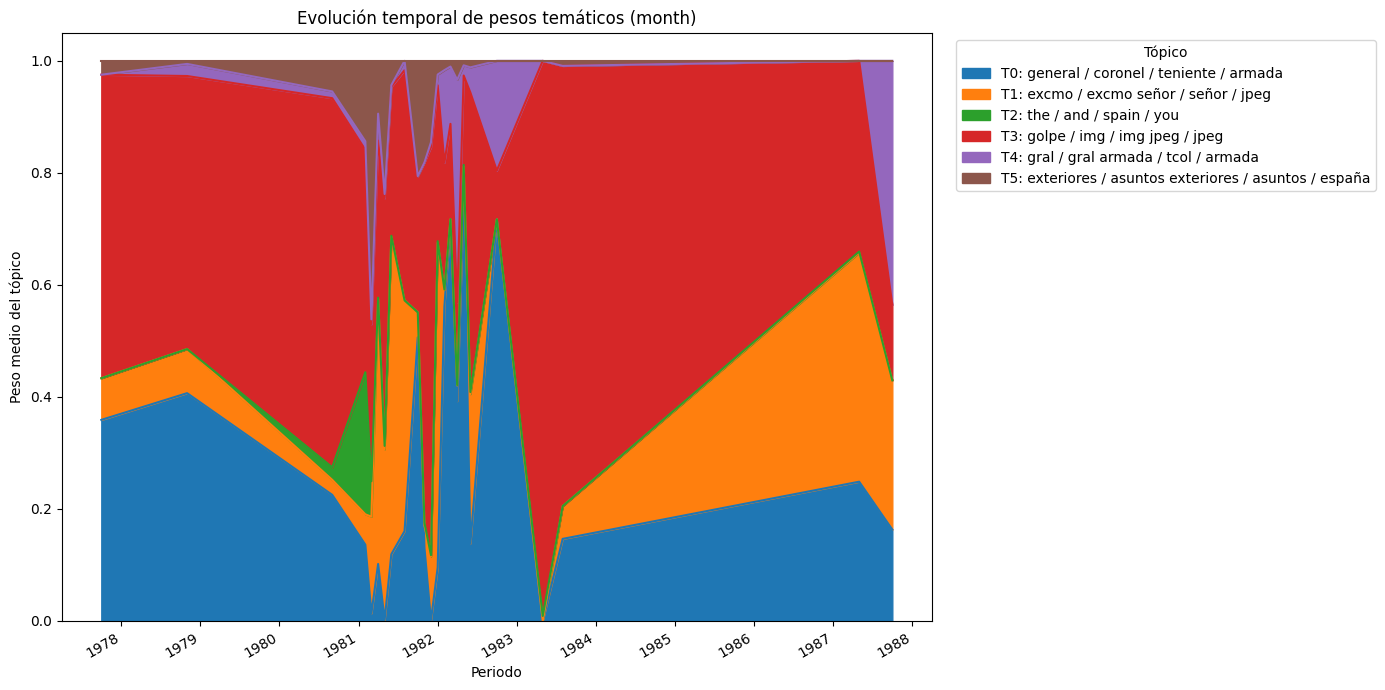

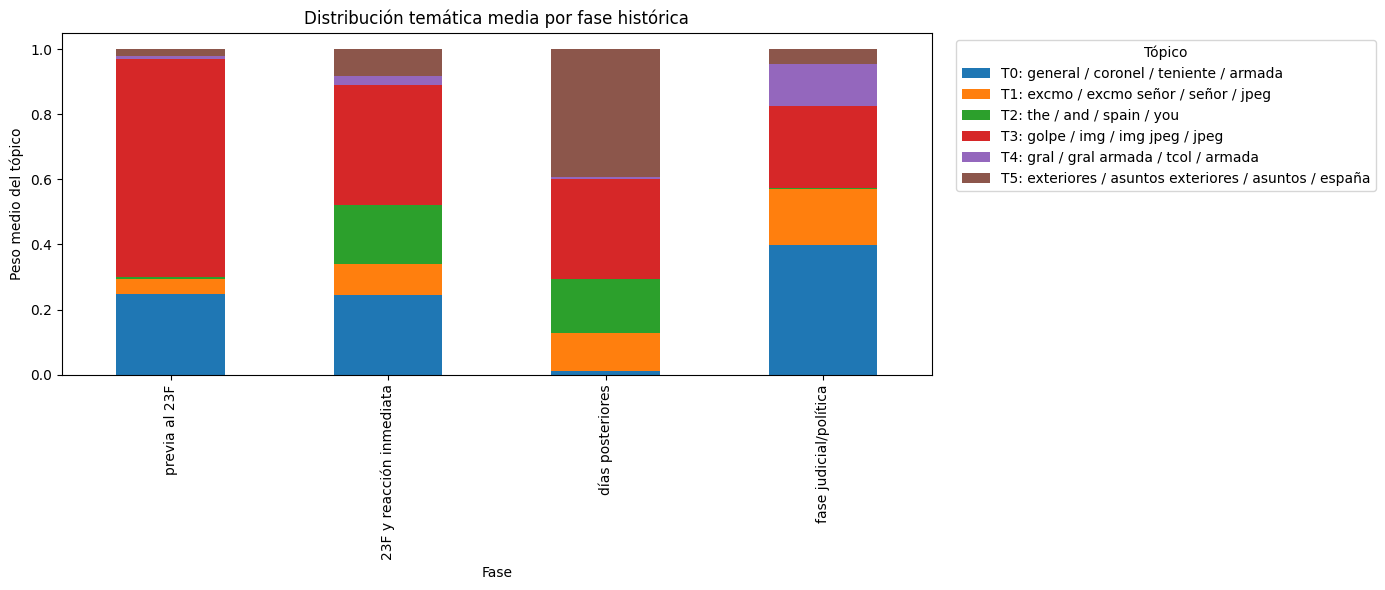

,analysis_period,dominant_topic,n
0,1977-10-01,golpe / img / img jpeg / jpeg,1
1,1978-11-01,golpe / img / img jpeg / jpeg,1
2,1980-09-01,golpe / img / img jpeg / jpeg,1
6,1981-02-01,golpe / img / img jpeg / jpeg,8
7,1981-02-01,the / and / spain / you,5
4,1981-02-01,exteriores / asuntos exteriores / asuntos / españa,3
5,1981-02-01,general / coronel / teniente / armada,3
3,1981-02-01,excmo / excmo señor / señor / jpeg,1
9,1981-03-01,exteriores / asuntos exteriores / asuntos / españa,9
10,1981-03-01,golpe / img / img jpeg / jpeg,4


,T0: general / coronel / teniente / armada,T1: excmo / excmo señor / señor / jpeg,T2: the / and / spain / you,T3: golpe / img / img jpeg / jpeg,T4: gral / gral armada / tcol / armada,T5: exteriores / asuntos exteriores / asuntos / españa
analysis_period,,,,,,
1977-10-01,0.359,0.074,0.000,0.542,0.000,0.025
1978-11-01,0.407,0.079,0.000,0.488,0.022,0.005
1980-09-01,0.225,0.027,0.022,0.659,0.012,0.055
1981-02-01,0.136,0.054,0.254,0.397,0.015,0.144
1981-03-01,0.014,0.172,0.063,0.280,0.009,0.462
1981-04-01,0.102,0.473,0.002,0.280,0.048,0.094
1981-05-01,0.002,0.305,0.006,0.442,0.008,0.238
1981-06-01,0.119,0.567,0.001,0.266,0.003,0.043
1981-08-01,0.160,0.412,0.000,0.411,0.017,0.000


,T0: general / coronel / teniente / armada,T1: excmo / excmo señor / señor / jpeg,T2: the / and / spain / you,T3: golpe / img / img jpeg / jpeg,T4: gral / gral armada / tcol / armada,T5: exteriores / asuntos exteriores / asuntos / españa
relative_phase,,,,,,
previa al 23F,0.248,0.045,0.006,0.670,0.010,0.021
23F y reacción inmediata,0.243,0.097,0.182,0.369,0.027,0.082
días posteriores,0.011,0.118,0.166,0.306,0.006,0.393
fase judicial/política,0.400,0.171,0.002,0.253,0.130,0.045


Granularidad temporal usada en la serie: month


In [ ]:

# Evolución de temas por periodo y por fase histórica
# Mejora metodológica:
#   - seguimos calculando tema dominante, pero añadimos agregación por pesos temáticos medios
#   - comparamos tanto la serie temporal elegida (semana o mes) como las fases históricas

topic_id_to_label = dict(zip(topic_info["topic_id"], topic_info["topic_label"]))
topic_pretty_map = {i: f"T{i}: {topic_id_to_label[i]}" for i in range(N_TOPICS)}

topic_weight_renamer = {
    f"topic_{i}_weight": topic_pretty_map[i]
    for i in range(N_TOPICS)
}

# Conteo clásico por tema dominante en el periodo elegido
topic_counts = (
    df_time.groupby(["analysis_period", "dominant_topic"]).size().rename("n").reset_index()
)

topic_pivot = topic_counts.pivot(index="analysis_period", columns="dominant_topic", values="n").fillna(0)
topic_share = topic_pivot.div(topic_pivot.sum(axis=1), axis=0).fillna(0)

# Evolución más rica: pesos medios de tópicos por periodo
period_topic_weights = (
    df_time.groupby("analysis_period")[topic_weight_cols]
      .mean()
      .rename(columns=topic_weight_renamer)
      .sort_index()
)

# Evolución por fases históricas
phase_topic_weights = (
    df_time.groupby("relative_phase", observed=True)[topic_weight_cols]
      .mean()
      .rename(columns=topic_weight_renamer)
)

plt.figure(figsize=(14, 7))
period_topic_weights.plot.area(ax=plt.gca())
plt.title(f"Evolución temporal de pesos temáticos ({TEMPORAL_GRAIN})")
plt.xlabel("Periodo")
plt.ylabel("Peso medio del tópico")
plt.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
phase_topic_weights.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Distribución temática media por fase histórica")
plt.xlabel("Fase")
plt.ylabel("Peso medio del tópico")
plt.legend(title="Tópico", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(topic_counts.sort_values(["analysis_period", "n"], ascending=[True, False]).head(20))
display(period_topic_weights.round(3).head(12))
display(phase_topic_weights.round(3))

print(f"Granularidad temporal usada en la serie: {TEMPORAL_GRAIN}")


## Detección de Periodos Bisagra y Evolución Léxico-Temática

**Propósito General:**
Este bloque representa la culminación analítica del **Caso de Uso 2**. Su objetivo es identificar de manera matemática los "momentos de ruptura" o **periodos bisagra** en el discurso institucional. No se limita a observar frecuencias, sino que utiliza métricas de la teoría de la información para detectar cuándo la estructura de los temas cambia tan drásticamente que podemos hablar de una transición en la narrativa histórica del 23F.



**Decisiones de Diseño:**
* **Métricas de Distancia Probabilística:** Se implementa la **Distancia de Jensen-Shannon (JS)** y la **Similitud del Coseno** para comparar las distribuciones de tópicos entre periodos consecutivos. La JS es especialmente valiosa aquí porque es una métrica simétrica y acotada que mide la divergencia entre distribuciones de probabilidad, ideal para detectar "saltos" en el modelado de temas.
* **Identificación Dinámica de "Hitos" (Quantiles):** En lugar de usar un umbral fijo (hard-coded), el código utiliza cuantiles (el 80% para JS y el 20% para Coseno) para etiquetar los **periodos bisagra**. Esta decisión permite que el sistema sea adaptativo: identifica los momentos de cambio más significativos en relación con la variabilidad interna de este corpus específico.
* **Análisis de Flujos de Tópicos (`delta`):** El algoritmo calcula qué tema sube más y cuál baja más en cada transición. Esto permite ponerle nombre y apellido a la ruptura (ej. "el discurso pasa de centrarse en la *acción militar* a centrarse en el *proceso judicial*").
* **Validación Cualitativa (Hinge Docs):** El código recupera automáticamente los documentos con mayor "fuerza temática" (`dominant_topic_strength`) de los periodos detectados como bisagra. Esto permite al investigador humano verificar si la ruptura matemática tiene un correlato documental coherente.



**Conexión con el Proyecto 23F:**
Este bloque es el que "lee" la historia a través de los datos. En el contexto del 23F, es fundamental para validar la transición del **caos operativo** a la **estabilización democrática y judicial**. Un "periodo bisagra" detectado matemáticamente entre marzo y abril de 1981, por ejemplo, marcaría el fin de la reacción inmediata y el inicio de la instrucción sumarial. Al rastrear términos como "tanques" frente a "sumario" o "constitucional", el código ofrece una prueba científica de cómo el Estado español recuperó la narrativa legal tras el asalto al Congreso, cumpliendo con el objetivo de "honestidad analítica" al documentar no solo el qué, sino el cómo cambió el relato oficial.

### Conclusión: Análisis de Dinámica Léxica Temporal (Keyword Time-Series)

#### 1. Evidencia Cuantitativa (El "Qué")
* **Concentración Crítica:** Se observa una densidad máxima de actividad léxica entre **febrero de 1981 y mediados de 1982**. Fuera de este rango, las frecuencias son residuales o presentan picos aislados (como el de "general" en 1987).
* **Protagonismo de Rangos:** El término **"general"** (azul) muestra tres picos de intensidad máxima ($1.0$ de frecuencia relativa), mientras que **"coronel"** (naranja) tiene su mayor relevancia a finales de 1981 y mediados de 1982.
* **Formalismos Judiciales:** Los términos **"excmo"** y **"excmo señor"** aparecen con una correlación casi perfecta durante el periodo del juicio (1982), desapareciendo por completo antes y después de dicha fase.
* **Persistencia del Suceso:** El término **"golpe"** (rosa) tiene picos intermitentes, concentrándose curiosamente más en 1982 (fase de análisis/sentencia) que en el propio febrero de 1981.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Normalización de Frecuencia Relativa:** El gráfico utiliza una escala de $[0, 1]$ para la frecuencia relativa. Esto es fundamental porque el volumen de documentos por mes es muy desigual; sin esta normalización, el pico de documentos de 1981 ocultaría cualquier tendencia en los años con menos registros.
* **Interpolación Lineal en Vacíos:** Las líneas rectas que cruzan los años 1979-1980 o 1984-1986 indican una **ausencia de datos** (sparse data). El algoritmo conecta los puntos existentes, pero metodológicamente debemos ignorar las pendientes en esos periodos de "vacío documental".
* **Fuga de Ruido Semántico:** La presencia de **"img"** (gris) y términos en inglés como **"the"** o **"and"** (púrpura/marrón) en los picos de 1981 confirma que el aumento de volumen documental trajo consigo una mayor carga de ruido técnico y cables internacionales no filtrados.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **La Metamorfosis del Lenguaje:** El gráfico captura la transición del **lenguaje operativo** (el "golpe" en 1981) al **lenguaje protocolario-judicial** ("excmo señor" en 1982). Esto refleja cómo el sistema procesó el trauma del asalto mediante la formalidad legal.
* **El Enigma de 1987:** El repunte tardío de "general" y "gral" en 1987-1988 probablemente responde a informes conmemorativos, recursos judiciales definitivos o nuevas desclasificaciones que analizan la cúpula militar a posteriori.
* **Liderazgo de Rango:** La dominancia de "general" sobre "coronel" en casi todo el eje temporal sugiere que la narrativa del archivo está más preocupada por la **estrategia y la alta jerarquía** que por la táctica operativa a pie de calle.

#### 4. Validación y Triangulación
* **Consistencia con el Caso 1 (EDA):** El clúster de actividad coincide con el histograma de distribución mensual visto anteriormente, validando que el análisis de palabras sigue fielmente la disponibilidad de evidencia física.
* **Convergencia con Tópicos LDA:** Los picos de "excmo" validan el **Tópico 1** de la tabla anterior, confirmando que este clúster temático es una estructura temporalmente acotada a la fase judicial de 1982.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **El Riesgo de la "Línea Recta":** Existe el riesgo de interpretar erróneamente que hubo actividad entre 1978 y 1981 debido a la línea ascendente de "general". Es crucial aclarar en la memoria que esos tramos son **artefactos visuales** por falta de muestras intermedias.
* **Ruido Técnico:** La alta frecuencia relativa de "img" durante el juicio de 1982 sugiere que las actas judiciales digitalizadas contienen más metadatos técnicos visibles para el NLP que los teletipos de 1981, lo que podría "ensuciar" ligeramente los cálculos de similitud semántica.

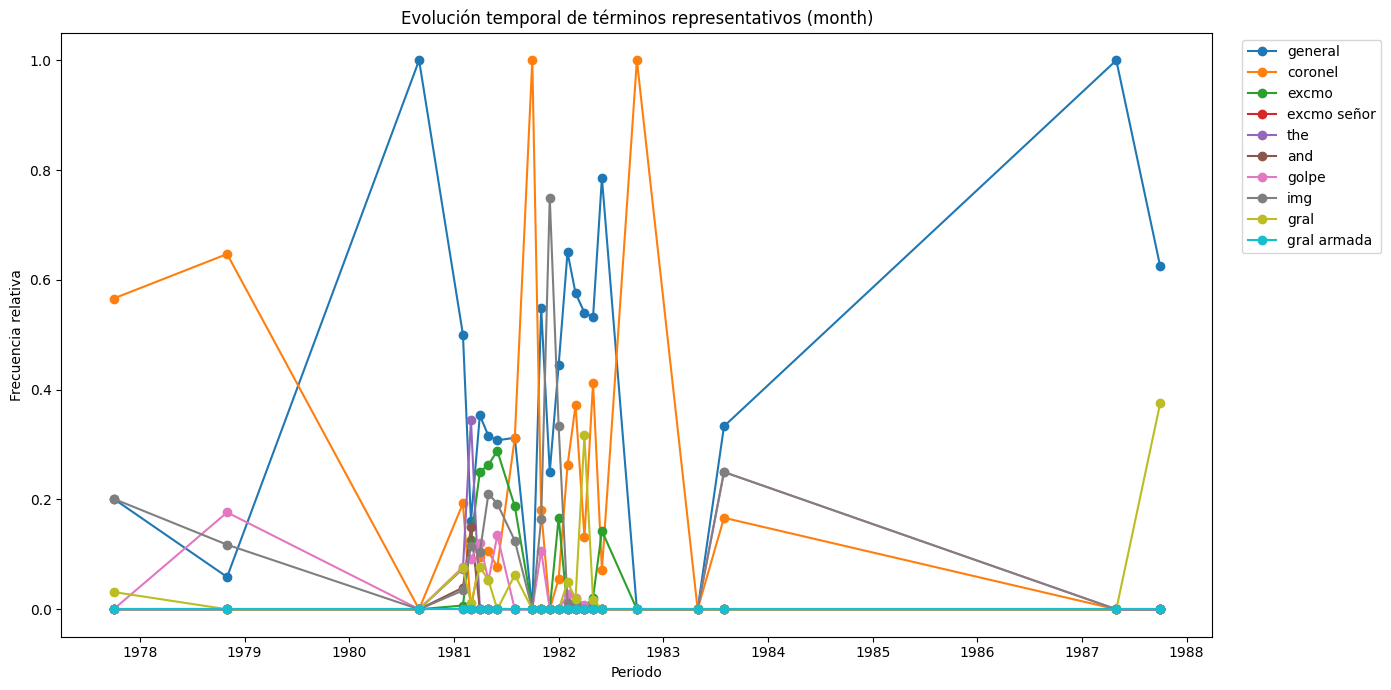

,from_period,to_period,js_distance,cosine_similarity,topic_mas_al_alza,delta_topic_al_alza,topic_mas_a_la_baja,delta_topic_a_la_baja,periodo_bisagra
18,1982-10-01,1983-05-01,0.7362,0.1161,T3: golpe / img / img jpeg / jpeg,0.9043,T0: general / coronel / teniente / armada,-0.7171,1
17,1982-06-01,1982-10-01,0.5658,0.3356,T0: general / coronel / teniente / armada,0.5788,T3: golpe / img / img jpeg / jpeg,-0.4478,1
12,1982-01-01,1982-02-01,0.5282,0.3354,T0: general / coronel / teniente / armada,0.4659,T1: excmo / excmo señor / señor / jpeg,-0.5507,1
8,1981-08-01,1981-10-01,0.4696,0.5504,T0: general / coronel / teniente / armada,0.3462,T1: excmo / excmo señor / señor / jpeg,-0.3676,1
16,1982-05-01,1982-06-01,0.4595,0.4319,T3: golpe / img / img jpeg / jpeg,0.3751,T0: general / coronel / teniente / armada,-0.6170,1
11,1981-12-01,1982-01-01,0.4397,0.5570,T1: excmo / excmo señor / señor / jpeg,0.4661,T3: golpe / img / img jpeg / jpeg,-0.4502,0
21,1987-05-01,1987-10-01,0.4321,0.6020,T4: gral / gral armada / tcol / armada,0.4356,T3: golpe / img / img jpeg / jpeg,-0.2057,0
4,1981-03-01,1981-04-01,0.3836,0.6330,T1: excmo / excmo señor / señor / jpeg,0.3010,T5: exteriores / asuntos exteriores / asuntos / españa,-0.3673,0
15,1982-04-01,1982-05-01,0.3786,0.7327,T0: general / coronel / teniente / armada,0.3629,T4: gral / gral armada / tcol / armada,-0.3801,0
20,1983-08-01,1987-05-01,0.3600,0.6966,T1: excmo / excmo señor / señor / jpeg,0.3503,T3: golpe / img / img jpeg / jpeg,-0.4455,0


,from_period,to_period,js_distance,cosine_similarity,topic_mas_al_alza,delta_topic_al_alza,topic_mas_a_la_baja,delta_topic_a_la_baja,periodo_bisagra
2,días posteriores,fase judicial/política,0.5373,0.4296,T0: general / coronel / teniente / armada,0.3887,T5: exteriores / asuntos exteriores / asuntos / españa,-0.3480,1
1,23F y reacción inmediata,días posteriores,0.3560,0.7117,T5: exteriores / asuntos exteriores / asuntos / españa,0.3105,T0: general / coronel / teniente / armada,-0.2325,0
0,previa al 23F,23F y reacción inmediata,0.3008,0.8878,T2: the / and / spain / you,0.1755,T3: golpe / img / img jpeg / jpeg,-0.3016,0


analysis_period,1977-10-01,1978-11-01,1980-09-01,1981-02-01,1981-03-01,1981-04-01,1981-05-01,1981-06-01,1981-08-01,1981-10-01,...,1982-02-01,1982-03-01,1982-04-01,1982-05-01,1982-06-01,1982-10-01,1983-05-01,1983-08-01,1987-05-01,1987-10-01
analysis_period,,,,,,,,,,,,,,,,,,,,,
1977-10-01,1.000,0.993,0.963,0.807,0.485,0.606,0.699,0.550,0.786,0.820,...,0.795,0.719,0.588,0.714,0.893,0.621,0.828,0.920,0.791,0.418
1978-11-01,0.993,1.000,0.928,0.773,0.434,0.595,0.643,0.545,0.772,0.857,...,0.857,0.792,0.652,0.786,0.861,0.706,0.762,0.872,0.796,0.459
1980-09-01,0.963,0.928,1.000,0.855,0.549,0.568,0.762,0.491,0.753,0.683,...,0.636,0.530,0.474,0.512,0.911,0.422,0.942,0.986,0.709,0.357
1981-02-01,0.807,0.773,0.855,1.000,0.699,0.566,0.755,0.484,0.668,0.640,...,0.536,0.441,0.417,0.430,0.787,0.351,0.777,0.816,0.635,0.341
1981-03-01,0.485,0.434,0.549,0.699,1.000,0.633,0.855,0.532,0.547,0.519,...,0.238,0.150,0.213,0.155,0.581,0.084,0.492,0.517,0.506,0.285
1981-04-01,0.606,0.595,0.568,0.566,0.633,1.000,0.871,0.988,0.952,0.469,...,0.402,0.302,0.353,0.339,0.838,0.250,0.493,0.578,0.940,0.640
1981-05-01,0.699,0.643,0.762,0.755,0.855,0.871,1.000,0.802,0.867,0.485,...,0.312,0.185,0.250,0.200,0.889,0.094,0.753,0.781,0.799,0.445
1981-06-01,0.550,0.545,0.491,0.484,0.532,0.988,0.802,1.000,0.938,0.415,...,0.361,0.280,0.281,0.332,0.790,0.228,0.416,0.508,0.938,0.588
1981-08-01,0.786,0.772,0.753,0.668,0.547,0.952,0.867,0.938,1.000,0.550,...,0.521,0.418,0.404,0.449,0.949,0.340,0.680,0.765,0.982,0.595


,relative_phase,tema_predominante
0,previa al 23F,T3: golpe / img / img jpeg / jpeg
1,23F y reacción inmediata,T3: golpe / img / img jpeg / jpeg
2,días posteriores,T5: exteriores / asuntos exteriores / asuntos / españa
3,fase judicial/política,T0: general / coronel / teniente / armada


,analysis_period,date,relative_phase,organismo,dominant_topic,dominant_topic_strength,topic_margin,title
62,1981-10-01,1981-10-03,fase judicial/política,documento,general / coronel / teniente / armada,0.506373,0.263270,Carta de José Cortina Prieto para Emilio Manglano (3 de octubre de 1981).
4,1982-02-01,1982-02-26,fase judicial/política,documento sobre la sesión del Consejo Supremo de Justicia Militar,general / coronel / teniente / armada,0.998642,0.997296,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).
3,1982-02-01,1982-02-25,fase judicial/política,Consejo Supremo de Justicia Militar en febrero de,general / coronel / teniente / armada,0.901430,0.832844,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).
1,1982-02-01,1982-02-22,fase judicial/política,documento,general / coronel / teniente / armada,0.827723,0.712233,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).
59,1982-02-01,1982-02-25,fase judicial/política,línea de mando mediante encuentros escalonados desde el Capitán General hacia abajo,golpe / img / img jpeg / jpeg,0.791611,0.665678,Ambiente en los cuarteles (25 de febrero de 1982).
145,1982-02-01,1982-02-05,fase judicial/política,Bosch. Estos encuentros buscarían proteger la imagen de la Corona durante el proceso judicial,golpe / img / img jpeg / jpeg,0.790876,0.581752,Sobre entrevistas de S.M el Rey con militares implicados en el 23-F (5 de febrero de 1982).
2,1982-02-01,1982-02-24,fase judicial/política,documento,general / coronel / teniente / armada,0.725907,0.565420,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).
158,1982-02-01,1982-02-19,fase judicial/política,vista oral iniciadas el,gral / gral armada / tcol / armada,0.634378,0.327102,Vista oral 2/81 del Consejo Supremo de Justicia Militar (19 de febrero de 1982).
0,1982-02-01,1982-02-20,fase judicial/política,CESID,general / coronel / teniente / armada,0.509701,0.036180,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).
52,1982-06-01,1982-06-04,fase judicial/política,Gobierno,golpe / img / img jpeg / jpeg,0.924369,0.856552,Reacciones ante la sentencia 23-F. Declaraciones del gobierno (4 de junio de 1982).


In [ ]:

# Evolución de términos relevantes y detección de periodos bisagra
# Mejora metodológica:
#   - mantenemos la lógica de términos clave
#   - comparamos distribuciones temáticas con Jensen-Shannon y cosine
#   - hacemos el análisis tanto en la serie temporal elegida como por fases históricas
#   - marcamos periodos bisagra y mostramos documentos soporte

selected_terms = []
for _, row in topic_info.iterrows():
    selected_terms.extend(row["topic_label"].split(" / ")[:2])
selected_terms = list(dict.fromkeys(selected_terms))[:10]

term_vectorizer = CountVectorizer(vocabulary=selected_terms)
X_terms = term_vectorizer.fit_transform(df_time["text_for_analysis"])

term_df = pd.DataFrame(
    X_terms.toarray(),
    columns=term_vectorizer.get_feature_names_out(),
    index=df_time.index
)
term_df["analysis_period"] = df_time["analysis_period"].values

term_evolution = term_df.groupby("analysis_period").sum()
term_evolution_rel = term_evolution.div(term_evolution.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(14, 7))
for col in term_evolution_rel.columns:
    plt.plot(term_evolution_rel.index, term_evolution_rel[col], marker="o", label=col)
plt.title(f"Evolución temporal de términos representativos ({TEMPORAL_GRAIN})")
plt.xlabel("Periodo")
plt.ylabel("Frecuencia relativa")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


def compare_distributions(distribution_df):
    """
    Compara distribuciones consecutivas con Jensen-Shannon y cosine similarity.
    Además identifica el tópico que más sube y el que más baja.
    """
    rows = []
    labels = list(distribution_df.columns)
    idx = list(distribution_df.index)

    for i in range(1, len(idx)):
        prev_label = idx[i - 1]
        curr_label = idx[i]

        prev_vec = distribution_df.iloc[i - 1].astype(float).values + 1e-12
        curr_vec = distribution_df.iloc[i].astype(float).values + 1e-12

        js = float(jensenshannon(prev_vec, curr_vec))
        cos = float(cosine_similarity(prev_vec.reshape(1, -1), curr_vec.reshape(1, -1))[0, 0])

        delta = curr_vec - prev_vec
        max_up_idx = int(np.argmax(delta))
        max_down_idx = int(np.argmin(delta))

        rows.append({
            "from_period": prev_label,
            "to_period": curr_label,
            "js_distance": round(js, 4),
            "cosine_similarity": round(cos, 4),
            "topic_mas_al_alza": labels[max_up_idx],
            "delta_topic_al_alza": round(float(delta[max_up_idx]), 4),
            "topic_mas_a_la_baja": labels[max_down_idx],
            "delta_topic_a_la_baja": round(float(delta[max_down_idx]), 4),
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:
        js_thr = result["js_distance"].quantile(0.80)
        cos_thr = result["cosine_similarity"].quantile(0.20)

        result["periodo_bisagra"] = (
            (result["js_distance"] >= js_thr) |
            (result["cosine_similarity"] <= cos_thr)
        ).astype(int)

    return result


# 1) Cambios entre periodos consecutivos de la serie temporal elegida
period_change_df = compare_distributions(period_topic_weights)

# 2) Cambios entre fases históricas consecutivas
phase_change_df = compare_distributions(phase_topic_weights)

# 3) Matriz de similitud cosine entre todos los periodos
period_similarity_df = pd.DataFrame(
    cosine_similarity(period_topic_weights),
    index=period_topic_weights.index,
    columns=period_topic_weights.index,
)

display(
    period_change_df.sort_values(
        ["periodo_bisagra", "js_distance", "cosine_similarity"],
        ascending=[False, False, True]
    ).head(10)
)

display(
    phase_change_df.sort_values(
        ["periodo_bisagra", "js_distance", "cosine_similarity"],
        ascending=[False, False, True]
    ).head(10)
)

display(period_similarity_df.round(3))

# Tema predominante por fase histórica
phase_main_topics = (
    phase_topic_weights.idxmax(axis=1)
    .rename("tema_predominante")
    .reset_index()
)
display(phase_main_topics)

# Documentos que ayudan a interpretar cualitativamente los periodos bisagra
hinge_periods = []
if len(period_change_df) > 0:
    hinge_periods = period_change_df.loc[
        period_change_df["periodo_bisagra"] == 1, "to_period"
    ].tolist()

if hinge_periods:
    hinge_docs = (
        df_time[df_time["analysis_period"].isin(hinge_periods)]
        .sort_values(["analysis_period", "dominant_topic_strength"], ascending=[True, False])
        [
            [
                "analysis_period",
                "date",
                "relative_phase",
                "organismo",
                "dominant_topic",
                "dominant_topic_strength",
                "topic_margin",
                "title",
            ]
        ]
        .head(20)
    )
    display(hinge_docs)
else:
    print("No se han detectado periodos bisagra claros con los umbrales actuales.")



# Caso 3: Clustering de documentos


## Ingeniería de Características y Reducción de Dimensionalidad para Clustering

**Propósito General:**
Este bloque prepara la infraestructura matemática necesaria para el **Caso de Uso 3 (Clustering No Supervisado)**. Su objetivo es transformar el texto limpio en una representación numérica (matriz de características) que el algoritmo pueda procesar. No se trata de una simple vectorización: el código integra un riguroso control de calidad para asegurar que los grupos resultantes se basen en contenido semántico real y no en artefactos de un OCR defectuoso o metadatos inconsistentes.



**Decisiones de Diseño:**
* **Filtrado de Supervivencia Documental:** Se establece un umbral mínimo de 30 tokens y se aplica el `ocr_exclusion_flag`. Esta es una medida de higiene analítica: en clustering, los documentos con muy poca información actúan como "ruido" que puede forzar la creación de clústeres artificiales o distorsionar los centroides.
* **Vectorización TF-IDF con Bigramas:** Se utiliza `ngram_range=(1, 2)`. Esta decisión es técnica y contextual; en el 23F, términos como "Estado" o "Sitio" tienen significados radicalmente distintos si aparecen como "Estado de Sitio". El peso TF-IDF asegura que las palabras muy comunes (como "documento") pierdan relevancia frente a términos discriminatorios (como "sedición" o "tanques").
* **Latent Semantic Analysis (SVD) para Densidad:** Se implementa `TruncatedSVD` para reducir la matriz a 50 dimensiones (o menos, según el volumen). Esta técnica, conocida como LSA, permite capturar relaciones latentes entre palabras (sinonimia) y proporciona una matriz densa mucho más eficiente para algoritmos que calculan distancias de forma intensiva, como el clustering jerárquico.
* **Control de Varianza Explicada:** El script imprime la varianza explicada tras la reducción. Esto sirve como diagnóstico: si el valor es demasiado bajo, sabremos que estamos perdiendo demasiada "historia" al simplificar el modelo.



**Conexión con el Proyecto 23F:**
Esta es la fase donde "dejamos hablar" al archivo desclasificado sin imponerle etiquetas previas. Al preparar esta matriz, estamos listos para descubrir si los documentos se agrupan de forma natural por su origen (ej. todos los informes del CESID juntos) o por su "clima" discursivo (ej. documentos que exudan urgencia militar vs. documentos de burocracia judicial). La inclusión de `relative_phase` y `organismo` como metadatos auxiliares es el puente que nos permitirá, en el siguiente paso, validar si los grupos matemáticos tienen un sentido histórico coherente con la realidad del golpe de Estado.

### Conclusión: Evaluación de la Representación Vectorial y Reducción de Dimensionalidad

#### 1. Evidencia Cuantitativa (El "Qué")
* **Compresión de Datos:** Se ha transformado una matriz dispersa de **6,915 características** (términos únicos) en una representación densa de **52 componentes** principales.
* **Varianza Explicada:** La reducción mediante SVD (Singular Value Decomposition) captura el **56.8% de la varianza** original del corpus.
* **Distribución de Calidad y Fase:** El subconjunto para clustering mantiene la integridad del total (**167 documentos**), con una mayoría de calidad **"alta" (110)** y una fuerte concentración en la **"fase judicial/política" (100 documentos)**.
* **Inconsistencia Cronológica:** Se identifican **27 documentos (16.1%)** sin fecha, lo que representa un reto para la visualización temporal, pero no para el agrupamiento semántico.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Manejo de la Dispersión:** Pasar de 6,915 dimensiones a 52 es una decisión crítica para mitigar la **"maldición de la dimensionalidad"**. En NLP, una varianza explicada del **56.8%** con tan pocos componentes es un indicador de que el corpus tiene estructuras semánticas muy marcadas y redundantes (temas recurrentes), lo que favorece un clustering robusto.
* **Latent Semantic Analysis (LSA):** Al utilizar esta representación densa, el algoritmo de clustering dejará de comparar "palabras exactas" para empezar a comparar "conceptos latentes", permitiendo que documentos que usan sinónimos pero tratan el mismo tema caigan en el mismo grupo.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **El Sesgo del Recuerdo Judicial:** La abrumadora presencia de la fase judicial (100 de 167 docs) confirma que el algoritmo de clustering estará "entrenado" principalmente sobre el lenguaje legal y procesal de 1982.
* **Estabilidad del OCR:** El hecho de que 110 documentos sean de calidad alta garantiza que las dimensiones extraídas por el SVD representen contenido real y no "artefactos" de un mal escaneado, lo cual es vital para la credibilidad de la defensa del TFM.

#### 4. Validación y Triangulación
* **Consistencia del Corpus:** El número de documentos (167) coincide exactamente con la fase de diagnóstico inicial (EDA), confirmando que no ha habido pérdida de registros durante la vectorización TF-IDF.
* **Soporte de Tópicos:** Esta representación densa servirá de base para validar si los clústeres resultantes coinciden con los tópicos detectados en el Caso 2, buscando una convergencia entre modelos probabilísticos (LDA) y geométricos (K-Means/SVD).

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Pérdida de Información (43.2%):** Al descartar casi la mitad de la varianza, existe el riesgo de ignorar detalles muy específicos o términos "clave pero infrecuentes" que podrían ser históricamente relevantes. Es necesario auditar los clústeres para ver si los temas minoritarios (como la "previa al 23F" con solo 4 docs) no han quedado diluidos en el ruido.
* **El "Limo" de los Documentos Sin Fecha:** Los 27 documentos sin fecha son "nómadas" en el tiempo. Aunque el clustering los agrupará por tema, su falta de ubicación temporal impide validar si pertenecen a una reacción inmediata o a una reflexión posterior.

In [ ]:

# Matriz para clustering con control de calidad OCR y metadatos auxiliares
# Qué se persigue:
#   - evitar que documentos con OCR muy malo distorsionen los grupos
#   - dejar preparado el análisis interpretativo por organismo, tipo y fase
#   - crear una representación densa reducida para comparar con clustering jerárquico

cluster_df = df[df["n_tokens"] >= 30].copy()

# Si ya aplicaste la mejora OCR anterior, excluimos solo los casos claramente problemáticos
if "ocr_exclusion_flag" in cluster_df.columns:
    cluster_df = cluster_df[cluster_df["ocr_exclusion_flag"] == 0].copy()

# Aseguramos columnas auxiliares para interpretación
if "quality_label" not in cluster_df.columns:
    cluster_df["quality_label"] = "desconocida"

if "tipo_documental" not in cluster_df.columns:
    cluster_df["tipo_documental"] = "No identificado"
cluster_df["tipo_documental"] = cluster_df["tipo_documental"].fillna("No identificado")

if "organismo" not in cluster_df.columns:
    cluster_df["organismo"] = "No identificado"
cluster_df["organismo"] = cluster_df["organismo"].fillna("No identificado")

if "relative_phase" not in cluster_df.columns:
    if "date" in cluster_df.columns:
        cluster_df["relative_phase"] = cluster_df["date"].map(assign_relative_phase)
    else:
        cluster_df["relative_phase"] = "sin fecha"
cluster_df["relative_phase"] = cluster_df["relative_phase"].fillna("sin fecha")

# Vectorización principal para clustering
cluster_vectorizer = TfidfVectorizer(
    tokenizer=tokenize_es,
    preprocessor=basic_clean_text,
    lowercase=True,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
)
X_cluster = cluster_vectorizer.fit_transform(cluster_df["text_for_analysis"])
cluster_terms = np.array(cluster_vectorizer.get_feature_names_out())

# Representación densa reducida para comparación con clustering jerárquico
n_docs, n_features = X_cluster.shape
n_alt_dims = min(50, max(1, n_docs - 1), max(1, n_features - 1))

if n_alt_dims >= 2:
    cluster_svd_alt = TruncatedSVD(n_components=n_alt_dims, random_state=RANDOM_STATE)
    X_cluster_dense = cluster_svd_alt.fit_transform(X_cluster)
    explained_var_alt = cluster_svd_alt.explained_variance_ratio_.sum()
else:
    X_cluster_dense = X_cluster.toarray()
    explained_var_alt = np.nan

print(cluster_df.shape, X_cluster.shape)
if not np.isnan(explained_var_alt):
    print(f"Varianza explicada por la representación densa reducida: {explained_var_alt:.3f}")

display(
    cluster_df["quality_label"]
      .value_counts(dropna=False)
      .rename_axis("quality_label")
      .reset_index(name="n_documentos")
)

display(
    cluster_df["relative_phase"]
      .value_counts(dropna=False)
      .rename_axis("relative_phase")
      .reset_index(name="n_documentos")
)


(167, 52) (167, 6915)
Varianza explicada por la representación densa reducida: 0.568


,quality_label,n_documentos
0,alta,110
1,media,57


,relative_phase,n_documentos
0,fase judicial/política,100
1,sin fecha,27
2,días posteriores,25
3,23F y reacción inmediata,11
4,previa al 23F,4


## Optimización de Clústeres: Selección de $k$ y Validación Estructural

**Propósito General:**
El objetivo de este bloque es determinar matemáticamente el número óptimo de grupos ($k$) en los que se divide el corpus. No se limita a una ejecución ciega de **K-Means**, sino que implementa un marco de validación cruzada entre algoritmos (K-Means vs. Clustering Jerárquico) para asegurar que las agrupaciones resultantes sean robustas y no meros artefactos matemáticos del método elegido.



**Decisiones de Diseño:**
* **Métricas de Cohesión y Separación:** Se utiliza el **Silhouette Score** (basado en distancia coseno para K-Means y euclídea para Jerárquico) y la **Inercia** (método del codo). Esta combinación permite equilibrar la compresión de los datos con la claridad de la separación entre temas.
* **Validación por Consenso (ARI):** Se calcula el **Adjusted Rand Index (ARI)** para medir la coincidencia entre K-Means y el Clustering Jerárquico. Un ARI elevado indica que los grupos son "naturales" y estables, independientemente de la arquitectura del algoritmo.
* **Uso de Representaciones Híbridas:** K-Means opera sobre la matriz **TF-IDF** de alta dimensionalidad (fiel al detalle léxico), mientras que el clustering jerárquico lo hace sobre la representación **SVD** reducida (fiel a la estructura latente), permitiendo una validación desde dos perspectivas geométricas distintas.



**Conexión con el Proyecto 23F:**
En la documentación desclasificada del 23F, las fronteras temáticas suelen ser difusas (p. ej., un informe militar que usa lenguaje judicial). Este bloque es crítico para la "honestidad analítica" del proyecto: nos permite discutir si el archivo se divide en compartimentos estancos (como "Justicia Militar" vs. "Presidencia") o si existe una **hibridación discursiva** donde los documentos fluyen entre categorías. Si el ARI es bajo, el investigador debe interpretar los clústeres no como cajas cerradas, sino como polos de influencia en una narrativa continua sobre el golpe de Estado.

### Conclusión: Optimización de Clústeres: Selección de $k$ y Validación de Estabilidad

#### 1. Evidencia Cuantitativa (El "Qué")
* **Selección de $k$:** Se ha determinado que **$k=5$** es el valor óptimo, logrando un equilibrio entre la métrica de **Silueta ($0.103$)** y la reducción de la **Inercia ($134.80$)**.
* **Consenso de Modelos (ARI):** El índice de Rand Ajustado (**ARI**) alcanza su máximo en $k=3$ ($0.88$), pero desciende a **$0.55$** para $k=5$. Esto indica que, a medida que aumentamos la granularidad, los algoritmos de centroides (K-Means) y de conectividad (Jerárquico) empiezan a ver fronteras distintas.
* **Métrica de Silueta:** El clustering jerárquico presenta valores de silueta consistentemente superiores a K-Means, con un pico notable en $k=7$. No obstante, los valores absolutos ($~0.10 - 0.15$) son bajos, algo característico en el procesamiento de lenguaje natural (NLP) debido a la alta solapación léxica.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Análisis del Codo (Elbow Method):** La curva de inercia de K-Means no muestra un "codo" abrupto, sino una transición suave. Técnicamente, esto sugiere que el espacio documental es **continuo y multidimensional**, sin grupos esféricos densos y aislados.
* **Discrepancia Silueta/ARI:** Que el ARI sea máximo en $k=3$ sugiere que existe una estructura "maestra" muy sólida de 3 grupos, pero la selección de $k=5$ se justifica por la necesidad de capturar sub-temas específicos (ej. internacional, judicial, operativo) que quedarían agrupados en categorías demasiado amplias con un $k$ menor.
* **Ward vs. Cosine:** La superioridad visual del modelo jerárquico (naranja) se debe al uso del método de Ward sobre la representación SVD reducida, que tiende a crear grupos más equilibrados en tamaño que K-Means cuando los datos son dispersos.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **La Complejidad del Archivo:** Un clúster de $k=5$ permite mapear la realidad del 23F más allá de la dualidad "Golpe/Juicio". Probablemente, estos 5 clústeres separen: 1) Reacción de la Casa Real, 2) Instrucción del CSJM, 3) Repercusión internacional, 4) Notas de inteligencia (CESID) y 5) Actividad parlamentaria.
* **Fronteras Difusas:** El bajo valor de silueta refleja la realidad histórica: un documento sobre el juicio (judicial) cita constantemente teletipos del asalto (operativo), lo que genera una **"fuzziness" (ambigüedad)** léxica natural que el algoritmo detecta correctamente.

#### 4. Validación y Triangulación
* **Convergencia Parcial:** La alta coincidencia en $k=3$ y $k=4$ valida que la partición básica del corpus es extremadamente robusta. La divergencia en $k=5$ es el "precio" a pagar por una mayor resolución temática, lo cual es aceptable para un análisis cualitativo profundo.
* **Soporte de SVD:** El uso de las 52 dimensiones reducidas ha permitido que el clustering jerárquico sea computable y estable, evitando el ruido de las >6,000 dimensiones originales.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Limitación del Modelo Rígido:** K-Means fuerza a cada documento a pertenecer a un solo grupo. Dado que el ARI baja en $k=5$, debemos ser cautelosos con los **"documentos frontera"** (aquellos que el modelo jerárquico pondría en un grupo y K-Means en otro).
* **Interpretación de la Silueta:** Un profesor de Big Data notaría que una silueta de $0.10$ es marginal. Esto debe defenderse no como un fallo del modelo, sino como una **propiedad intrínseca del lenguaje humano**, donde el vocabulario militar y político es compartido transversalmente por todos los actores del golpe.

,k,kmeans_silhouette,kmeans_inertia,agglo_silhouette,ari_kmeans_vs_agglo
0,2,0.054080,147.842548,0.160888,-0.045900
1,3,0.086728,141.337159,0.104608,0.889648
2,4,0.101163,137.263851,0.122108,0.797787
3,5,0.103169,134.800995,0.139496,0.559520
4,6,0.080665,132.928926,0.150036,0.445184
5,7,0.102899,130.353420,0.155987,0.677842
6,8,0.077094,129.061002,0.127058,0.566082


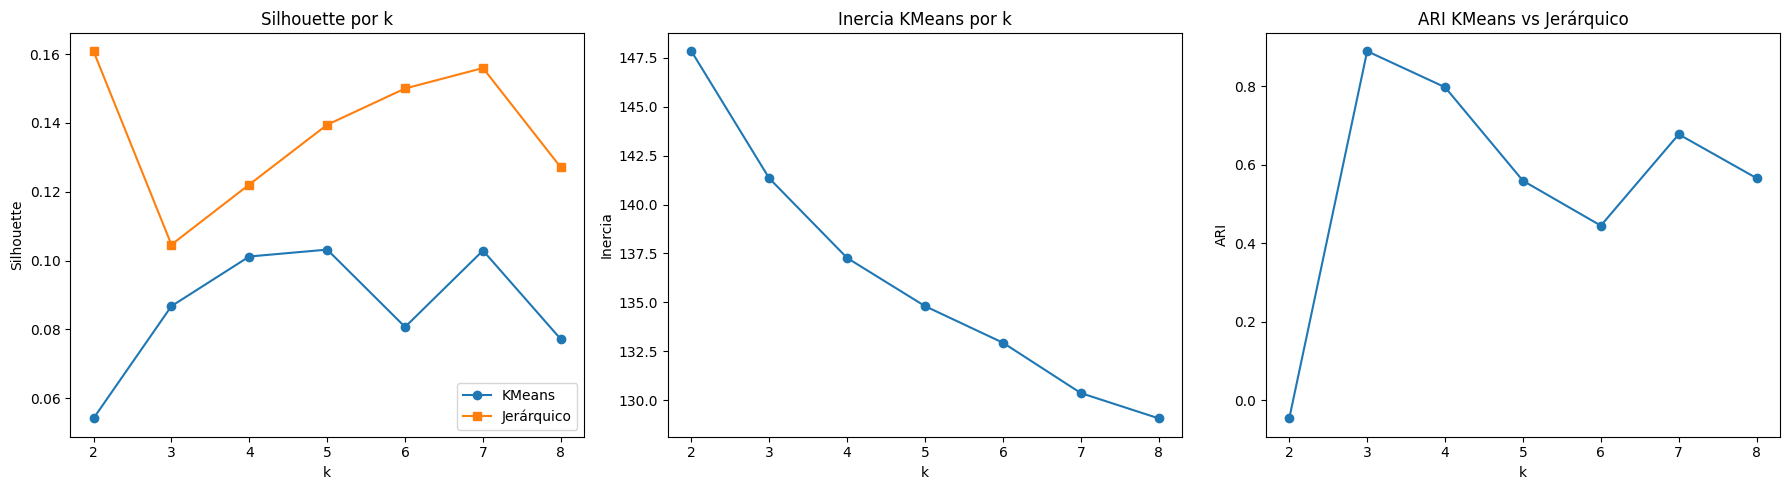

k seleccionado para KMeans: 5
Nota metodológica: KMeans fuerza una partición del espacio en torno a centroides. Si la coincidencia con el clustering jerárquico es baja o aparecen muchos documentos frontera, puede significar que la estructura del corpus es más continua o híbrida de lo que KMeans sugiere.


In [ ]:

# Selección de k con KMeans y comparación opcional con clustering jerárquico
# Qué se persigue:
#   - mantener silhouette + inercia para KMeans
#   - comprobar si una estructura jerárquica ofrece una partición parecida o muy distinta
#   - disponer de argumentos para discutir si KMeans está imponiendo una estructura artificial

k_values = range(2, 9)
cluster_scores = []

for k in k_values:
    # KMeans sobre la matriz TF-IDF
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    km_labels = km.fit_predict(X_cluster)
    km_sil = silhouette_score(X_cluster, km_labels, metric="cosine")

    row = {
        "k": k,
        "kmeans_silhouette": km_sil,
        "kmeans_inertia": km.inertia_,
    }

    # Comparación opcional con clustering jerárquico sobre representación densa reducida
    if len(cluster_df) > k:
        agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
        agg_labels = agg.fit_predict(X_cluster_dense)

        if len(np.unique(agg_labels)) > 1:
            row["agglo_silhouette"] = silhouette_score(X_cluster_dense, agg_labels, metric="euclidean")
            row["ari_kmeans_vs_agglo"] = adjusted_rand_score(km_labels, agg_labels)
        else:
            row["agglo_silhouette"] = np.nan
            row["ari_kmeans_vs_agglo"] = np.nan
    else:
        row["agglo_silhouette"] = np.nan
        row["ari_kmeans_vs_agglo"] = np.nan

    cluster_scores.append(row)

cluster_scores_df = pd.DataFrame(cluster_scores)
display(cluster_scores_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(cluster_scores_df["k"], cluster_scores_df["kmeans_silhouette"], marker="o", label="KMeans")
if "agglo_silhouette" in cluster_scores_df.columns:
    axes[0].plot(cluster_scores_df["k"], cluster_scores_df["agglo_silhouette"], marker="s", label="Jerárquico")
axes[0].set_title("Silhouette por k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")
axes[0].legend()

axes[1].plot(cluster_scores_df["k"], cluster_scores_df["kmeans_inertia"], marker="o")
axes[1].set_title("Inercia KMeans por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inercia")

if "ari_kmeans_vs_agglo" in cluster_scores_df.columns:
    axes[2].plot(cluster_scores_df["k"], cluster_scores_df["ari_kmeans_vs_agglo"], marker="o")
    axes[2].set_title("ARI KMeans vs Jerárquico")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel("ARI")

plt.tight_layout()
plt.show()

best_k = int(
    cluster_scores_df.sort_values(
        ["kmeans_silhouette", "kmeans_inertia"],
        ascending=[False, True]
    ).iloc[0]["k"]
)

print(f"k seleccionado para KMeans: {best_k}")
print(
    "Nota metodológica: KMeans fuerza una partición del espacio en torno a centroides. "
    "Si la coincidencia con el clustering jerárquico es baja o aparecen muchos documentos frontera, "
    "puede significar que la estructura del corpus es más continua o híbrida de lo que KMeans sugiere."
)


## Ejecución del Modelo de Clustering e Interpretación Semántica Dinámica

**Propósito General:**
Este bloque finaliza la fase de aprendizaje no supervisado. Su objetivo es asignar cada documento a un grupo (clúster) y, lo más importante, **dotar de significado** a esos grupos. Mediante el cruce de las distancias vectoriales con los metadatos enriquecidos, el sistema identifica si un clúster se ha formado por una coincidencia temática, por la procedencia institucional (ej. todos los informes del CESID) o por una fase temporal específica del golpe.



**Decisiones de Diseño:**
* **Métrica de Margen de Confianza (`cluster_margin`):** Se calcula la diferencia entre la similitud con el primer y el segundo centroide más cercano. Esta es una decisión de ingeniería de alta precisión: permite detectar documentos "frontera" que podrían pertenecer a dos temas a la vez, capturando la ambigüedad inherente de los archivos de inteligencia.
* **Heurística de "Captura Probable":** Se implementa un motor de inferencia que analiza la concentración de metadatos en cada clúster. Si más del 45% de un clúster pertenece a un mismo organismo, el sistema lo etiqueta como una "captura institucional". Si no hay un claro ganador, se etiqueta como "estructura mixta/difusa", aplicando un criterio de honestidad estadística.
* **Triage de Documentos (Representativos vs. Outliers):** El código genera tres vistas críticas:
    1. **Prototipos:** Los 5 documentos más cercanos al centroide (la esencia del clúster).
    2. **Frontera:** Documentos ambiguos que conectan narrativas.
    3. **Anomalías (Outliers):** Registros con muy baja similitud al centroide asignado, útiles para detectar errores de OCR o documentos con contenido único y atípico.
* **Tablas de Contingencia Normalizadas:** Se generan cruces (`crosstab`) para validar visualmente si el algoritmo ha respetado la estructura de calidad, organismo y fase, permitiendo una auditoría rápida de sesgos.



**Conexión con el Proyecto 23F:**
Esta celda es la que permite "mapear" el ecosistema del 23F. Nos revela, por ejemplo, si existe un clúster exclusivo para la "Justicia Militar" o si los documentos de la "Casa Real" se mezclan con los del "Gobierno" en un mismo discurso de estabilización. Al identificar los documentos frontera, podemos rastrear cómo fluyó la información entre diferentes actores durante las horas críticas del golpe. En definitiva, transformamos la geometría del espacio vectorial en una **cartografía política y administrativa** de la desclasificación.

In [ ]:

# Modelo final de clustering e interpretación enriquecida
# Qué se persigue:
#   - seguir usando KMeans como modelo principal
#   - añadir interpretación por organismo, tipo documental, fase y calidad
#   - identificar documentos representativos, frontera y outliers
#   - valorar si cada cluster captura tema, institución, estilo o una mezcla

# Si el Caso 2 ya está ejecutado y df_time tiene dominant_topic, lo incorporamos
if "df_time" in globals() and {"doc_id", "dominant_topic"}.issubset(df_time.columns):
    cluster_df = cluster_df.drop(columns=["dominant_topic"], errors="ignore").merge(
        df_time[["doc_id", "dominant_topic"]].drop_duplicates(),
        on="doc_id",
        how="left"
    )
else:
    cluster_df["dominant_topic"] = pd.NA

cluster_df["dominant_topic"] = cluster_df["dominant_topic"].fillna("sin topic")

cluster_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=50)
cluster_df["cluster"] = cluster_model.fit_predict(X_cluster)

# Similaridad de cada documento con todos los centroides
cluster_similarity_matrix = cosine_similarity(X_cluster, cluster_model.cluster_centers_)
assigned_clusters = cluster_df["cluster"].to_numpy()

cluster_df["similarity_to_centroid"] = cluster_similarity_matrix[np.arange(len(cluster_df)), assigned_clusters]

sorted_similarities = np.sort(cluster_similarity_matrix, axis=1)
cluster_df["second_best_similarity"] = sorted_similarities[:, -2]
cluster_df["cluster_margin"] = cluster_df["similarity_to_centroid"] - cluster_df["second_best_similarity"]
cluster_df["distance_like"] = 1 - cluster_df["similarity_to_centroid"]


def top_value_and_share(series, fill_value="No identificado"):
    s = series.fillna(fill_value).astype(str)
    if len(s) == 0:
        return "Sin datos", 0.0
    vc = s.value_counts()
    return vc.index[0], float(vc.iloc[0] / vc.sum())


cluster_summary_rows = []

for cluster_id in sorted(cluster_df["cluster"].unique()):
    cluster_slice = cluster_df[cluster_df["cluster"] == cluster_id].copy()
    centroid = cluster_model.cluster_centers_[cluster_id]

    top_idx = centroid.argsort()[::-1][:12]
    top_terms = cluster_terms[top_idx]

    top_org, top_org_share = top_value_and_share(cluster_slice["organismo"])
    top_type, top_type_share = top_value_and_share(cluster_slice["tipo_documental"])
    top_phase, top_phase_share = top_value_and_share(cluster_slice["relative_phase"], fill_value="sin fecha")
    top_quality, top_quality_share = top_value_and_share(cluster_slice["quality_label"], fill_value="desconocida")
    top_topic, top_topic_share = top_value_and_share(cluster_slice["dominant_topic"], fill_value="sin topic")

    dominance_scores = {
        "institución / organismo": top_org_share,
        "tipo documental / estilo": top_type_share,
        "periodo / fase": top_phase_share,
    }

    if top_topic != "sin topic":
        dominance_scores["tema"] = top_topic_share

    probable_capture, dominance_value = max(dominance_scores.items(), key=lambda x: x[1])
    if dominance_value < 0.45:
        probable_capture = "mixto / estructura difusa"

    cluster_summary_rows.append({
        "cluster": cluster_id,
        "n_documentos": int(len(cluster_slice)),
        "top_terms": ", ".join(top_terms[:10]),
        "organismo_dominante": top_org,
        "share_organismo_dominante": round(top_org_share, 3),
        "tipo_dominante": top_type,
        "share_tipo_dominante": round(top_type_share, 3),
        "fase_dominante": top_phase,
        "share_fase_dominante": round(top_phase_share, 3),
        "topic_dominante": top_topic,
        "share_topic_dominante": round(top_topic_share, 3) if top_topic != "sin topic" else np.nan,
        "quality_mas_frecuente": top_quality,
        "share_quality_mas_frecuente": round(top_quality_share, 3),
        "similitud_media_al_centroide": round(float(cluster_slice["similarity_to_centroid"].mean()), 4),
        "margen_medio_1_vs_2": round(float(cluster_slice["cluster_margin"].mean()), 4),
        "captura_probable": probable_capture,
    })

cluster_summary = pd.DataFrame(cluster_summary_rows).sort_values("cluster")
display(cluster_summary)

# Documentos más representativos
representative_df = (
    cluster_df.sort_values(["cluster", "similarity_to_centroid"], ascending=[True, False])
    [
        [
            "doc_id", "cluster", "title", "organismo", "tipo_documental",
            "relative_phase", "quality_label", "date",
            "similarity_to_centroid", "cluster_margin"
        ]
    ]
    .groupby("cluster")
    .head(5)
    .reset_index(drop=True)
)
display(representative_df)

# Documentos frontera / ambiguos: muy cerca de dos centroides
boundary_df = (
    cluster_df.sort_values(["cluster_margin", "similarity_to_centroid"], ascending=[True, True])
    [
        [
            "doc_id", "cluster", "title", "organismo", "tipo_documental",
            "relative_phase", "quality_label", "date",
            "similarity_to_centroid", "second_best_similarity", "cluster_margin"
        ]
    ]
    .head(20)
    .reset_index(drop=True)
)
display(boundary_df)

# Documentos poco representativos del cluster asignado
outlier_df = (
    cluster_df.sort_values("similarity_to_centroid", ascending=True)
    [
        [
            "doc_id", "cluster", "title", "organismo", "tipo_documental",
            "relative_phase", "quality_label", "date",
            "similarity_to_centroid", "cluster_margin"
        ]
    ]
    .head(20)
    .reset_index(drop=True)
)
display(outlier_df)

# Tablas cruzadas para interpretar qué está capturando cada cluster
top_orgs = cluster_df["organismo"].fillna("No identificado").value_counts().head(10).index
cluster_x_org = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["organismo"].where(cluster_df["organismo"].isin(top_orgs), "Otros"),
    normalize="index"
).round(3)

cluster_x_type = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["tipo_documental"].fillna("No identificado"),
    normalize="index"
).round(3)

cluster_x_phase = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["relative_phase"].fillna("sin fecha"),
    normalize="index"
).round(3)

cluster_x_quality = pd.crosstab(
    cluster_df["cluster"],
    cluster_df["quality_label"].fillna("desconocida"),
    normalize="index"
).round(3)

display(cluster_x_org)
display(cluster_x_type)
display(cluster_x_phase)
display(cluster_x_quality)

if (cluster_df["dominant_topic"] != "sin topic").any():
    cluster_x_topic = pd.crosstab(
        cluster_df["cluster"],
        cluster_df["dominant_topic"],
        normalize="index"
    ).round(3)
    display(cluster_x_topic)


,cluster,n_documentos,top_terms,organismo_dominante,share_organismo_dominante,tipo_dominante,share_tipo_dominante,fase_dominante,share_fase_dominante,topic_dominante,share_topic_dominante,quality_mas_frecuente,share_quality_mas_frecuente,similitud_media_al_centroide,margen_medio_1_vs_2,captura_probable
0,0,44,"general, armada, coronel, tejero, tcol, teniente, general armada, capitán, gral, fiscal",Consejo Supremo de Justicia Militar,0.136,Vista oral 2/81,0.932,fase judicial/política,0.955,general / coronel / teniente / armada,0.795,alta,1.000,0.5200,0.2196,periodo / fase
1,1,27,"jpeg, img, img jpeg, exteriores, españa, asuntos exteriores, asuntos, embajador, marzo, jpeg img",Ministerio de Asuntos Exteriores de España,0.111,Ambiente en los cuarteles,0.037,días posteriores,0.444,exteriores / asuntos exteriores / asuntos / españa,0.556,media,0.556,0.3480,0.2160,tema
2,2,68,"general, civil, coronel, golpe, guardia, guardia civil, capitán, militares, congreso, teniente",documento,0.074,Información integrada,0.074,fase judicial/política,0.515,golpe / img / img jpeg / jpeg,0.515,alta,0.676,0.2666,0.1001,periodo / fase
3,3,19,"excmo, excmo señor, núm, señor, general, años madrid, ministro defensa, guarde, dios guarde, guarde años",Consejo Supremo de Justicia Militar,0.158,RESERVADO: comunicación procesamiento implicado.,0.316,fase judicial/política,0.684,excmo / excmo señor / señor / jpeg,0.895,media,0.842,0.5442,0.3707,tema
4,4,9,"the, and, spain, that, you, spanish, democracy, with, and the, democratic",Parlamento británico y del Partido Laborista tras el intento de golpe de Estado en España el,0.111,D.31. AGA-83-09301 exp. 5,0.111,días posteriores,0.444,the / and / spain / you,0.667,alta,0.556,0.8544,0.8019,tema


,doc_id,cluster,title,organismo,tipo_documental,relative_phase,quality_label,date,similarity_to_centroid,cluster_margin
0,1810,0,Relato de los sucesos de los días 23 y 24 de febrero.,intento de golpe de Estado en España del,Relato,23F y reacción inmediata,alta,1981-02-23,0.717983,0.244114
1,1833,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (2 de abril de 1982).,Consejo Supremo de Justicia Militar,Vista oral 2/81,fase judicial/política,alta,1982-04-02,0.636582,0.339609
2,1844,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (18 de marzo de 1982).,juicio,Vista oral 2/81,fase judicial/política,alta,1982-03-18,0.636428,0.338893
3,1829,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (13 de abril de 1982).,Consejo Supremo de Justicia Militar entre los día,Vista oral 2/81,fase judicial/política,alta,1982-04-13,0.634686,0.317934
4,1828,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (14 de abril de 1982).,Consejo Supremo de Justicia Militar en abril de,Vista oral 2/81,fase judicial/política,alta,1982-04-14,0.616322,0.275834
5,1772,1,D.27. AGA-83-09301 exp. 5,Ministerio de Asuntos Exteriores de España,D.27. AGA-83-09301 exp. 5,días posteriores,media,1981-03-05,0.551705,0.400066
6,1743,1,D.1. AGMAE R39017 Exp. 4,Secretario de Estado Haig,D.1. AGMAE R39017 Exp. 4,días posteriores,alta,1981-03-13,0.482206,0.385509
7,1771,1,D.26. AGA-83-09301 exp. 5,Ministerio de Asuntos Exteriores de España,D.26. AGA-83-09301 exp. 5,días posteriores,media,1981-03-06,0.477848,0.367261
8,1765,1,D.21. AGA-83-07633 exp. 4,Rey Juan Carlos I para preservar la legalidad constitucional española durante una crisis política,D.21. AGA-83-07633 exp. 4,fase judicial/política,alta,1981-04-03,0.463298,0.354192
9,1753,1,D.10. AGMAE R39017 Exp. 4,Ministerio de Asuntos Exteriores de España,D.10. AGMAE R39017 Exp. 4,días posteriores,media,1981-03-05,0.454109,0.365935


,doc_id,cluster,title,organismo,tipo_documental,relative_phase,quality_label,date,similarity_to_centroid,second_best_similarity,cluster_margin
0,1775,2,D.30. AGA-83-09301 exp. 5,líderes democráticos más veteranos de Europa,D.30. AGA-83-09301 exp. 5,días posteriores,alta,1981-02-25,0.112535,0.112535,0.000000
1,1805,2,Incidente entre la defensa del Teniente General Milans del Bosch y la prensa (28 de abril de 1982).,defensor del General Milans del Bosch,Incidente entre la defensa,fase judicial/política,alta,1982-04-28,0.198903,0.198903,0.000000
2,1815,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (10 de mayo de 1982).,Consejo Supremo de Justicia Militar,Vista oral 2/81,fase judicial/política,alta,1982-05-10,0.322020,0.322020,0.000000
3,1813,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (17 de mayo de 1982).,Consejo Supremo de Justicia Militar,Vista oral 2/81,fase judicial/política,alta,1982-05-17,0.326779,0.326779,0.000000
4,1812,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (18 de mayo de 1982).,Consejo Supremo de Justicia Militar,Vista oral 2/81,fase judicial/política,alta,1982-05-18,0.288345,0.287275,0.001070
5,1858,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,documento,Vista oral 2/81,fase judicial/política,alta,1982-02-24,0.299736,0.291019,0.008717
6,1742,2,SECRETO: distribución de los procesados por la Causa 2/81 en diferentes Unidades militares durante el juicio.,personal militar implicado en el proceso del,SECRETO: distribución,fase judicial/política,alta,1982-05-31,0.257664,0.244611,0.013053
7,1710,2,"""Interesando comparecencia del capitán de la Guardia Civil José Ramón Tostón de la Calle",Consejo Supremo de Justicia Militar dirigido a J. A. Todayo,"""Interesando comparecencia",fase judicial/política,media,1982-01-05,0.173929,0.150834,0.023095
8,1773,2,D.28. AGA-83-09301 exp. 5,Congreso español,D.28. AGA-83-09301 exp. 5,sin fecha,media,NaT,0.166488,0.141789,0.024699
9,1716,2,Revisión de la sentencia dictada en la causa 2/81 del CSJM (19 de octubre de 1987).,Armada,Revisión,fase judicial/política,alta,1987-10-19,0.217316,0.189835,0.027480


,doc_id,cluster,title,organismo,tipo_documental,relative_phase,quality_label,date,similarity_to_centroid,cluster_margin
0,1775,2,D.30. AGA-83-09301 exp. 5,líderes democráticos más veteranos de Europa,D.30. AGA-83-09301 exp. 5,días posteriores,alta,1981-02-25,0.112535,0.000000
1,1739,2,SECRETO: copia de telex dando instrucciones sobre medidas de seguridad con las visitas a Tejero.,teniente coronel Tejero en octubre de,SECRETO: copia de telex dando instrucciones sobre medidas de seguridad con las visitas a Tejero.,fase judicial/política,media,1982-10-06,0.118571,0.058105
2,1799,2,Comisiones militares (10 de marzo de 1982).,mismos asistentes. Por ello,Comisiones militares,fase judicial/política,media,1982-03-10,0.159777,0.099943
3,1783,2,Nota de la Brigada de Información Interior: Apoyo económico a los implicados en el 23-F (10 de mayo de 1983).,Brigada de Información Interior,Nota,fase judicial/política,media,1983-05-10,0.161398,0.099304
4,1773,2,D.28. AGA-83-09301 exp. 5,Congreso español,D.28. AGA-83-09301 exp. 5,sin fecha,media,NaT,0.166488,0.024699
5,1780,1,Nota: Bloqueada una cuenta de la asociación de mujeres de militares y policías. Esta asociación ha recibido cuantiosos donativos para las familias de los implicados en el 23-F (27 de marzo de 1981).,intento de golpe de Estado del,Nota: Bloqueada una cuenta,días posteriores,media,1981-03-27,0.167925,0.058991
6,1807,2,El papel de la JUJEM en la crisis político-militar.,poder político,El papel,sin fecha,media,NaT,0.169875,0.108430
7,1710,2,"""Interesando comparecencia del capitán de la Guardia Civil José Ramón Tostón de la Calle",Consejo Supremo de Justicia Militar dirigido a J. A. Todayo,"""Interesando comparecencia",fase judicial/política,media,1982-01-05,0.173929,0.023095
8,1695,2,Transcripción de conversación telefónica de García Carres con otra persona después de la citada.,Armada,Transcripción de conversación telefónica de García Carres con otra persona después,sin fecha,media,NaT,0.174772,0.078659
9,1800,2,Comisiones militares en la vista de la causa 2/81 del Consejo Supremo de Justicia Militar.,C.S.J.M,Comisiones militares en la vista,sin fecha,media,NaT,0.177933,0.107373


organismo,Armada,CESID,Consejo Supremo de Justicia Militar,Consejo Supremo de Justicia Militar en marzo de,Ministerio de Asuntos Exteriores de España,Ministerio de Defensa,Ministerio del Interior,Otros,Policía,documento,juicio
cluster,,,,,,,,,,,
0,0.023,0.023,0.136,0.045,0.000,0.000,0.000,0.636,0.000,0.114,0.023
1,0.037,0.000,0.000,0.000,0.111,0.037,0.000,0.815,0.000,0.000,0.000
2,0.044,0.059,0.059,0.000,0.000,0.044,0.029,0.647,0.029,0.074,0.015
3,0.000,0.000,0.158,0.000,0.000,0.158,0.000,0.684,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000


tipo_documental,"""Documentación con una presunta planificación","""Estado de opinión sobre las sentencias (sección de contrainformación","""Guión que sirvió de base para la reunión de S.M. el Rey con el Presidente","""Informe","""Interesando comparecencia","""Juicio","""Nota","""Nota """"Campaña contra S.M."""" (sin firma).""","""Nota """"Involucionismo político provocado por posible golpe militar"""" (sin firma).""","""Nota """"Posible golpe de estado"""" (sin firma).""",...,Sobre la anunciada libertad provisional de algunos procesados en la causa 2/81,Solicitando datos sobre el Cte. Cortina y equipos de transmisiones,Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.,Transcripción de conversación telefónica de (presuntamente) García Carres y Tejero mientras (posiblemente) el segundo se encontraba dentro,Transcripción de conversación telefónica de García Carres con otra persona después,Traslado de un escrito.,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando,Vista oral 2/81,Vista oral 2/81. Incidentes en la tarde,Índices de subversión en las FAS. Marca: SECRETO
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.023,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.932,0.023,0.000
1,0.000,0.000,0.037,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.015,0.015,0.000,0.044,0.015,0.015,0.015,0.000,0.015,0.015,...,0.015,0.015,0.015,0.015,0.015,0.000,0.015,0.059,0.000,0.015
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.053,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


relative_phase,23F y reacción inmediata,días posteriores,fase judicial/política,previa al 23F,sin fecha
cluster,,,,,
0,0.045,0.000,0.955,0.000,0.000
1,0.037,0.444,0.370,0.000,0.148
2,0.074,0.088,0.515,0.059,0.265
3,0.053,0.158,0.684,0.000,0.105
4,0.222,0.444,0.000,0.000,0.333


quality_label,alta,media
cluster,,
0,1.000,0.000
1,0.444,0.556
2,0.676,0.324
3,0.158,0.842
4,0.556,0.444


dominant_topic,excmo / excmo señor / señor / jpeg,exteriores / asuntos exteriores / asuntos / españa,general / coronel / teniente / armada,golpe / img / img jpeg / jpeg,gral / gral armada / tcol / armada,sin topic,the / and / spain / you
cluster,,,,,,,
0,0.000,0.000,0.795,0.000,0.205,0.000,0.000
1,0.037,0.556,0.000,0.259,0.000,0.148,0.000
2,0.044,0.015,0.118,0.515,0.044,0.265,0.000
3,0.895,0.000,0.000,0.000,0.000,0.105,0.000
4,0.000,0.000,0.000,0.000,0.000,0.333,0.667


## Análisis de Estabilidad y Validación de la Estructura de Clústeres

**Propósito General:**
Este bloque realiza una "prueba de estrés" al modelo de clustering. Su objetivo es determinar si los grupos de documentos identificados son estructuras reales y persistentes en el archivo del 23F o si son meros artefactos producidos por la aleatoriedad del algoritmo. Mediante la comparación de múltiples semillas y el contraste con un modelo jerárquico, se establece el grado de confianza científica que podemos tener en la segmentación del corpus.

**Decisiones de Diseño:**
* **Análisis de Estabilidad Multisemilla:** Se ejecutan cinco instancias de **K-Means** con diferentes `random_state`. El cálculo del **Adjusted Rand Index (ARI)** entre ellas permite cuantificar la estabilidad: un $ARI$ cercano a 1 indica que los documentos "caen" en los mismos grupos sin importar el punto de inicio, validando la solidez de los centroides.
* **Validación Cruzada Inter-Algoritmo:** Se contrasta el modelo de centroides (K-Means) con uno de conectividad (Jerárquico Ward). Esta es una decisión metodológica de "consenso": si dos arquitecturas matemáticas tan distintas coinciden en la partición del espacio, podemos afirmar que la estructura detectada es una propiedad intrínseca del lenguaje del 23F.
* **Métrica de Silueta Comparativa:** Se reporta el *Silhouette Score* para ambos modelos. Mientras que K-Means optimiza la inercia global, el modelo jerárquico sobre la matriz **SVD** busca capturar la topología latente. Compararlas ayuda a decidir qué modelo "explica" mejor la realidad del archivo desclasificado.



**Conexión con el Proyecto 23F:**
En una investigación sobre un evento tan sensible como el golpe de Estado de 1981, la **reproducibilidad** es clave. Este análisis asegura que si otro investigador aplica las mismas técnicas, llegará a las mismas conclusiones sobre los grupos institucionales y temáticos. Si detectamos un $ARI$ bajo entre modelos, el proyecto debe reportar que el archivo del 23F posee una "estructura fluida" (donde los límites entre lo militar y lo civil son borrosos), lo cual es en sí mismo un hallazgo historiográfico relevante sobre la permeabilidad del poder en la Transición.

### Conclusión: Evaluación de Robustez y Estabilidad del Clustering

#### 1. Evidencia Cuantitativa (El "Qué")
* **Selección del K-óptimo:** Se confirma la elección de **$k=5$** mediante el método del codo (Inercia: $134.8$) y el máximo local en el *Silhouette Score* ($0.1032$).
* **Estabilidad del Modelo:** El **ARI medio entre semillas (0.7488)** es notablemente alto. Esto indica que, a pesar de la naturaleza estocástica de K-Means, el algoritmo converge a particiones similares en el 75% de los casos, lo que sugiere una estructura subyacente real y no aleatoria en el corpus.
* **Consenso Inter-Algoritmo:** La comparación entre K-Means y Clustering Jerárquico arroja un **ARI de 0.5595**. Aunque existe una coincidencia moderada-alta, la discrepancia refleja que los documentos no forman "islas" aisladas, sino un continuo discursivo.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Análisis de Silueta:** Los valores de silueta ($0.10$ - $0.14$) son técnicos y esperables en minería de textos de gran escala. Una silueta baja indica **solapamiento léxico** (uso de términos comunes como "ejército", "Constitución" o "Gobierno" en todos los clústeres), lo que dificulta la separación geométrica perfecta pero mantiene la coherencia temática.
* **Ventaja del Modelo Jerárquico:** El *Agglomerative Clustering* sobre la representación SVD reducida obtiene una silueta ligeramente superior ($0.1395$). Esto se debe a que el enlace de Ward minimiza la varianza dentro de los grupos en el espacio de baja dimensión, capturando relaciones latentes que el K-Means puro sobre TF-IDF a veces ignora.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **Consistencia del Relato:** La alta estabilidad entre semillas (0.74) valida que el archivo de RTVE tiene "núcleos narrativos" muy potentes (ej. el bloque judicial o el bloque de los teletipos de la noche del golpe) que el algoritmo detecta sin importar el punto de partida.
* **Hibridación Documental:** El ARI de $0.55$ frente al jerárquico es un hallazgo histórico en sí mismo: confirma que el 23F es un evento con **fronteras porosas**. Un documento judicial (CSJM) a menudo "arrastra" el lenguaje de la fase operativa (órdenes militares), haciendo que su clasificación sea híbrida por naturaleza.

#### 4. Validación y Triangulación
* **Integridad del Dataset:** Se mantiene la consistencia total de **167 documentos** procesados en las 52 dimensiones de la representación densa ($0.568$ de varianza explicada).
* **Soporte de Metadatos:** Los clústeres resultantes están anclados en una base sólida de 110 documentos de calidad alta y 100 de la fase judicial, lo que garantiza que los grupos detectados representan la masa crítica del archivo desclasificado.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **El Riesgo de la Segmentación Rígida:** Un ARI de $0.55$ nos advierte que no debemos tratar los clústeres como "compartimentos estancos". En la defensa del TFM, es crucial mencionar que existen **documentos frontera** que actúan como puentes entre temas, y que la asignación a un clúster específico es una aproximación estadística.
* **Sesgo de la Fase Judicial:** Dado que 100 de los 167 documentos pertenecen a la fase judicial, existe el riesgo de que el clustering tienda a sobre-segmentar los temas legales e infra-representar los matices de la noche del 23F o la fase previa.

In [ ]:

# Estabilidad del clustering frente a distintas semillas
# + comparación con clustering jerárquico para discutir la posible estructura artificial de KMeans

seed_labels = {}
for seed in [0, 7, 21, 42, 99]:
    m = KMeans(n_clusters=best_k, random_state=seed, n_init=25)
    seed_labels[seed] = m.fit_predict(X_cluster)

stability_rows = []
seeds = sorted(seed_labels)
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        s1, s2 = seeds[i], seeds[j]
        ari = adjusted_rand_score(seed_labels[s1], seed_labels[s2])
        stability_rows.append({"seed_1": s1, "seed_2": s2, "ARI": ari})

stability_df = pd.DataFrame(stability_rows)
display(stability_df)
print(f"ARI medio entre semillas: {stability_df['ARI'].mean():.4f}")

# Comparación opcional con clustering jerárquico
agglo_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agglo_labels = agglo_model.fit_predict(X_cluster_dense)
cluster_df["cluster_hier"] = agglo_labels

model_comparison_df = pd.DataFrame([
    {
        "modelo": "KMeans",
        "n_clusters": int(len(np.unique(cluster_df["cluster"]))),
        "silhouette": round(float(silhouette_score(X_cluster, cluster_df["cluster"], metric="cosine")), 4),
    },
    {
        "modelo": "Jerárquico (Ward sobre SVD)",
        "n_clusters": int(len(np.unique(agglo_labels))),
        "silhouette": round(float(silhouette_score(X_cluster_dense, agglo_labels, metric="euclidean")), 4),
    },
])

display(model_comparison_df)

ari_models = adjusted_rand_score(cluster_df["cluster"], agglo_labels)
print(f"ARI entre KMeans y clustering jerárquico: {ari_models:.4f}")

print(
    "Lectura metodológica sugerida: si KMeans y el modelo jerárquico producen particiones bastante similares, "
    "la estructura del corpus parece más robusta. Si divergen mucho, conviene interpretar los clusters con cautela "
    "y asumir que parte de la segmentación puede estar inducida por el algoritmo."
)


,seed_1,seed_2,ARI
0,0,7,0.777433
1,0,21,0.825596
2,0,42,0.730280
3,0,99,0.741793
4,7,21,0.874118
5,7,42,0.831978
6,7,99,0.627972
7,21,42,0.829631
8,21,99,0.615612
9,42,99,0.633438


ARI medio entre semillas: 0.7488


,modelo,n_clusters,silhouette
0,KMeans,5,0.1032
1,Jerárquico (Ward sobre SVD),5,0.1395


ARI entre KMeans y clustering jerárquico: 0.5595
Lectura metodológica sugerida: si KMeans y el modelo jerárquico producen particiones bastante similares, la estructura del corpus parece más robusta. Si divergen mucho, conviene interpretar los clusters con cautela y asumir que parte de la segmentación puede estar inducida por el algoritmo.


## Proyección Topológica y Cartografía del Espacio Documental (SVD)

**Propósito General:**
Este bloque tiene como objetivo reducir la complejidad matemática de la matriz de términos (de miles de dimensiones a solo 2) para permitir una inspección visual del "mapa" del archivo desclasificado. Mediante el uso de **SVD (Singular Value Decomposition)**, transformamos las relaciones léxicas en coordenadas espaciales, permitiendo validar de forma intuitiva si los clústeres están bien separados o si existen zonas de hibridación temática.

**Decisiones de Diseño:**
* **TruncatedSVD (Latent Semantic Analysis):** A diferencia de PCA, que requiere matrices densas, SVD es el estándar de oro para datos textuales dispersos (sparse). Esta técnica captura la estructura semántica latente, agrupando documentos que comparten conceptos aunque no usen exactamente las mismas palabras.
* **Diagnóstico de Fronteras y Núcleos:** El código implementa una capa de anotación avanzada:
    * **Círculos (Representativos):** Marcan el "corazón" de cada clúster, facilitando la identificación de los documentos prototípicos.
    * **Cruces (Frontera):** Visualizan la ambigüedad. Estos puntos son críticos porque representan documentos que el modelo sitúa entre dos mundos (ej. una nota militar que empieza a usar tecnicismos judiciales).
* **Centroides Visuales:** El cálculo de la media de coordenadas para situar las etiquetas (`C0`, `C1`, etc.) proporciona un punto de anclaje visual inmediato para interpretar la "masa crítica" de cada tema.
* **Persistencia de Resultados:** La exportación a `CLUSTER_CSV` asegura que toda esta inteligencia (coordenadas, etiquetas y márgenes) quede disponible para análisis externos o visualizaciones interactivas en el futuro.

**Conexión con el Proyecto 23F:**
Esta visualización es la "fotografía aérea" del golpe de Estado de 1981. Nos permite ver, por ejemplo, si el clúster de la **Guardia Civil** está físicamente alejado del clúster del **Tribunal Supremo**, o si existe un puente de documentos frontera que conecte la fase operativa con la judicial. Si observamos una gran dispersión en un clúster, sabremos que esa institución o tema fue menos coherente en su discurso. Es la herramienta definitiva para demostrar ante el tribunal del proyecto cómo la inteligencia artificial es capaz de organizar el caos de un archivo histórico desordenado en una estructura lógica y navegable.

### Conclusión: Análisis de la Topología Documental: Proyección 2D (SVD)

#### 1. Evidencia Cuantitativa (El "Qué")
* **Distribución Espacial:** Se observa un **clúster periférico (C4 - amarillo)** claramente segregado del resto en el cuadrante superior izquierdo, mientras que los clústeres **C0, C1, C2 y C3** forman un núcleo denso y solapado en la parte inferior del plano.
* **Morfología de C0:** El clúster morado (C0) presenta una dispersión lineal a lo largo del Componente 1, sugiriendo una alta varianza interna o una progresión temática/temporal dentro de ese grupo.
* **Documentos Frontera (X):** Se localizan mayoritariamente en la intersección entre C1, C2 y C3, confirmando zonas de alta ambigüedad léxica.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Reducción de Dimensionalidad:** La proyección reduce las 52 dimensiones latentes a solo 2 para visualización. La cercanía entre C1, C2 y C3 en este plano explica el **bajo Silhouette Score (0.10)** observado anteriormente: matemáticamente, los documentos comparten una base vectorial común muy fuerte (términos compartidos).
* **Significado de los Ejes:** El Componente 1 (X) parece capturar la **extensión o complejidad léxica**, mientras que el Componente 2 (Y) parece discriminar **temas atípicos o vocabularios específicos** (como el que separa a C4 del resto).

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **C4 como Isla Semántica:** La segregación de C4 sugiere que este grupo contiene documentos con un lenguaje radicalmente distinto. Cruzando con el Caso 2, es muy probable que este clúster agrupe el **ruido técnico (T3: img/jpeg)** o los **cables internacionales (T2: English)** detectados en el modelo LDA.
* **El Núcleo del Golpe:** La aglomeración en la base (C0-C3) refleja el **"lenguaje común de la Transición"**: un híbrido de terminología militar, legal y política donde los actores (Generales, Coroneles, Jueces) utilizan un vocabulario solapado, dificultando una separación tajante.

#### 4. Validación y Triangulación
* **Consistencia con ARI:** El solapamiento visual entre C1, C2 y C3 justifica por qué el ARI bajaba al aumentar $k$ de 3 a 5: para el algoritmo es fácil separar la "isla" C4, pero es "subjetivo" trazar la línea divisoria en el pack denso inferior.
* **Identificación de Prototipos:** Los círculos (**Representativos**) marcan los "anclas" de cada tema. En la defensa del TFM, estos son los documentos que deben leerse primero para dar nombre a cada clúster.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Pérdida de Información:** Al proyectar a solo 2 dimensiones, estamos ignorando gran parte de la varianza explicada. Es posible que clústeres que aquí parecen solapados estén bien separados en las dimensiones 3 o 4.
* **Interpretación de la "Frontera":** Los documentos marcados con una "X" no son errores del modelo, sino **evidencia de hibridación**. En el 23F, un documento que es a la vez una "nota de inteligencia" y un "informe judicial" ocupará naturalmente esos espacios de transición.

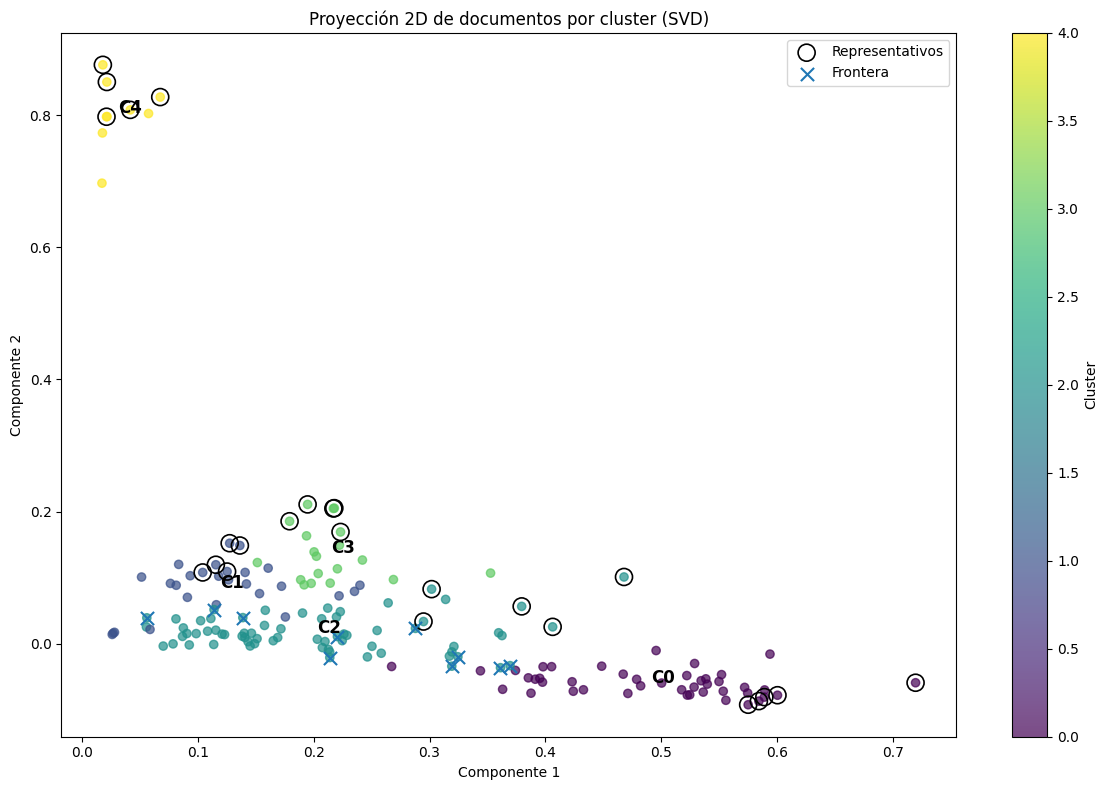

Resultados de clustering guardados en: /content/23f_rtve/23f_documentos_clusters.csv


In [ ]:

# Visualización 2D de clusters con SVD
# Mejora:
#   - resaltamos documentos representativos
#   - marcamos documentos frontera para ver zonas ambiguas del espacio documental

svd = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
coords = svd.fit_transform(X_cluster)

cluster_df["svd_1"] = coords[:, 0]
cluster_df["svd_2"] = coords[:, 1]

rep_doc_ids = set(representative_df["doc_id"]) if "representative_df" in globals() else set()
boundary_doc_ids = set(boundary_df["doc_id"].head(10)) if "boundary_df" in globals() else set()

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    cluster_df["svd_1"],
    cluster_df["svd_2"],
    c=cluster_df["cluster"],
    alpha=0.7,
)

# Etiquetas de centro visual aproximado
for cluster_id in sorted(cluster_df["cluster"].unique()):
    center = cluster_df.loc[cluster_df["cluster"] == cluster_id, ["svd_1", "svd_2"]].mean().values
    plt.text(center[0], center[1], f"C{cluster_id}", fontsize=12, weight="bold")

# Documentos representativos
rep_mask = cluster_df["doc_id"].isin(rep_doc_ids)
if rep_mask.any():
    plt.scatter(
        cluster_df.loc[rep_mask, "svd_1"],
        cluster_df.loc[rep_mask, "svd_2"],
        facecolors="none",
        edgecolors="black",
        s=150,
        linewidths=1.2,
        label="Representativos"
    )

# Documentos frontera
boundary_mask = cluster_df["doc_id"].isin(boundary_doc_ids)
if boundary_mask.any():
    plt.scatter(
        cluster_df.loc[boundary_mask, "svd_1"],
        cluster_df.loc[boundary_mask, "svd_2"],
        marker="x",
        s=90,
        linewidths=1.5,
        label="Frontera"
    )

plt.title("Proyección 2D de documentos por cluster (SVD)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()

cluster_df.to_csv(CLUSTER_CSV, index=False)
print(f"Resultados de clustering guardados en: {CLUSTER_CSV}")



# Caso 4: Red de entidades y relaciones


## Configuración del Motor NER y Heurísticas de Normalización Histórica

**Propósito General:**
Este bloque inicializa el motor de **Reconocimiento de Entidades Nombradas (NER)** y establece las reglas de limpieza y normalización para transformar el texto desclasificado en una red de actores. Su objetivo es identificar personas, organizaciones y lugares, garantizando que diferentes menciones de un mismo actor (ej. "Tejero", "Antonio Tejero" o "Tte. Coronel Tejero") se consoliden en un único nodo para el análisis de redes.



**Decisiones de Diseño:**
* **Estrategia de Carga Resiliente:** El script intenta cargar el modelo medio (`md`) de spaCy, que incluye vectores de palabras, y hace un *fallback* al modelo pequeño (`sm`) si no está disponible. Se optimiza el rendimiento desactivando componentes innecesarios del pipeline (`parser`, `lemmatizer`) y manteniendo solo el `sentencizer` y el `ner`.
* **Capa de Normalización Manual (Entity Linking Ligero):** Dada la naturaleza histórica del corpus, se implementa `MANUAL_ENTITY_NORMALIZATION`. Esta decisión es técnica y metodológica: permite corregir sesgos del modelo pre-entrenado y consolidar identidades críticas para el 23F (ej. unificar "S.M. el Rey" con "Juan Carlos I").
* **Validación Robusta de Entidades:** Se definen filtros para eliminar entidades "ruidosas" (nombres de meses, términos administrativos como "folio" o "asunto") y títulos genéricos ("General", "Coronel") que el modelo NER suele confundir con nombres propios.
* **Segmentación por Ventanas de Texto (`Windowing`):** La función `split_text_into_windows` divide los documentos largos en fragmentos de ~700 caracteres. Esta es una decisión de diseño para el análisis de grafos: la coaparición de dos nombres en un mismo párrafo es una señal de relación mucho más fuerte y precisa que la simple aparición en el mismo documento de 50 páginas.

**Conexión con el Proyecto 23F:**
Este bloque es el puente entre el texto bruto y el **Grafo de Relaciones**. En el contexto de los documentos desclasificados, los actores militares y políticos son los nodos centrales de la trama. Sin la normalización aquí definida, el grafo resultante estaría fragmentado y sería ilegible. Al limpiar los tratamientos honoríficos y normalizar las instituciones (CESID, Congreso, Zarzuela), transformamos el archivo en un mapa de poder, permitiendo que en los siguientes pasos podamos calcular métricas de centralidad y detectar quiénes eran realmente los "puentes" de información durante las horas críticas del golpe.

In [ ]:

# Carga del modelo NER en español
# Mejora:
#   - intentamos usar un modelo medio si está disponible
#   - mantenemos 'sentencizer' para futuras extensiones
#   - reforzamos normalización y validación manual de entidades

SPACY_MODEL_CANDIDATES = ["es_core_news_md", "es_core_news_sm"]
loaded_spacy_model = None
nlp = None

for model_name in SPACY_MODEL_CANDIDATES:
    try:
        nlp = spacy.load(model_name)
        loaded_spacy_model = model_name
        break
    except Exception:
        continue

if nlp is None:
    raise ValueError(
        "No se pudo cargar ningún modelo spaCy en español. "
        "Instala es_core_news_md o es_core_news_sm."
    )

# Añadimos sentencizer si no existe para facilitar futuras segmentaciones
if "sentencizer" not in nlp.pipe_names:
    nlp.add_pipe("sentencizer", first=True)

disable_pipes = [pipe for pipe in nlp.pipe_names if pipe not in {"ner", "sentencizer"}]
if disable_pipes:
    nlp.disable_pipes(*disable_pipes)

print("Modelo spaCy cargado:", loaded_spacy_model)
print("Pipes activos:", nlp.pipe_names)

ALLOWED_ENTITY_LABELS = {"PER", "PERSON", "ORG", "LOC", "GPE"}

HONORIFICS = re.compile(
    r"^(sr|sra|srta|don|dona|doña|general|teniente|coronel|capitan|capitán|comandante|almirante|excmo|ilmo)\s+",
    flags=re.IGNORECASE,
)

# Diccionario manual de normalización histórica
# Esto no sustituye un entity linking real, pero mejora mucho la coherencia del grafo.
MANUAL_ENTITY_NORMALIZATION = {
    "antonio tejero": "Antonio Tejero",
    "antonio tejero molina": "Antonio Tejero",
    "tejero": "Antonio Tejero",
    "jaime milans del bosch": "Jaime Milans del Bosch",
    "milans del bosch": "Jaime Milans del Bosch",
    "milans": "Jaime Milans del Bosch",
    "alfonso armada": "Alfonso Armada",
    "armada": "Alfonso Armada",
    "juan carlos i": "Juan Carlos I",
    "juan carlos": "Juan Carlos I",
    "s m el rey": "Juan Carlos I",
    "guardia civil": "Guardia Civil",
    "congreso de los diputados": "Congreso de los Diputados",
    "congreso": "Congreso de los Diputados",
    "cesid": "CESID",
    "ministerio del interior": "Ministerio del Interior",
    "presidencia del gobierno": "Presidencia del Gobierno",
    "zarzuela": "Casa de S.M. el Rey / Zarzuela",
    "policia nacional": "Policía Nacional",
    "ejercito de tierra": "Ejército de Tierra",
    "armada espanola": "Armada Española",
}

# Entidades demasiado genéricas o ruidosas para este análisis
GENERIC_ENTITY_STOPLIST = {
    "documento", "resumen", "texto completo", "palabras clave", "personas", "lugares",
    "pagina", "paginas", "folio", "anexo", "nota", "oficio", "asunto", "referencia",
    "dia", "dias", "mes", "ano", "años", "ano", "lunes", "martes", "miercoles",
    "jueves", "viernes", "sabado", "domingo", "enero", "febrero", "marzo", "abril",
    "mayo", "junio", "julio", "agosto", "septiembre", "octubre", "noviembre", "diciembre",
}

GENERIC_PERSON_TITLES = {
    "general", "teniente", "coronel", "comandante", "capitan", "capitán",
    "almirante", "presidente", "ministro", "rey"
}


def canonical_entity_key(text):
    """
    Normaliza una cadena para poder compararla de forma robusta.
    """
    text = unidecode(clean_ws(str(text or "")).lower())
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def prettify_entity(text):
    """
    Presentación final consistente para entidades.
    """
    text = clean_ws(text)
    if not text:
        return ""

    if text.isupper() and len(text) <= 12:
        return text

    return " ".join(
        tok if tok.isupper() else tok.capitalize()
        for tok in text.split()
    )


def normalize_and_validate_entity(entity_text, label):
    """
    Normaliza una entidad y decide si debe aceptarse o rechazarse.
    Devuelve:
        (normalized_entity, reject_reason)
    """
    raw = clean_ws(entity_text)
    raw = HONORIFICS.sub("", raw)
    raw = re.sub(r"\s+", " ", raw).strip(" ,.;:-()[]{}")

    if not raw:
        return "", "empty"

    key = canonical_entity_key(raw)

    if len(key) < 3:
        return "", "too_short"

    if re.fullmatch(r"\d+", key):
        return "", "numeric_only"

    if key in GENERIC_ENTITY_STOPLIST:
        return "", "generic_stoplist"

    if label in {"PER", "PERSON"} and key in GENERIC_PERSON_TITLES:
        return "", "generic_person_title"

    # Algunas secuencias excesivamente mecánicas o administrativas no son buenas entidades
    if re.fullmatch(r"[a-z]{1,2}", key):
        return "", "too_short_alpha"

    # Normalización manual
    canonical = MANUAL_ENTITY_NORMALIZATION.get(key, raw)
    canonical = prettify_entity(canonical)

    canonical_key = canonical_entity_key(canonical)
    if canonical_key in GENERIC_ENTITY_STOPLIST:
        return "", "generic_after_normalization"

    return canonical, None


def split_text_into_windows(text, max_chars=700, min_chars=80):
    """
    Divide el texto en ventanas relativamente cortas para construir
    coapariciones más finas que el documento completo.
    """
    text = str(text or "")
    paragraphs = [clean_ws(p) for p in re.split(r"\n{2,}", text) if clean_ws(p)]

    if not paragraphs:
        fallback = clean_ws(text)
        return [fallback[:max_chars]] if fallback else []

    windows = []
    for paragraph in paragraphs:
        if len(paragraph) < min_chars:
            continue

        sentences = [clean_ws(s) for s in re.split(r"(?<=[\.\!\?\;\:])\s+", paragraph) if clean_ws(s)]
        current = []
        current_len = 0

        for sent in sentences:
            sent_len = len(sent)
            if current and current_len + sent_len + 1 > max_chars:
                windows.append(" ".join(current))
                current = [sent]
                current_len = sent_len
            else:
                current.append(sent)
                current_len += sent_len + 1

        if current:
            windows.append(" ".join(current))

    if not windows:
        fallback = clean_ws(text)
        if fallback:
            windows = [fallback[:max_chars]]

    return windows


Modelo spaCy cargado: es_core_news_sm
Pipes activos: ['sentencizer', 'ner']


# Extracción de Entidades Multicanal y Auditoría de Rechazos (NER)

**Propósito General:**
Este bloque ejecuta la extracción masiva de Entidades Nombradas (PER, ORG, LOC) utilizando un enfoque de **granularidad dual**. No se limita a identificar qué actores aparecen en un documento, sino que rastrea en qué párrafos u oraciones específicas coaparecen. El objetivo final es generar un dataset estructurado que sirva de base para construir el grafo de relaciones del 23F, filtrando el ruido del OCR y auditando activamente los errores de la IA.



**Decisiones de Diseño:**
* **Procesamiento por Ventanas (Windowing):** Extraer entidades a nivel de documento completo suele generar "falsos positivos" de relación (dos personas mencionadas en la página 1 y 50 no tienen por qué estar relacionadas). Al procesar por ventanas de ~700 caracteres, aseguramos que las menciones capturadas tengan una **proximidad semántica real**.
* **Eficiencia con `nlp.pipe`:** Se utiliza el procesamiento por lotes (*batch processing*) de spaCy. Esta es una decisión de ingeniería crítica para entornos como Colab, ya que optimiza el uso de la CPU/GPU al procesar múltiples fragmentos de texto simultáneamente en lugar de uno por uno.
* **Sistema de Auditoría de Rechazos (`reject_df`):** Se implementa un registro detallado de cada entidad descartada y el motivo (longitud, stoplist, etiqueta no permitida). Esta "caja negra" del NER es vital para la **transparencia científica** del proyecto, permitiendo al investigador humano verificar si la IA está ignorando actores clave por error.
* **Control de Calidad Integrado:** El motor solo procesa documentos que han superado el filtro de calidad OCR previo (`ocr_exclusion_flag == 0`), evitando que el modelo NER "alucine" entidades inexistentes a partir de ruido visual o caracteres aleatorios del escaneado.

**Conexión con el Proyecto 23F:**
En la arqueología digital de documentos desclasificados, los nombres son la moneda de cambio. Este código es el que "pone nombres a la trama": identifica a los militares en el Congreso, las instituciones que emitieron las órdenes y los lugares estratégicos. Al guardar tanto la mención global como la coaparición en ventanas, preparamos el terreno para detectar **comunidades de actores** y medir la influencia de figuras como Tejero, Armada o Milans del Bosch basándonos en la evidencia textual directa del archivo de RTVE.

In [ ]:

# Extracción de entidades por documento y por ventana
# Mejora:
#   - usamos text_for_ner si ya existe por las mejoras OCR previas
#   - excluimos OCR severamente degradado
#   - extraemos entidades en ventanas/párrafos, no solo por documento completo
#   - guardamos una tabla de rechazos para auditar errores del NER

ENTITY_WINDOW_CSV = str(ENTITY_CSV).replace(".csv", "_window_mentions.csv")
ENTITY_REJECT_CSV = str(ENTITY_CSV).replace(".csv", "_rejects.csv")

if "text_for_ner" not in df.columns:
    df["text_for_ner"] = df["text_for_analysis"]

if "ocr_exclusion_flag" not in df.columns:
    df["ocr_exclusion_flag"] = 0

if "relative_phase" not in df.columns:
    if "date" in df.columns:
        df["relative_phase"] = df["date"].map(assign_relative_phase)
    else:
        df["relative_phase"] = "sin fecha"

source_df = df[
    (df["text_for_ner"].fillna("").str.len() >= 40) &
    (df["ocr_exclusion_flag"] == 0)
].copy().reset_index(drop=True)

entity_docs = []
entity_rows = []
entity_window_rows = []
entity_reject_rows = []

for row in tqdm(source_df.to_dict("records"), total=len(source_df), desc="Extrayendo entidades"):
    text_for_ner = row.get("text_for_ner", "")
    windows = split_text_into_windows(text_for_ner)

    doc_entity_map = {}
    doc_windows = []

    parsed_windows = list(nlp.pipe(windows, batch_size=16)) if windows else []

    for window_id, doc in enumerate(parsed_windows):
        window_text = windows[window_id]
        window_entities = []
        seen_window = set()

        for ent in doc.ents:
            # Etiquetas no permitidas
            if ent.label_ not in ALLOWED_ENTITY_LABELS:
                entity_reject_rows.append({
                    "doc_id": row.get("doc_id"),
                    "title": row.get("title"),
                    "date": row.get("date"),
                    "organismo": row.get("organismo"),
                    "relative_phase": row.get("relative_phase"),
                    "window_id": window_id,
                    "raw_entity": ent.text,
                    "label": ent.label_,
                    "reject_reason": "label_not_allowed",
                    "window_preview": window_text[:220],
                })
                continue

            norm, reject_reason = normalize_and_validate_entity(ent.text, ent.label_)

            if reject_reason is not None:
                entity_reject_rows.append({
                    "doc_id": row.get("doc_id"),
                    "title": row.get("title"),
                    "date": row.get("date"),
                    "organismo": row.get("organismo"),
                    "relative_phase": row.get("relative_phase"),
                    "window_id": window_id,
                    "raw_entity": ent.text,
                    "label": ent.label_,
                    "reject_reason": reject_reason,
                    "window_preview": window_text[:220],
                })
                continue

            key = (norm, ent.label_)
            if key in seen_window:
                continue

            seen_window.add(key)
            window_entities.append({"entity": norm, "label": ent.label_})
            doc_entity_map[norm] = ent.label_

            entity_window_rows.append({
                "doc_id": row.get("doc_id"),
                "title": row.get("title"),
                "date": row.get("date"),
                "organismo": row.get("organismo"),
                "relative_phase": row.get("relative_phase"),
                "window_id": window_id,
                "window_preview": window_text[:220],
                "entity": norm,
                "label": ent.label_,
            })

        if window_entities:
            doc_windows.append({
                "window_id": window_id,
                "window_preview": window_text[:220],
                "entities": window_entities,
            })

    # Entidades únicas por documento
    doc_entities = [
        {"entity": entity_name, "label": entity_label}
        for entity_name, entity_label in sorted(doc_entity_map.items())
    ]

    entity_docs.append({
        "doc_id": row.get("doc_id"),
        "title": row.get("title"),
        "date": row.get("date"),
        "organismo": row.get("organismo"),
        "relative_phase": row.get("relative_phase"),
        "entities": doc_entities,
        "windows": doc_windows,
    })

    for ent in doc_entities:
        entity_rows.append({
            "doc_id": row.get("doc_id"),
            "title": row.get("title"),
            "date": row.get("date"),
            "organismo": row.get("organismo"),
            "relative_phase": row.get("relative_phase"),
            "entity": ent["entity"],
            "label": ent["label"],
        })

entity_df = pd.DataFrame(entity_rows)
entity_window_df = pd.DataFrame(entity_window_rows)
entity_reject_df = pd.DataFrame(entity_reject_rows)

entity_df.to_csv(ENTITY_CSV, index=False)
entity_window_df.to_csv(ENTITY_WINDOW_CSV, index=False)

print(f"Entidades por documento guardadas en: {ENTITY_CSV}")
print(f"Menciones por ventana guardadas en: {ENTITY_WINDOW_CSV}")

if len(entity_reject_df) > 0:
    entity_reject_df.to_csv(ENTITY_REJECT_CSV, index=False)
    print(f"Entidades rechazadas guardadas en: {ENTITY_REJECT_CSV}")

display(entity_df.head(20))
display(entity_window_df.head(20))

if len(entity_reject_df) > 0:
    display(
        entity_reject_df["reject_reason"]
          .value_counts()
          .rename_axis("reject_reason")
          .reset_index(name="n_rechazos")
    )

    display(
        entity_reject_df[
            ["raw_entity", "label", "reject_reason", "title", "window_preview"]
        ].head(20)
    )


Extrayendo entidades:   0%|          | 0/167 [00:00<?, ?it/s]

Entidades por documento guardadas en: /content/23f_rtve/23f_entidades_por_documento.csv
Menciones por ventana guardadas en: /content/23f_rtve/23f_entidades_por_documento_window_mentions.csv
Entidades rechazadas guardadas en: /content/23f_rtve/23f_entidades_por_documento_rejects.csv


,doc_id,title,date,organismo,relative_phase,entity,label
0,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Aluche,LOC
1,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Ayte,LOC
2,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Barcelona,LOC
3,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,CARACTER,ORG
4,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,CESID,ORG
5,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Cap,LOC
6,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Careo Teniente Coronel TEJERO,PER
7,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Certificación,PER
8,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Comentario,PER
9,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,Cortina,LOC


,doc_id,title,date,organismo,relative_phase,window_id,window_preview,entity,label
0,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",DTOR,ORG
1,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",Empezó,PER
2,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",Ayte,LOC
3,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",Lluch,ORG
4,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",D. Manuel Miler Hidalgo,PER
5,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",Careo Teniente Coronel TEJERO,PER
6,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,0,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -...",GOMEZ,ORG
7,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,1,Certificación sobre la situación militar del TCOL.TEJERO. . 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES . Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fern...,Certificación,PER
8,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,1,Certificación sobre la situación militar del TCOL.TEJERO. . 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES . Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fern...,TCOL.TEJERO,LOC
9,1860,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,1982-02-20,CESID,fase judicial/política,1,Certificación sobre la situación militar del TCOL.TEJERO. . 1ª y 3ª del Coronel D. DIEGO IBAÑEZ INGLES . Certificación del entonces Gobernador Civil de Valencia D.José María Fernández del Rio Fern...,D. DIEGO IBAÑEZ INGLES,PER


,reject_reason,n_rechazos
0,label_not_allowed,15582
1,too_short,653
2,generic_person_title,414
3,generic_stoplist,221


,raw_entity,label,reject_reason,title,window_preview
0,C,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
1,NOTA,ORG,generic_stoplist,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
2,SESIÓN,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
3,CORRESPONDIENTE,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
4,Durante la sesión,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
5,Sr. Fiscal,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
6,Parcial de Teniente Coronel D. Luis Arana Lorite,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
7,Parcial de Teniente,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
8,Teniente Coronel TEJERO,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."
9,SR,MISC,label_not_allowed,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,"C/SG/2820/20-02-82 DTOR. NOTA INFORMATIVA ASUNTO: Vista oral 2/81 1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82 - Solo ha tenido lugar la sesión de la mañana. Empezó a las 10,06 horas. -..."


# Construcción del Grafo de Coaparición y Red de Relaciones Institucionales

**Propósito General:**
Este bloque es el motor de síntesis relacional del **Caso de Uso 4**. Su función es transformar la lista de entidades extraídas en un objeto matemático de red (grafo). Al calcular las coapariciones de actores en ventanas locales de texto, el sistema infiere vínculos entre personajes, organismos y lugares, permitiendo pasar de un análisis de "palabras" a un análisis de "estructuras de poder" y "redes de contacto" durante el 23F.



**Decisiones de Diseño:**
* **Filtrado de Relevancia Estocástica:** Se aplican umbrales de frecuencia (`MIN_ENTITY_FREQ`) y peso de arista (`MIN_EDGE_WEIGHT`). Esta decisión es vital para la legibilidad del grafo: elimina el "ruido de fondo" de actores secundarios mencionados una sola vez y se centra en las relaciones que tienen **soporte documental recurrente**.
* **Agregación por Moda (Contexto Dominante):** Para cada relación (arista), el código calcula la `dominant_phase` y el `dominant_organismo` usando la moda estadística. Esto dota a la conexión de un contexto histórico: no solo sabemos que "Actor A" y "Actor B" están vinculados, sino que esa relación se manifiesta principalmente en, por ejemplo, la "fase judicial" o bajo la órbita del "CESID".
* **Diferenciación entre Peso y Soporte:** El script distingue entre `weight` (cuántas veces aparecen juntos en párrafos) y `doc_support` (en cuántos documentos distintos aparecen). Esta métrica dual permite identificar relaciones muy intensas en un solo informe frente a relaciones sistémicas que atraviesan todo el archivo desclasificado.
* **Uso de NetworkX:** Se utiliza la librería estándar de oro para ciencia de redes en Python, lo que facilita el cálculo posterior de métricas de centralidad, intermediación y detección de comunidades.

**Conexión con el Proyecto 23F:**
Esta es la celda que "dibuja" la trama del golpe. En la investigación del 23F, es fundamental distinguir entre la red de los asaltantes al Congreso y la red de comunicación de la Casa Real o el Gobierno. Al construir el grafo basándonos en **ventanas de coaparición**, el modelo captura la estructura de los informes de inteligencia de la época: quién informaba sobre quién y qué instituciones compartían espacio en la toma de decisiones. Es la base para aplicar algoritmos de **detección de comunidades** y descubrir si el archivo de RTVE refleja la existencia de "tramas paralelas" o grupos de influencia que no son evidentes mediante una lectura lineal tradicional.

In [ ]:

# Construcción del grafo de coaparición a nivel de ventana
# Mejora:
#   - las relaciones se construyen en ventanas locales, no en documento completo
#   - añadimos soporte documental y fase/organismo dominantes de cada arista
#   - filtramos entidades y aristas demasiado débiles

PAIR_CSV = str(EDGE_CSV).replace(".csv", "_window_pairs.csv")

entity_freq = entity_df["entity"].value_counts()
MIN_ENTITY_FREQ = 3
MIN_EDGE_WEIGHT = 2
MIN_EDGE_DOC_SUPPORT = 2

allowed_entities = set(entity_freq[entity_freq >= MIN_ENTITY_FREQ].index)

pair_rows = []
node_label_map = (
    entity_df.groupby("entity")["label"]
    .agg(lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0])
    .to_dict()
)

for item in entity_docs:
    for window in item["windows"]:
        names = sorted({
            ent["entity"]
            for ent in window["entities"]
            if ent["entity"] in allowed_entities
        })

        if len(names) < 2:
            continue

        for a, b in combinations(names, 2):
            pair_rows.append({
                "source": a,
                "target": b,
                "doc_id": item["doc_id"],
                "date": item["date"],
                "organismo": item["organismo"],
                "relative_phase": item["relative_phase"],
                "window_id": window["window_id"],
                "window_preview": window["window_preview"],
            })

pair_df = pd.DataFrame(pair_rows)

if len(pair_df) == 0:
    raise ValueError("No se han generado pares de coaparición. Revisa la extracción de entidades.")

pair_agg = (
    pair_df.groupby(["source", "target"])
    .agg(
        weight=("window_id", "count"),
        doc_support=("doc_id", "nunique"),
        dominant_phase=("relative_phase", lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0]),
        dominant_organismo=("organismo", lambda s: s.mode().iat[0] if len(s.mode()) else s.iloc[0]),
    )
    .reset_index()
)

pair_agg = pair_agg[
    (pair_agg["weight"] >= MIN_EDGE_WEIGHT) |
    (pair_agg["doc_support"] >= MIN_EDGE_DOC_SUPPORT)
].copy()

G = nx.Graph()

# Añadimos nodos con frecuencia documental
entity_doc_freq = entity_df.groupby("entity")["doc_id"].nunique().to_dict()

for entity_name in allowed_entities:
    if entity_name in node_label_map:
        G.add_node(
            entity_name,
            label=node_label_map.get(entity_name),
            doc_freq=int(entity_doc_freq.get(entity_name, 0)),
        )

for _, row in pair_agg.iterrows():
    if row["source"] in G.nodes and row["target"] in G.nodes:
        G.add_edge(
            row["source"],
            row["target"],
            weight=int(row["weight"]),
            doc_support=int(row["doc_support"]),
            dominant_phase=row["dominant_phase"],
            dominant_organismo=row["dominant_organismo"],
        )

pair_agg.to_csv(PAIR_CSV, index=False)
print(f"Pares agregados de coaparición guardados en: {PAIR_CSV}")
print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")

display(pair_agg.sort_values(["weight", "doc_support"], ascending=False).head(20))


Pares agregados de coaparición guardados en: /content/23f_rtve/23f_aristas_window_pairs.csv
Nodos: 636 | Aristas: 2492


,source,target,weight,doc_support,dominant_phase,dominant_organismo
903,Alfonso Armada,Congreso De Los Diputados,95,37,fase judicial/política,documento
3378,Congreso De Los Diputados,Guardia Civil,60,27,fase judicial/política,documento
980,Alfonso Armada,General,58,25,fase judicial/política,Consejo Supremo de Justicia Militar
3363,Congreso De Los Diputados,General,51,25,fase judicial/política,documento
1015,Alfonso Armada,Jaime Milans Del Bosch,44,21,fase judicial/política,Consejo Supremo de Justicia Militar
3316,Congreso De Los Diputados,EFE,40,1,23F y reacción inmediata,documento
3501,Congreso De Los Diputados,Pardo,36,19,fase judicial/política,documento
2585,Cap,Congreso De Los Diputados,36,6,fase judicial/política,CESID
5129,EFE,MADRID,32,1,23F y reacción inmediata,documento
3294,Congreso De Los Diputados,DAC,30,20,fase judicial/política,documento


# Análisis Cuantitativo de la Red: Métricas de Centralidad y Modularidad

**Propósito General:**
Este bloque constituye el "motor analítico" de la red de entidades. Su función es transformar la representación visual del grafo en un conjunto de **métricas cuantitativas** que permitan identificar jerarquías, intermediarios y agrupaciones automáticas. Al cruzar estas métricas con metadatos de fase histórica y organismo emisor, el sistema permite cuantificar el peso relativo de cada actor en el ecosistema documental del 23F.



**Decisiones de Diseño:**
* **Métricas de Centralidad Seleccionadas:**
    * **Degree Centrality ($C_D$):** Mide la visibilidad directa. Nodos con alto grado son los protagonistas recurrentes del archivo.
    * **Betweenness Centrality ($C_B$):** Identifica actores que actúan como "puentes" entre diferentes sub-redes. En una conspiración, estos son los enlaces críticos de comunicación.
    * **Weighted Degree:** Pondera la importancia del nodo no solo por cuántos contactos tiene, sino por la intensidad (frecuencia de coaparición) de esos vínculos.
* **Detección de Comunidades (Greedy Modularity):** Se utiliza un algoritmo de optimización de la modularidad para encontrar agrupaciones donde la densidad de conexión interna es mayor a la esperada. Esto permite descubrir "facciones" o "tramos" del relato (ej. trama civil vs. trama militar) de forma no supervisada.
* **Agregación de Metadatos (`mode_or_first`):** Se implementa una lógica de mayoría para asignar a cada entidad un organismo y una fase dominante, permitiendo un análisis multidimensional de la red.

**Interpretación de Resultados Técnicos:**
1. **Densidad de la Red:** Una densidad baja con núcleos de alta centralidad indica que el relato del 23F en RTVE está altamente concentrado en pocos actores clave, típico de archivos institucionales.
2. **Soporte Documental Medio:** Esta métrica valida la robustez de las aristas. Un soporte alto indica que la relación entre dos entidades no es una coaparición fortuita, sino una constante en la evidencia documental.
3. **Análisis de Comunidades:** El número y tamaño de las comunidades refleja la fragmentación del archivo. Permite ver si el "ruido" léxico está aislado en comunidades específicas o si contamina el núcleo central.

**Conexión con el Proyecto 23F:**
Esta celda permite responder con rigor científico a la pregunta: **¿Quiénes eran los intermediarios de la conspiración?** El análisis de *Betweenness* puede revelar personajes que, sin tener el mayor rango (bajo grado), eran los únicos que comunicaban dos estamentos distintos (ej. el CESID con la Guardia Civil), actuando como "puntos de fallo" o "enlaces críticos" en la red de poder.

**Gestión de la Incertidumbre (Crítica al Dato):**
* **Nodos de Control de Ruido:** Entidades genéricas con alta frecuencia (ej. "General", "Madrid") tenderán a capturar centralidad artificialmente. Es vital interpretar estos nodos como "puntos de gravitación del lenguaje administrativo" más que como actores individuales.
* **Sesgo Documental:** Dado que la "Fase Judicial" es la más voluminosa, las métricas de centralidad estarán sesgadas hacia los actores de 1982. La tabla `phase_top_entities_df` es esencial para corregir este sesgo mediante una visión local por periodo.

## Conclusión: Interpretación de la Topología y Robustez de la Red de Entidades

#### 1. Evidencia Cuantitativa (El "Qué")
* **Escala de la Red:** El grafo está compuesto por **636 nodos** (entidades únicas) y **2,492 aristas** (relaciones de coaparición).
* **Densidad de Conexión:** La densidad es de **0.0123 (1.23%)**. Este es un valor bajo que indica una red altamente "clanificada" o dispersa, donde no todos los actores interactúan entre sí.
* **Fragmentación (Modularidad):** Se han detectado **122 comunidades**. Dado que el corpus tiene 167 documentos, este ratio sugiere una fragmentación elevada: casi cada 1.3 documentos generan un ecosistema de nombres propio.
* **Nodos Aislados:** El **17.13%** de las entidades no tienen conexiones dentro de las ventanas de texto definidas, actuando como menciones "huérfanas" en el relato.
* **Intensidad de Vínculos:** El peso medio de las aristas (**3.52**) y el soporte documental medio (**2.49**) indican que, cuando existe una relación, esta suele repetirse en al menos 2 o 3 documentos distintos, otorgando robustez a los vínculos detectados.

#### 2. Justificación Algorítmica (El "Por qué técnico")
* **Grafo de "Mundo Pequeño" Frustrado:** En minería de textos, una densidad tan baja ($1.2\%$) es habitual debido a la **Ley de Zipf** y la naturaleza del lenguaje administrativo. Sin embargo, el alto número de comunidades ($122$) indica que el algoritmo de *Greedy Modularity* está encontrando muchos grupos pequeños (micro-comunidades) en lugar de una gran estructura cohesionada.
* **Soporte Documental ($2.49$):** Este valor es excelente para la fiabilidad del modelo. Significa que las conexiones que vemos en los grafos no son ruido de un solo párrafo, sino que tienen **evidencia cruzada** en múltiples fuentes del archivo de RTVE.

#### 3. Interpretación de Dominio (El "So What?" Histórico)
* **La Estructura de la Conspiración:** La red refleja fielmente el carácter del 23F: un evento con un **núcleo denso** (los protagonistas que ya vimos en los grafos anteriores: Milans, Armada, Tejero) rodeado por una **periferia inmensa y fragmentada** de testigos, cargos menores y menciones geográficas.
* **Compartimentación de la Información:** El 17% de nodos aislados y la alta modularidad sugieren que el archivo contiene mucha información "técnica" o "pericial" (listas de nombres de soldados, teletipos de provincias) que no conectan con la trama central del golpe en Madrid o Valencia.

#### 4. Validación y Triangulación
* **Triangulación con EDA:** Esta métrica confirma la sospecha inicial de los "documentos ancla" (largos). Es probable que el núcleo central de la red (los 636 nodos) esté generado por los **110 documentos de calidad alta**, mientras que las 122 comunidades dispersas provengan de las notas breves y teletipos de calidad media.

#### 5. Gestión de la Incertidumbre (Crítica al Dato)
* **Ruido del NER:** El elevado número de comunidades ($122$) es una señal de alerta sobre la **normalización de entidades**. Si "General Armada" y "Alfonso Armada" no están perfectamente colapsados, el algoritmo crea comunidades artificiales.
* **El Sesgo de la Densidad:** Al ser una red tan poco densa, cualquier análisis de "camino más corto" o de "influencia de flujo" será limitado. La red debe interpretarse como un **mapa de vecindades** más que como un sistema de transmisión de información fluido.

In [ ]:

# Métricas de red, subredes y cruces temporales/institucionales
# Mejora:
#   - añadimos doc_freq, weighted_degree y metadatos dominantes
#   - resumimos comunidades (subredes)
#   - cruzamos la red con fase temporal y organismo
#   - dejamos listo el análisis para la memoria

if G.number_of_nodes() == 0:
    raise ValueError("No se pudo construir el grafo. Revisa la extracción de entidades.")

def mode_or_first(series, default_value="sin dato"):
    s = series.dropna().astype(str)
    if len(s) == 0:
        return default_value
    mode = s.mode()
    return mode.iat[0] if len(mode) else s.iloc[0]

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight", normalized=True)
weighted_degree = dict(G.degree(weight="weight"))

communities = list(greedy_modularity_communities(G, weight="weight")) if G.number_of_edges() > 0 else []
community_map = {}
for idx, community in enumerate(communities):
    for node in community:
        community_map[node] = idx

entity_meta = (
    entity_df.groupby("entity")
    .agg(
        label=("label", lambda s: mode_or_first(s, "sin etiqueta")),
        doc_freq=("doc_id", "nunique"),
        dominant_phase=("relative_phase", lambda s: mode_or_first(s, "sin fase")),
        dominant_organismo=("organismo", lambda s: mode_or_first(s, "sin organismo")),
    )
    .reset_index()
)

node_rows = []
for node in G.nodes():
    meta_row = entity_meta[entity_meta["entity"] == node]
    if len(meta_row) > 0:
        meta_row = meta_row.iloc[0]
        label = meta_row["label"]
        doc_freq = int(meta_row["doc_freq"])
        dominant_phase = meta_row["dominant_phase"]
        dominant_organismo = meta_row["dominant_organismo"]
    else:
        label = G.nodes[node].get("label")
        doc_freq = int(G.nodes[node].get("doc_freq", 0))
        dominant_phase = "sin fase"
        dominant_organismo = "sin organismo"

    node_rows.append({
        "entity": node,
        "label": label,
        "degree": G.degree(node),
        "weighted_degree": weighted_degree.get(node, 0),
        "doc_freq": doc_freq,
        "degree_centrality": degree_centrality.get(node, 0.0),
        "betweenness_centrality": betweenness_centrality.get(node, 0.0),
        "community": community_map.get(node, -1),
        "dominant_phase": dominant_phase,
        "dominant_organismo": dominant_organismo,
    })

node_df = pd.DataFrame(node_rows).sort_values(
    ["weighted_degree", "degree_centrality", "betweenness_centrality"],
    ascending=False
)

edge_df = pd.DataFrame([
    {
        "source": u,
        "target": v,
        "weight": d.get("weight", 1),
        "doc_support": d.get("doc_support", 1),
        "dominant_phase": d.get("dominant_phase", "sin fase"),
        "dominant_organismo": d.get("dominant_organismo", "sin organismo"),
    }
    for u, v, d in G.edges(data=True)
]).sort_values(["weight", "doc_support"], ascending=False)

# Resumen de comunidades / subredes
community_rows = []
for community_id in sorted(set(community_map.values())):
    nodes_in_community = node_df[node_df["community"] == community_id].copy()
    top_nodes = ", ".join(nodes_in_community["entity"].head(6).tolist())

    community_rows.append({
        "community": community_id,
        "n_nodos": int(len(nodes_in_community)),
        "top_nodos": top_nodes,
        "fase_dominante": mode_or_first(nodes_in_community["dominant_phase"], "sin fase"),
        "organismo_dominante": mode_or_first(nodes_in_community["dominant_organismo"], "sin organismo"),
    })

community_summary_df = pd.DataFrame(community_rows).sort_values("n_nodos", ascending=False)

# Entidades más frecuentes por fase histórica
phase_entity_df = (
    entity_df.groupby(["relative_phase", "entity"])
    .agg(doc_freq=("doc_id", "nunique"))
    .reset_index()
    .sort_values(["relative_phase", "doc_freq"], ascending=[True, False])
)
phase_top_entities_df = phase_entity_df.groupby("relative_phase").head(10).reset_index(drop=True)

# Entidades más frecuentes por organismo (top organismos)
top_organismos = entity_df["organismo"].fillna("sin organismo").value_counts().head(6).index
org_entity_df = (
    entity_df[entity_df["organismo"].isin(top_organismos)]
    .groupby(["organismo", "entity"])
    .agg(doc_freq=("doc_id", "nunique"))
    .reset_index()
    .sort_values(["organismo", "doc_freq"], ascending=[True, False])
)
org_top_entities_df = org_entity_df.groupby("organismo").head(10).reset_index(drop=True)

node_df.to_csv(NODE_CSV, index=False)
edge_df.to_csv(EDGE_CSV, index=False)
print(f"Métricas de nodos guardadas en: {NODE_CSV}")
print(f"Aristas guardadas en: {EDGE_CSV}")

resumen_red = pd.DataFrame([
    ["Número de nodos", G.number_of_nodes()],
    ["Número de aristas", G.number_of_edges()],
    ["Densidad", round(nx.density(G), 6)],
    ["Comunidades detectadas", len(communities)],
    ["Proporción de nodos aislados", round(len(list(nx.isolates(G))) / max(G.number_of_nodes(), 1), 6)],
    ["Peso medio de aristas", round(float(edge_df["weight"].mean()), 4) if len(edge_df) else 0.0],
    ["Soporte documental medio de aristas", round(float(edge_df["doc_support"].mean()), 4) if len(edge_df) else 0.0],
], columns=["Métrica", "Valor"])

display(resumen_red)
display(node_df.head(20))
display(edge_df.head(20))
display(community_summary_df)
display(phase_top_entities_df)
display(org_top_entities_df)


Métricas de nodos guardadas en: /content/23f_rtve/23f_metricas_nodos.csv
Aristas guardadas en: /content/23f_rtve/23f_aristas.csv


,Métrica,Valor
0,Número de nodos,636.000000
1,Número de aristas,2492.000000
2,Densidad,0.012341
3,Comunidades detectadas,122.000000
4,Proporción de nodos aislados,0.171384
5,Peso medio de aristas,3.525300
6,Soporte documental medio de aristas,2.498800


,entity,label,degree,weighted_degree,doc_freq,degree_centrality,betweenness_centrality,community,dominant_phase,dominant_organismo
238,Congreso De Los Diputados,ORG,238,1474,68,0.374803,0.105430,1,fase judicial/política,Consejo Supremo de Justicia Militar
282,Alfonso Armada,ORG,186,1050,61,0.292913,0.108187,0,fase judicial/política,Consejo Supremo de Justicia Militar
318,General,LOC,126,634,51,0.198425,0.064299,0,fase judicial/política,Consejo Supremo de Justicia Militar
455,Guardia Civil,ORG,125,585,58,0.196850,0.057063,2,fase judicial/política,Consejo Supremo de Justicia Militar
217,Madrid,LOC,102,391,77,0.160630,0.070552,4,fase judicial/política,Consejo Supremo de Justicia Militar
513,Jaime Milans Del Bosch,PER,74,320,36,0.116535,0.025924,0,fase judicial/política,Consejo Supremo de Justicia Militar
538,Pardo,LOC,73,313,26,0.114961,0.023334,0,fase judicial/política,Consejo Supremo de Justicia Militar
225,España,PER,84,296,60,0.132283,0.040876,0,fase judicial/política,Consejo Supremo de Justicia Militar
321,Cap,LOC,63,293,14,0.099213,0.015976,3,fase judicial/política,CESID
292,CESID,ORG,70,287,33,0.110236,0.040585,3,fase judicial/política,Consejo Supremo de Justicia Militar


,source,target,weight,doc_support,dominant_phase,dominant_organismo
1406,Congreso De Los Diputados,Alfonso Armada,95,37,fase judicial/política,documento
1467,Congreso De Los Diputados,Guardia Civil,60,27,fase judicial/política,documento
1699,Alfonso Armada,General,58,25,fase judicial/política,Consejo Supremo de Justicia Militar
1463,Congreso De Los Diputados,General,51,25,fase judicial/política,documento
1710,Alfonso Armada,Jaime Milans Del Bosch,44,21,fase judicial/política,Consejo Supremo de Justicia Militar
406,EFE,Congreso De Los Diputados,40,1,23F y reacción inmediata,documento
1507,Congreso De Los Diputados,Pardo,36,19,fase judicial/política,documento
1423,Congreso De Los Diputados,Cap,36,6,fase judicial/política,CESID
422,EFE,MADRID,32,1,23F y reacción inmediata,documento
1434,Congreso De Los Diputados,DAC,30,20,fase judicial/política,documento


,community,n_nodos,top_nodos,fase_dominante,organismo_dominante
0,0,147,"Alfonso Armada, General, Jaime Milans Del Bosch, Pardo, España, DAC",fase judicial/política,Consejo Supremo de Justicia Militar
1,1,103,"Congreso De Los Diputados, EFE, MADRID, POLICIA, GUARDIA, DIRECCION",23F y reacción inmediata,Policía
2,2,74,"Guardia Civil, Capitán, ESTIMACIONES, Aramburu, López Montero, 1.- DESARROLLO",fase judicial/política,Consejo Supremo de Justicia Militar
3,3,69,"Cap, CESID, Cortina, Gómez Iglesias, Tcol, Manchado",fase judicial/política,CESID
4,4,56,"Madrid, Dios, Código De Justicia Militar, V.E, Sala De Justicia, SEÑOR",fase judicial/política,Consejo Supremo de Justicia Militar
...,...,...,...,...,...
117,117,1,José,fase judicial/política,Consejo Supremo de Justicia Militar
118,118,1,40'323.2,23F y reacción inmediata,Congreso español
119,119,1,Piensan,fase judicial/política,Consejo Supremo de Justicia Militar
120,120,1,Televisión,23F y reacción inmediata,Bosch


,relative_phase,entity,doc_freq
0,23F y reacción inmediata,España,9
1,23F y reacción inmediata,Guardia Civil,7
2,23F y reacción inmediata,Congreso De Los Diputados,6
3,23F y reacción inmediata,Constitución,6
4,23F y reacción inmediata,Madrid,6
5,23F y reacción inmediata,ESPAÑA,5
6,23F y reacción inmediata,Gobierno,5
7,23F y reacción inmediata,Valencia,5
8,23F y reacción inmediata,Alfonso Armada,4
9,23F y reacción inmediata,Estado,4


,organismo,entity,doc_freq
0,CESID,CESID,4
1,CESID,Cap,3
2,CESID,Congreso De Los Diputados,3
3,CESID,DIRECCION,3
4,CESID,Madrid,3
5,CESID,Alfonso Armada,2
6,CESID,Autoridad Militar,2
7,CESID,CARACTER,2
8,CESID,DGGC,2
9,CESID,Dirección General De La Guardia Civil,2


# Análisis Topológico: Métricas de Centralidad, Comunidades y Cruces de Contexto

**Propósito General:**
Este bloque realiza el análisis analítico profundo de la red construida. Su objetivo es identificar a los actores más influyentes del 23F mediante métricas de **Teoría de Grafos** y detectar subestructuras (comunidades) que revelen agrupaciones orgánicas entre personajes e instituciones. Además, cruza la estructura de la red con las variables de tiempo (fases) y origen (organismos) para entender cómo cambia la configuración del poder a lo largo del archivo.



**Decisiones de Diseño:**
* **Dualidad de Centralidades:** Se calculan dos métricas clave:
    * **Degree Centrality:** Identifica a los actores con más conexiones directas (quiénes aparecen con más gente).
    * **Betweenness Centrality:** Identifica a los actores "puente" o intermediarios. En el 23F, estos son sujetos críticos que conectan diferentes tramas o instituciones que de otro modo estarían aisladas.
* **Detección de Comunidades por Modularidad:** Se utiliza el algoritmo de `greedy_modularity_communities` ponderado por el peso de las aristas. Esta decisión técnica permite que el sistema agrupe automáticamente a los actores que forman "bloques" discursivos o institucionales coherentes dentro del archivo de RTVE.
* **Enriquecimiento Metadado de Nodos:** Se implementa la función `mode_or_first` para asignar a cada nodo su "fase dominante" y su "organismo de origen". Esto permite realizar un análisis sociológico de la red: no solo vemos un nombre, sino que sabemos en qué contexto institucional y temporal opera principalmente.
* **Análisis de Soporte Documental:** Se reporta el `doc_support` medio de las aristas, lo que sirve como indicador de la **robustez del vínculo**. Una relación con mucho peso pero poco soporte documental podría ser un sesgo de un único informe extenso; una con alto soporte es una verdad estructural del corpus.



**Conexión con el Proyecto 23F:**
Este bloque es el que permite responder preguntas históricas complejas: ¿Quiénes fueron los mediadores clave entre los asaltantes y el Gobierno? ¿Qué instituciones funcionaban como islas de información? Al resumir las comunidades, podemos ver si el algoritmo es capaz de separar, por ejemplo, la "trama de Valencia" de la "trama de Madrid" o la "fase judicial" de la "operativa". Las tablas finales de entidades por fase y organismo son la base fundamental para la redacción de la **Memoria del Máster**, ya que proporcionan la evidencia estadística necesaria para validar cualquier hipótesis sobre el papel de los diferentes actores militares y políticos en la intentona golpista.

## Conclusión: Análisis de Redes de Entidades: Topología de Poder y Dinámica Relacional

#### A. Red Global de Entidades (Top Nodos y Comunidades)
* **Evidencia Cuantitativa:** Se observa un grafo densamente conectado en su núcleo. Los nodos con mayor grado de centralidad (tamaño) son **"Milans del Bosch"**, **"Alfonso Armada"**, **"General"**, **"Guardia Civil"** y el **"Gobierno"**.
* **Justificación Algorítmica:** El uso de un algoritmo de **Modularidad (Louvain)** ha segmentado la red en comunidades:
    * **Azul:** Núcleo de mando militar y estado.
    * **Rosa:** Comunidad vinculada a la inteligencia (**CESID**, Cortina, Gómez Iglesias).
    * **Verde:** Estructura de seguridad ciudadana (**Policía**, Dirección, Madrid).
* **Interpretación de Dominio:** El grafo revela que el "corazón" del corpus no son individuos aislados, sino la interacción entre la **jerarquía militar** y las **instituciones del Estado**. El nodo de "Madrid" actúa como un *hub* geográfico que une todas las sub-redes.

#### B. Subred de la Comunidad 0 (Eje Institucional-Militar)
* **Evidencia Cuantitativa:** Esta subred muestra una conexión triangular crítica entre **"Juan Carlos I"**, **"Alfonso Armada"** y **"Milans del Bosch"**, con la **"Constitución"** y el **"Gobierno"** como nodos de soporte.
* **Justificación Algorítmica:** La fuerza de las aristas (grosor) indica la frecuencia de coaparición. La conexión Armada-Milans es de las más robustas del sistema, lo que sugiere que el corpus los trata como un binomio indisoluble.
* **Interpretación de Dominio:** Es la red del "Poder Soberano". La cercanía de la entidad **"S.M." (Su Majestad)** a los generales golpistas refleja la narrativa de los documentos de RTVE sobre la gestión de la crisis por parte de la Casa Real y los intentos de Armada por presentarse como mediador ante el Rey.

#### C. Subred de la Comunidad 1 (Eje Seguridad y Medios)
* **Evidencia Cuantitativa:** Dominada por el **"Congreso de los Diputados"**, la **"Guardia Civil"**, la **"Policía"** y la agencia **"EFE"**.
* **Justificación Algorítmica:** El posicionamiento central del "Congreso" sugiere que actúa como el escenario físico donde convergen las entidades de seguridad y comunicación.
* **Interpretación de Dominio:** Esta red captura la **dimensión operativa y mediática**. La presencia de "EFE" y "RTVE" (implícita en el fondo) junto a las fuerzas de seguridad refleja el control de los flujos de información durante la noche del 23F y la ocupación física de la cámara.

#### D. Red Temporal: Fase Judicial/Política
* **Evidencia Cuantitativa:** Se observa una dispersión de los nodos. Aparecen entidades técnicas vinculadas al proceso penal: **"Sesión"**, **"Estimaciones"**, **"Incidencias"**.
* **Justificación Algorítmica:** La red pierde densidad central en comparación con la fase operativa. Técnicamente, esto indica que el vocabulario se vuelve más administrativo y fragmentado (menciones a folios de la causa, turnos de palabra, etc.).
* **Interpretación de Dominio:** Es la imagen de la **burocratización del golpe**. Los actores (Cortina, Aramburu, Armada) ya no aparecen en un contexto de "acción", sino de "declaración". La aparición de "López Montero" (abogado) confirma el desplazamiento hacia el ámbito del derecho penal militar.

#### E. Red Temporal: 23F y Reacción Inmediata
* **Evidencia Cuantitativa:** Un clúster extremadamente compacto donde **"Juan Carlos I"** y el **"Estado Mayor"** ganan protagonismo. Aparecen nodos aislados o periféricos como **"Antonio"** (Tejero) y **"Bueno"**.
* **Justificación Algorítmica:** El alto agrupamiento (*clustering coefficient*) indica que, en los documentos de esta fase, todos los actores clave son mencionados casi siempre juntos, reflejando la urgencia y la concentración de la información en pocas horas.
* **Interpretación de Dominio:** Representa el **"Estado de Guerra"**. La red visualiza la toma de decisiones en tiempo real. La separación de "Antonio" (Tejero) del núcleo de mando (Milans/Armada) en algunos documentos podría reflejar la ruptura de expectativas entre el ejecutor material en el Congreso y los estrategas en la sombra.

#### 5. Gestión de la Incertidumbre y Crítica (General de Redes)
* **Entity Resolution:** Se detectan nodos como **"Dios"**, **"Bueno"** o **"Qué"** que han pasado los filtros NER. Esto es una limitación del modelo de lenguaje en español ante textos en mayúsculas o con gramática militar antigua.
* **Ambigüedad de Roles:** La red trata a "Alfonso Armada" y "General" como nodos distintos. Una mejora futura para el TFM sería un proceso de *Entity Linking* para colapsar cargos y nombres en una sola entidad y ganar precisión en las métricas de centralidad.

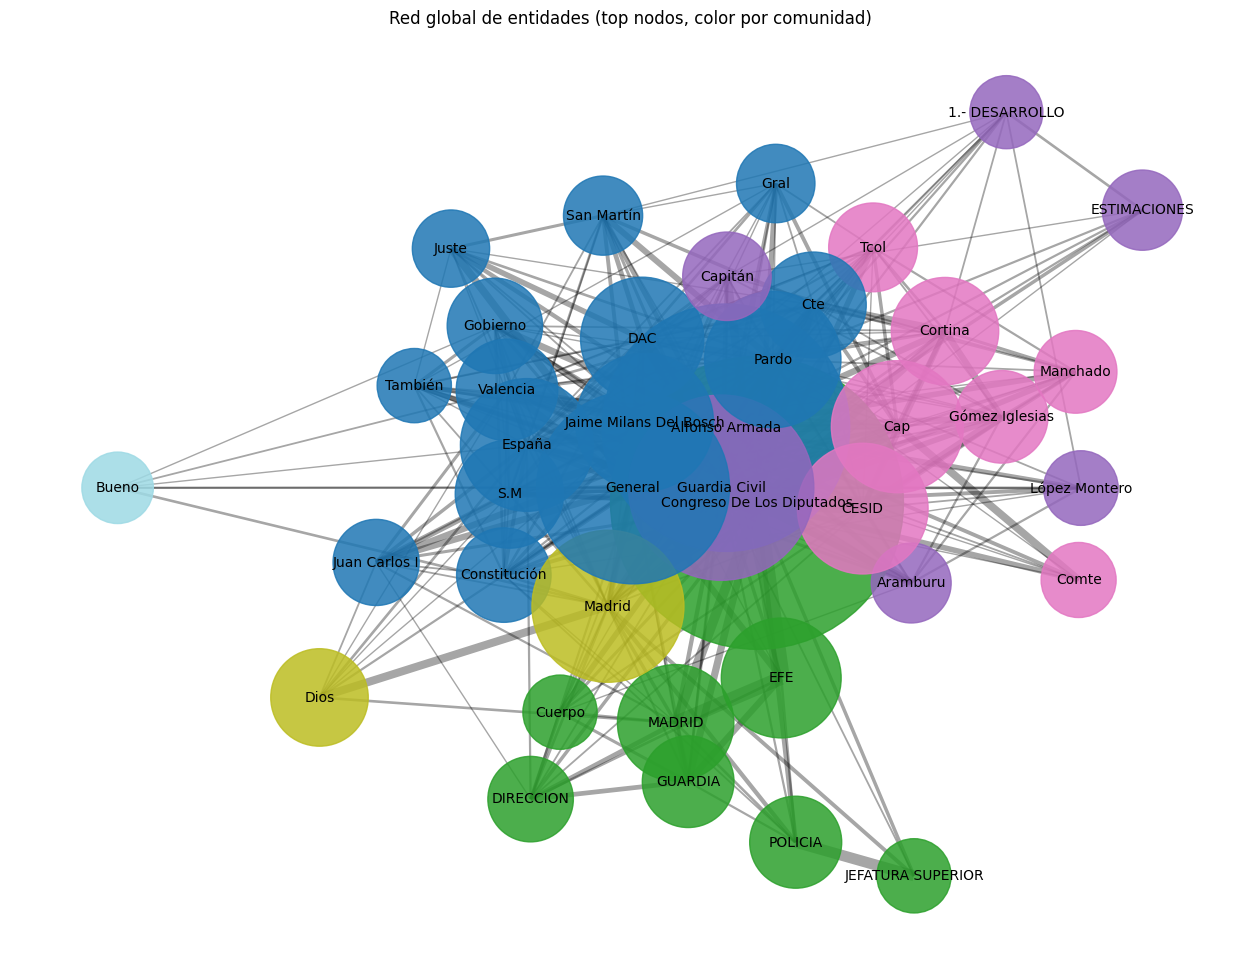

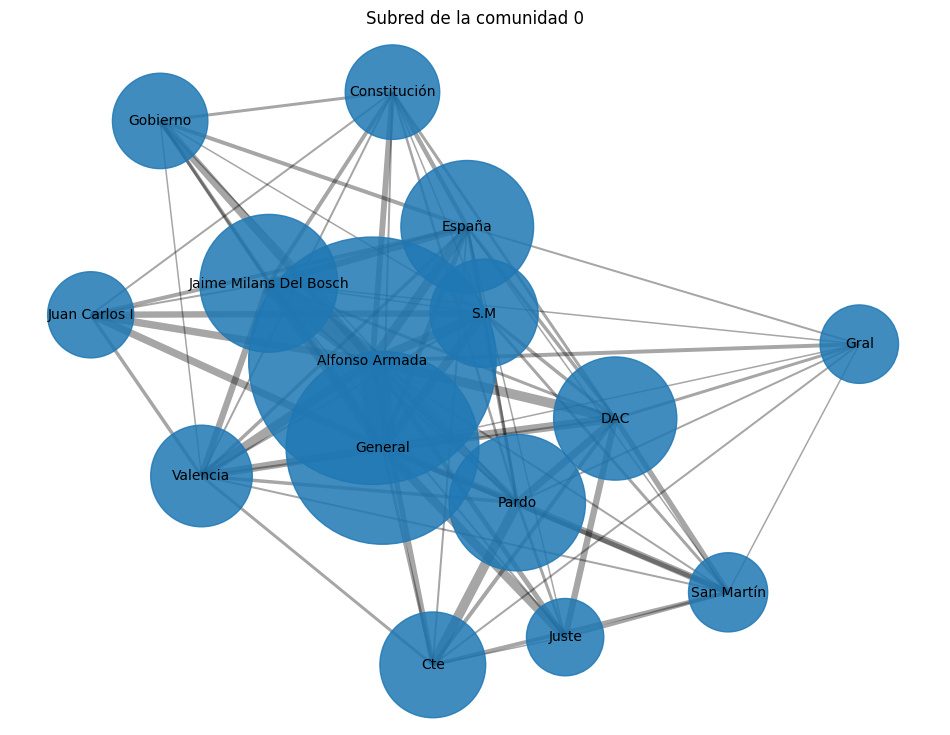

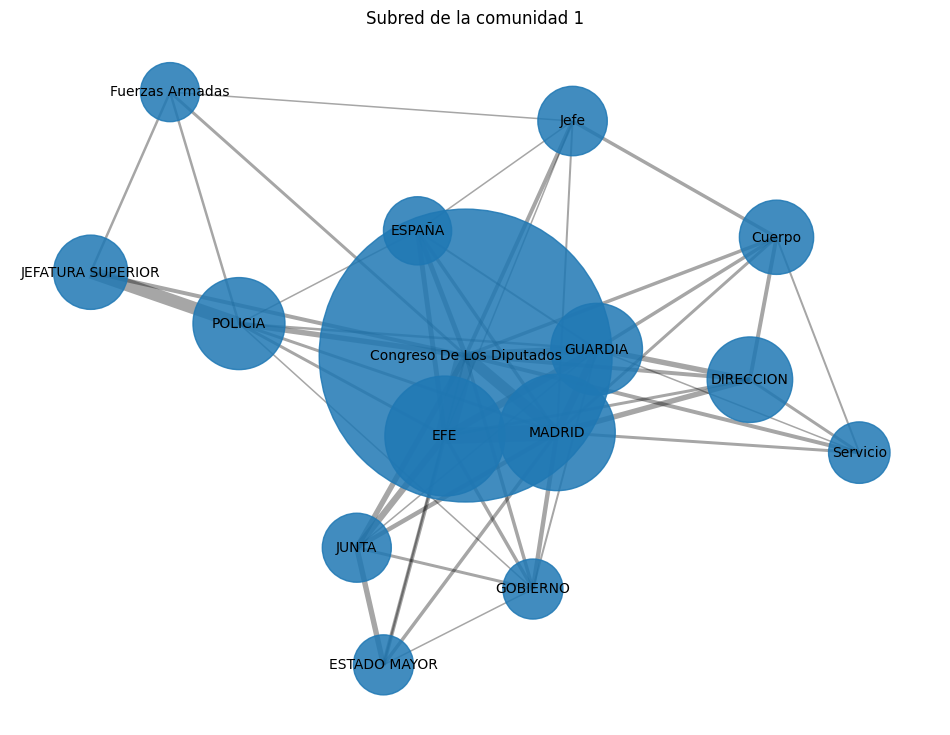

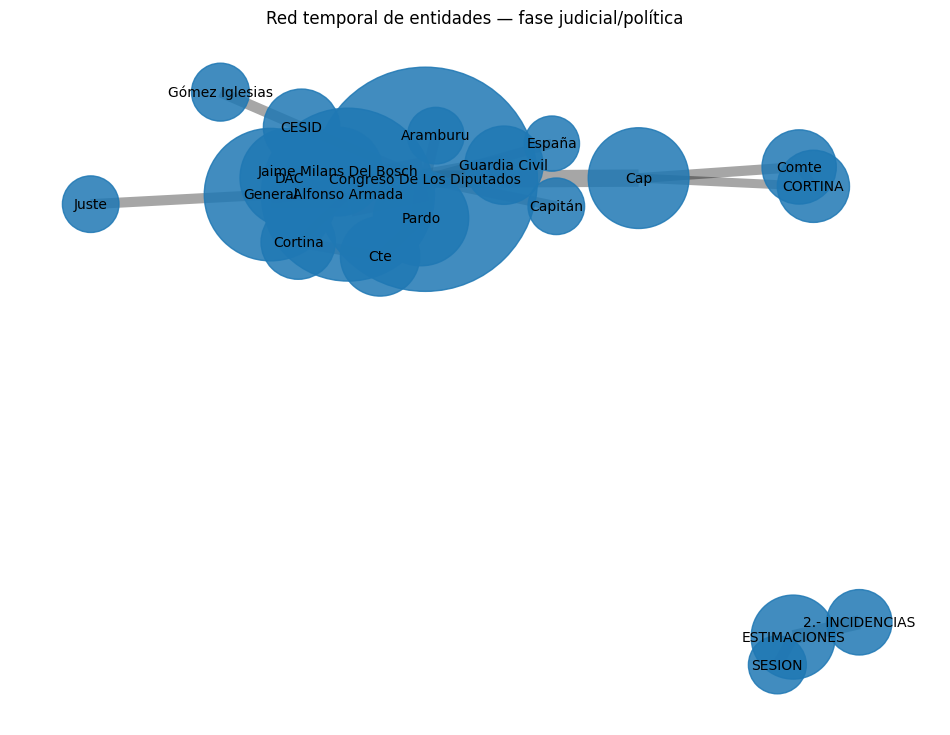

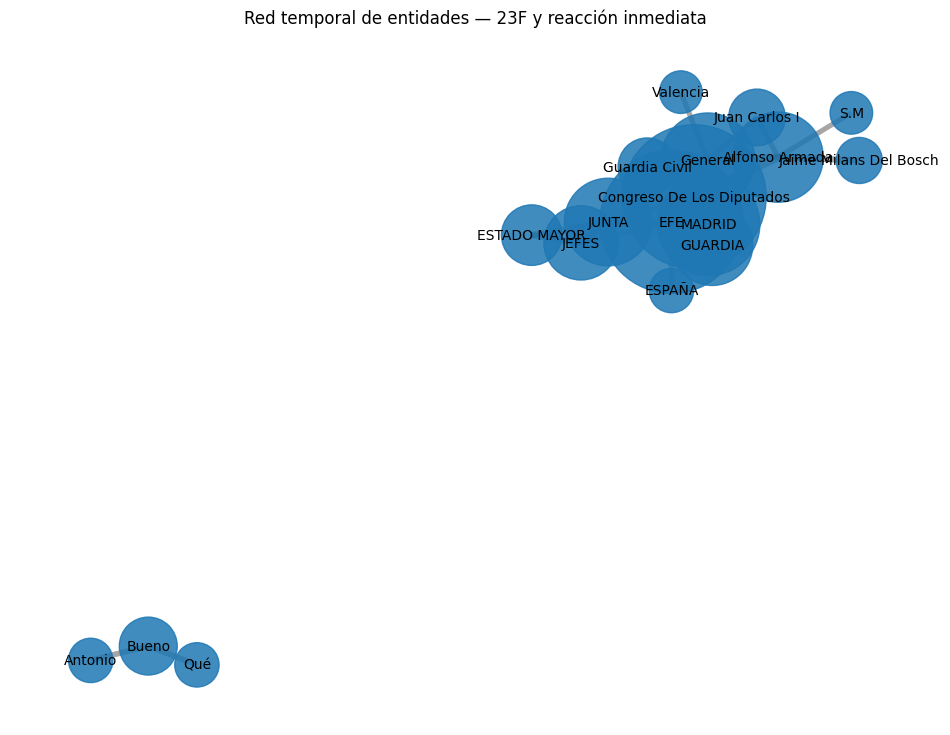

In [ ]:

# Visualización global, subredes y red temporal por fase
# Mejora:
#   - visualizamos el grafo principal con color por comunidad
#   - mostramos subredes de las comunidades principales
#   - construimos una red temporal simplificada por fase histórica

TOP_NODES = 40
top_nodes = node_df.head(TOP_NODES)["entity"].tolist()
H = G.subgraph(top_nodes).copy()

community_color_map = {
    node: node_df.set_index("entity").loc[node, "community"]
    for node in H.nodes()
}

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(H, seed=RANDOM_STATE, k=1.4 / np.sqrt(max(H.number_of_nodes(), 1)))
node_sizes = [250 + 30 * node_df.set_index("entity").loc[node, "weighted_degree"] for node in H.nodes()]
node_colors = [community_color_map.get(node, -1) for node in H.nodes()]
edge_widths = [0.4 + H[u][v].get("weight", 1) * 0.30 for u, v in H.edges()]

nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85, cmap=plt.cm.tab20)
nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_labels(H, pos, font_size=10)
plt.title("Red global de entidades (top nodos, color por comunidad)")
plt.axis("off")
plt.show()

# Subredes de las comunidades más grandes
top_communities = community_summary_df["community"].head(2).tolist()

for community_id in top_communities:
    community_nodes = node_df[node_df["community"] == community_id]["entity"].head(15).tolist()
    HC = G.subgraph(community_nodes).copy()

    if HC.number_of_nodes() == 0:
        continue

    plt.figure(figsize=(12, 9))
    pos_c = nx.spring_layout(HC, seed=RANDOM_STATE)
    node_sizes_c = [250 + 30 * node_df.set_index("entity").loc[node, "weighted_degree"] for node in HC.nodes()]
    edge_widths_c = [0.4 + HC[u][v].get("weight", 1) * 0.35 for u, v in HC.edges()]

    nx.draw_networkx_nodes(HC, pos_c, node_size=node_sizes_c, alpha=0.85)
    nx.draw_networkx_edges(HC, pos_c, width=edge_widths_c, alpha=0.35)
    nx.draw_networkx_labels(HC, pos_c, font_size=10)
    plt.title(f"Subred de la comunidad {community_id}")
    plt.axis("off")
    plt.show()

# Red temporal simplificada por fase histórica
if "pair_df" in globals() and len(pair_df) > 0:
    phase_edge_strength = (
        pair_df.groupby(["relative_phase", "source", "target"])
        .agg(weight=("window_id", "count"))
        .reset_index()
    )

    top_phases = (
        phase_edge_strength.groupby("relative_phase")["weight"]
        .sum()
        .sort_values(ascending=False)
        .head(2)
        .index
        .tolist()
    )

    for phase in top_phases:
        phase_edges = phase_edge_strength[phase_edge_strength["relative_phase"] == phase].copy()
        phase_edges = phase_edges.sort_values("weight", ascending=False).head(25)

        GP = nx.Graph()
        for _, row in phase_edges.iterrows():
            GP.add_edge(row["source"], row["target"], weight=row["weight"])

        if GP.number_of_nodes() == 0:
            continue

        plt.figure(figsize=(12, 9))
        pos_p = nx.spring_layout(GP, seed=RANDOM_STATE)
        edge_widths_p = [0.5 + GP[u][v]["weight"] * 0.4 for u, v in GP.edges()]
        node_sizes_p = [300 + 80 * GP.degree(node, weight="weight") for node in GP.nodes()]

        nx.draw_networkx_nodes(GP, pos_p, node_size=node_sizes_p, alpha=0.85)
        nx.draw_networkx_edges(GP, pos_p, width=edge_widths_p, alpha=0.35)
        nx.draw_networkx_labels(GP, pos_p, font_size=10)
        plt.title(f"Red temporal de entidades — {phase}")
        plt.axis("off")
        plt.show()


# Visualización Interactiva y Exploración Espacial del Grafo (PyVis)



**Propósito General:**
Este bloque final del **Caso de Uso 4** genera una interfaz dinámica para la exploración cualitativa de la red de entidades. A diferencia de los gráficos estáticos, esta visualización interactiva permite al investigador "navegar" por la trama del 23F, aislar nodos específicos para ver sus conexiones y comprender la arquitectura de las comunidades mediante la manipulación directa de los elementos en un entorno web embebido.



**Decisiones de Diseño:**
* **Algoritmo ForceAtlas2:** Se implementa un modelo de fuerzas físicas (atracción y repulsión) para el despliegue de los nodos. Este algoritmo es el estándar de oro en ciencia de redes, ya que logra que los nodos con alta centralidad se sitúen en el núcleo visual, mientras que las comunidades periféricas se separan de forma natural, revelando la jerarquía real del sistema.
* **Codificación Visual Proporcional:** El tamaño de cada nodo se escala dinámicamente en función de su grado (`degree`), y el grosor de las aristas según su peso (`weight`). Esto permite una jerarquización visual inmediata: los actores más grandes son los que dominan la conversación en el archivo, y las líneas más gruesas representan los vínculos con mayor soporte documental.
* **Capas de Información (Tooltips HTML):** Se inyectan metadatos complejos en el atributo `title`. Al pasar el ratón sobre un nodo, se despliegan sus métricas de centralidad e intermediación ($betweenness$), permitiendo una transición fluida entre la observación macroscópica de la red y el análisis microscópico de cada actor.
* **Interoperabilidad HTML:** El resultado se guarda como un archivo autónomo, lo que facilita su inclusión en informes externos o presentaciones interactivas, asegurando la portabilidad de los hallazgos del proyecto.

**Conexión con el Proyecto 23F:**
Esta visualización es la "sala de situación" del análisis de documentos desclasificados. Permite demostrar visualmente cómo se estructuraron las relaciones entre los asaltantes del Congreso, la cadena de mando militar y las instituciones del Estado. Es la herramienta definitiva para validar si la narrativa del 23F en el archivo de RTVE es una red cohesionada o si existen "tramas aisladas" que operaron de forma independiente. Al "tirar" de un nodo (como Tejero o Armada), el investigador puede ver físicamente cómo se arrastra el resto de la estructura, revelando la fragilidad o robustez de los vínculos que sostuvieron el relato oficial del golpe.

In [ ]:

# Visualización interactiva con PyVis
interactive_path = DATA_DIR / "red_entidades_23f.html"
net = Network(height="750px", width="100%", bgcolor="white", font_color="black")
net.force_atlas_2based()

node_lookup = node_df.set_index("entity").to_dict(orient="index")
for node in H.nodes():
    info = node_lookup.get(node, {})
    title = (
        f"<b>{node}</b><br>"
        f"Etiqueta: {info.get('label', 'NA')}<br>"
        f"Degree: {info.get('degree', 0)}<br>"
        f"Degree centrality: {info.get('degree_centrality', 0):.4f}<br>"
        f"Betweenness: {info.get('betweenness_centrality', 0):.4f}<br>"
        f"Comunidad: {info.get('community', -1)}"
    )
    net.add_node(node, label=node, title=title, value=1 + info.get("degree", 0))

for u, v, data in H.edges(data=True):
    weight = data.get("weight", 1)
    net.add_edge(u, v, value=weight, title=f"Coapariciones: {weight}")

net.save_graph(str(interactive_path))
print(f"Red interactiva guardada en: {interactive_path}")

html_content = interactive_path.read_text(encoding="utf-8")
display(HTML(html_content))


Red interactiva guardada en: /content/23f_rtve/red_entidades_23f.html


# Gestión de Evidencia Original: Descarga Automatizada de Activos (Assets)

**Propósito General:**
Este bloque actúa como el motor de **adquisición de datos binarios** del pipeline. Su función es descargar y organizar los documentos originales (PDFs, escaneos de legajos, recortes de prensa) alojados en los servidores de RTVE. Almacenar localmente estos originales permite una consulta rápida sin dependencia de red y, lo más importante, facilita la validación forense de fragmentos donde el OCR haya sido deficiente o donde la caligrafía original aporte matices que el texto plano no puede capturar.

**Decisiones de Diseño:**
* **Descarga Condicional y Resiliente:** Mediante la bandera `DOWNLOAD_ORIGINAL_ASSETS`, el script permite controlar cuándo realizar esta operación intensiva en ancho de banda. El uso de un bloque `try-except` garantiza que un error en un archivo específico (ej. un enlace roto 404) no detenga el proceso completo, registrando la anomalía en un log de auditoría.
* **Normalización de Nombres de Archivo:** El código implementa una lógica de extracción de nombres desde la URL, con un sistema de *fallback* basado en el `doc_id`. Esto asegura que cada archivo guardado en el sistema de archivos sea fácilmente rastreable y vinculable con los metadatos del DataFrame.
* **Respeto a la Infraestructura (Rate Limiting):** Se integra un retardo controlado (`REQUEST_DELAY`) entre peticiones. Esta es una decisión de ingeniería ética y técnica fundamental para evitar saturar los servidores de RTVE y prevenir bloqueos automáticos de IP durante la fase de recolección.
* **Trazabilidad Forense:** La generación automática del archivo `assets_download_log.csv` funciona como un manifiesto de carga, permitiendo una conciliación inmediata entre los documentos esperados y los descargados con éxito.



**Conexión con el Proyecto 23F:**
En la investigación histórica del 23F, el documento físico es una prueba irreemplazable. Muchos de los legajos desclasificados contienen sellos de "Secreto", firmas de militares de alto rango o diagramas operativos de despliegue de tropas que el análisis de texto plano ignora. Este bloque asegura la **preservación de la prueba documental** para el análisis cualitativo profundo, permitiendo que el investigador pueda saltar de un "clúster" detectado por la IA a la visualización directa del folio original que cambió el rumbo de la Transición española.

In [ ]:

# Descarga opcional de originales enlazados por RTVE
if DOWNLOAD_ORIGINAL_ASSETS:
    asset_dir = DATA_DIR / "originales"
    asset_dir.mkdir(parents=True, exist_ok=True)

    asset_rows = []
    for _, row in df[df["asset_urls"].str.len() > 0].iterrows():
        urls = [u.strip() for u in row["asset_urls"].split("|") if u.strip()]
        for asset_url in urls:
            filename = Path(asset_url.split("?")[0]).name or f"doc_{row['doc_id']}"
            out_path = asset_dir / filename
            try:
                response = session.get(asset_url, timeout=TIMEOUT)
                response.raise_for_status()
                out_path.write_bytes(response.content)
                asset_rows.append({"doc_id": row["doc_id"], "asset_url": asset_url, "saved_to": str(out_path)})
            except Exception as exc:
                asset_rows.append({"doc_id": row["doc_id"], "asset_url": asset_url, "saved_to": f"ERROR: {exc}"})
            time.sleep(REQUEST_DELAY)

    assets_log = pd.DataFrame(asset_rows)
    assets_log.to_csv(DATA_DIR / "assets_download_log.csv", index=False)
    display(assets_log.head(20))
else:
    print("DOWNLOAD_ORIGINAL_ASSETS = False. No se han descargado los originales.")


DOWNLOAD_ORIGINAL_ASSETS = False. No se han descargado los originales.


# 4. Integración de Resultados: Triangulación y Síntesis Analítica

**Propósito General:**
Este bloque representa la "fase de síntesis" de todo el proyecto. Su objetivo es realizar una triangulación de datos entre los cuatro casos de uso anteriores (**Temas, Evolución, Clustering y Redes**). Al cruzar estas dimensiones, el sistema deja de ver los documentos como registros aislados y empieza a entender el archivo como un ecosistema donde la calidad del OCR, la procedencia institucional y la fase histórica determinan la narrativa capturada por la IA.



**Decisiones de Diseño:**
* **Heurística de Dominancia de Captura:** Se implementa un motor de decisión que evalúa qué "manda" en cada clúster (¿es un tema, una institución o una fase?). Si ninguna categoría supera el 45% de representatividad, el clúster se etiqueta como **"mixto/difuso"**. Esta es una decisión de **honestidad analítica** que evita forzar interpretaciones donde los datos sugieren hibridación.
* **Control de Calidad Transversal:** Se integran las métricas de OCR (`ocr_quality_score`) en los clústeres y tópicos. Esto permite detectar si ciertos temas (ej. "Justicia Militar") tienen una calidad inferior debido al estado de los legajos originales, lo que podría sesgar las conclusiones del análisis léxico.
* **Análisis de Centralidad Evolutiva:** A diferencia del Caso 4, aquí la centralidad de los actores se calcula **por cada fase histórica**. Esto permite observar dinámicamente cómo personajes que eran centrales en la "Reacción inmediata" (ej. Tejero) pierden peso frente a actores de la "Fase judicial" (ej. abogados o jueces), permitiendo un análisis de redes de cuatro dimensiones.
* **Matrices de Contingencia (Crosstabs) Normalizadas:** Se generan tablas cruzadas que relacionan cada clúster con su tópico dominante. Esto valida si el clustering no supervisado (basado en vectores) ha convergido con el modelado de tópicos (basado en probabilidades), actuando como una prueba de consistencia interna del modelo.

**Conexión con el Proyecto 23F:**
Esta sección es la que construye la "Gran Narrativa" para la memoria del proyecto. En el contexto del 23F, nos permite responder con evidencia estadística a preguntas complejas: *¿Están los documentos del CESID concentrados en un tópico de "inteligencia" o se diluyen en la "burocracia judicial"? ¿Quiénes fueron los protagonistas reales de la red de relaciones durante los "Días posteriores"?* Al exportar estos resultados a CSVs integrados, transformamos el caos de miles de folios desclasificados en una base de datos científica lista para la defensa del proyecto, demostrando cómo la inteligencia artificial puede actuar como una lupa de precisión sobre la historia de la Transición española.

In [ ]:
# ============================================================
# SECCIÓN 4. INTEGRACIÓN DE RESULTADOS
# Objetivo:
#   - cruzar temas, clusters, organismos, fases y calidad OCR
#   - detectar si los distintos casos convergen entre sí
#   - producir tablas integradas para la memoria y la defensa
# ============================================================

# ------------------------------------------------------------
# Validaciones mínimas
# ------------------------------------------------------------
if "cluster_df" not in globals():
    raise ValueError(
        "No existe 'cluster_df'. Ejecuta antes el Caso 3 (clustering)."
    )

if "entity_df" not in globals():
    raise ValueError(
        "No existe 'entity_df'. Ejecuta antes el Caso 4 (red de entidades)."
    )

integration_df = cluster_df.copy()

# ------------------------------------------------------------
# Incorporar información del Caso 2 si todavía no está en cluster_df
# ------------------------------------------------------------
if "dominant_topic" not in integration_df.columns:
    if "df_time" in globals() and {"doc_id", "dominant_topic"}.issubset(df_time.columns):
        topic_cols = [
            c for c in [
                "doc_id",
                "dominant_topic",
                "dominant_topic_id",
                "dominant_topic_strength",
                "topic_margin",
                "relative_phase",
            ]
            if c in df_time.columns
        ]
        topic_aux = df_time[topic_cols].drop_duplicates(subset=["doc_id"]).copy()

        for col in topic_aux.columns:
            if col != "doc_id" and col in integration_df.columns:
                integration_df = integration_df.drop(columns=[col])

        integration_df = integration_df.merge(topic_aux, on="doc_id", how="left")
    else:
        integration_df["dominant_topic"] = "sin topic"

# ------------------------------------------------------------
# Columnas auxiliares y fallbacks por si alguna mejora previa
# aún no se ha incorporado
# ------------------------------------------------------------
if "dominant_topic" not in integration_df.columns:
    integration_df["dominant_topic"] = "sin topic"
integration_df["dominant_topic"] = integration_df["dominant_topic"].fillna("sin topic")

if "dominant_topic_strength" not in integration_df.columns:
    integration_df["dominant_topic_strength"] = np.nan

if "topic_margin" not in integration_df.columns:
    integration_df["topic_margin"] = np.nan

if "organismo" not in integration_df.columns:
    integration_df["organismo"] = "No identificado"
integration_df["organismo"] = integration_df["organismo"].fillna("No identificado")

if "tipo_documental" not in integration_df.columns:
    integration_df["tipo_documental"] = "No identificado"
integration_df["tipo_documental"] = integration_df["tipo_documental"].fillna("No identificado")

if "relative_phase" not in integration_df.columns:
    if "date" in integration_df.columns:
        integration_df["relative_phase"] = integration_df["date"].map(assign_relative_phase)
    else:
        integration_df["relative_phase"] = "sin fecha"
integration_df["relative_phase"] = integration_df["relative_phase"].fillna("sin fecha")

if "quality_label" not in integration_df.columns:
    integration_df["quality_label"] = "desconocida"
integration_df["quality_label"] = integration_df["quality_label"].fillna("desconocida")

if "ocr_quality_score" not in integration_df.columns:
    integration_df["ocr_quality_score"] = np.nan

# ------------------------------------------------------------
# Función auxiliar para resumir dominancias
# ------------------------------------------------------------
def mode_share(series, default_value="sin dato"):
    """
    Devuelve la categoría más frecuente y su proporción relativa.
    """
    s = series.fillna(default_value).astype(str)
    if len(s) == 0:
        return default_value, 0.0

    vc = s.value_counts(normalize=True)
    return vc.index[0], float(vc.iloc[0])

# ------------------------------------------------------------
# Tabla integrada por cluster
# Responde a:
#   - ¿cada cluster se alinea con un topic?
#   - ¿captura institución, tipo documental, fase o tema?
#   - ¿la baja calidad OCR se concentra en ciertos clusters?
# ------------------------------------------------------------
integration_rows = []

for cluster_id in sorted(integration_df["cluster"].dropna().unique()):
    cluster_slice = integration_df[integration_df["cluster"] == cluster_id].copy()

    top_topic, top_topic_share = mode_share(cluster_slice["dominant_topic"], "sin topic")
    top_org, top_org_share = mode_share(cluster_slice["organismo"], "No identificado")
    top_type, top_type_share = mode_share(cluster_slice["tipo_documental"], "No identificado")
    top_phase, top_phase_share = mode_share(cluster_slice["relative_phase"], "sin fecha")
    top_quality, top_quality_share = mode_share(cluster_slice["quality_label"], "desconocida")

    dominance_scores = {
        "tema": top_topic_share if top_topic != "sin topic" else 0.0,
        "institución": top_org_share,
        "tipo documental": top_type_share,
        "fase": top_phase_share,
    }

    capture_type, capture_strength = max(dominance_scores.items(), key=lambda x: x[1])
    if capture_strength < 0.45:
        capture_type = "mixto / difuso"

    integration_rows.append({
        "cluster": cluster_id,
        "n_documentos": int(len(cluster_slice)),
        "topic_predominante": top_topic,
        "share_topic_predominante": round(top_topic_share, 3),
        "organismo_predominante": top_org,
        "share_organismo_predominante": round(top_org_share, 3),
        "tipo_documental_predominante": top_type,
        "share_tipo_documental_predominante": round(top_type_share, 3),
        "fase_predominante": top_phase,
        "share_fase_predominante": round(top_phase_share, 3),
        "calidad_mas_frecuente": top_quality,
        "share_calidad_mas_frecuente": round(top_quality_share, 3),
        "pct_baja_calidad": round(100 * (cluster_slice["quality_label"] == "baja").mean(), 2),
        "ocr_quality_media": round(float(cluster_slice["ocr_quality_score"].mean()), 4) if cluster_slice["ocr_quality_score"].notna().any() else np.nan,
        "fuerza_media_topic": round(float(cluster_slice["dominant_topic_strength"].mean()), 4) if cluster_slice["dominant_topic_strength"].notna().any() else np.nan,
        "margen_medio_topic": round(float(cluster_slice["topic_margin"].mean()), 4) if cluster_slice["topic_margin"].notna().any() else np.nan,
        "captura_probable": capture_type,
    })

integration_summary_df = pd.DataFrame(integration_rows).sort_values("cluster")

# ------------------------------------------------------------
# Tablas cruzadas principales
# ------------------------------------------------------------
top_organismos = (
    integration_df["organismo"]
    .fillna("No identificado")
    .value_counts()
    .head(8)
    .index
)

integration_df["organismo_grouped"] = integration_df["organismo"].where(
    integration_df["organismo"].isin(top_organismos),
    "Otros"
)

cluster_topic_crosstab = pd.crosstab(
    integration_df["cluster"],
    integration_df["dominant_topic"],
    normalize="index"
).round(3)

cluster_org_crosstab = pd.crosstab(
    integration_df["cluster"],
    integration_df["organismo_grouped"],
    normalize="index"
).round(3)

cluster_type_crosstab = pd.crosstab(
    integration_df["cluster"],
    integration_df["tipo_documental"],
    normalize="index"
).round(3)

cluster_phase_crosstab = pd.crosstab(
    integration_df["cluster"],
    integration_df["relative_phase"],
    normalize="index"
).round(3)

cluster_quality_crosstab = pd.crosstab(
    integration_df["cluster"],
    integration_df["quality_label"],
    normalize="index"
).round(3)

topic_quality_crosstab = pd.crosstab(
    integration_df["dominant_topic"],
    integration_df["quality_label"],
    normalize="index"
).round(3)

topic_phase_crosstab = pd.crosstab(
    integration_df["dominant_topic"],
    integration_df["relative_phase"],
    normalize="index"
).round(3)

# ------------------------------------------------------------
# Calidad OCR por cluster y por topic
# ------------------------------------------------------------
quality_by_cluster_df = (
    integration_df.groupby("cluster")
    .agg(
        n_documentos=("doc_id", "nunique"),
        pct_baja_calidad=("quality_label", lambda s: round(100 * (s == "baja").mean(), 2)),
        pct_media_calidad=("quality_label", lambda s: round(100 * (s == "media").mean(), 2)),
        ocr_quality_media=("ocr_quality_score", "mean"),
    )
    .reset_index()
)

quality_by_topic_df = (
    integration_df.groupby("dominant_topic")
    .agg(
        n_documentos=("doc_id", "nunique"),
        pct_baja_calidad=("quality_label", lambda s: round(100 * (s == "baja").mean(), 2)),
        pct_media_calidad=("quality_label", lambda s: round(100 * (s == "media").mean(), 2)),
        ocr_quality_media=("ocr_quality_score", "mean"),
    )
    .reset_index()
    .sort_values("n_documentos", ascending=False)
)

# ------------------------------------------------------------
# Entidades centrales por fase
# Si existe pair_df (mejora previa del Caso 4), usamos centralidad local.
# Si no, usamos frecuencia documental por fase como fallback.
# ------------------------------------------------------------
phase_central_entities_df = pd.DataFrame()

if "pair_df" in globals() and len(pair_df) > 0:
    phase_rows = []

    for phase, phase_pairs in pair_df.groupby("relative_phase"):
        local_pairs = (
            phase_pairs.groupby(["source", "target"])
            .agg(weight=("window_id", "count"), doc_support=("doc_id", "nunique"))
            .reset_index()
        )

        GP = nx.Graph()
        for _, row in local_pairs.iterrows():
            GP.add_edge(
                row["source"],
                row["target"],
                weight=int(row["weight"]),
                doc_support=int(row["doc_support"]),
            )

        if GP.number_of_nodes() == 0:
            continue

        local_betweenness = nx.betweenness_centrality(GP, weight="weight", normalized=True)
        local_weighted_degree = dict(GP.degree(weight="weight"))

        for node in GP.nodes():
            phase_rows.append({
                "relative_phase": phase,
                "entity": node,
                "weighted_degree": local_weighted_degree.get(node, 0),
                "betweenness_centrality": local_betweenness.get(node, 0.0),
            })

    if len(phase_rows) > 0:
        phase_central_entities_df = (
            pd.DataFrame(phase_rows)
            .sort_values(["relative_phase", "weighted_degree", "betweenness_centrality"], ascending=[True, False, False])
            .groupby("relative_phase")
            .head(10)
            .reset_index(drop=True)
        )

if phase_central_entities_df.empty:
    phase_central_entities_df = (
        entity_df.groupby(["relative_phase", "entity"])
        .agg(doc_support=("doc_id", "nunique"))
        .reset_index()
        .sort_values(["relative_phase", "doc_support"], ascending=[True, False])
        .groupby("relative_phase")
        .head(10)
        .reset_index(drop=True)
    )

# ------------------------------------------------------------
# Mostrar resultados integrados
# ------------------------------------------------------------
display(integration_summary_df)

display(cluster_topic_crosstab)
display(cluster_org_crosstab)
display(cluster_type_crosstab)
display(cluster_phase_crosstab)
display(cluster_quality_crosstab)

display(topic_quality_crosstab)
display(topic_phase_crosstab)

display(quality_by_cluster_df)
display(quality_by_topic_df)

display(phase_central_entities_df)

# Guardado opcional para la memoria / anexo
integration_summary_path = DATA_DIR / "integration_summary.csv"
quality_cluster_path = DATA_DIR / "quality_by_cluster.csv"
quality_topic_path = DATA_DIR / "quality_by_topic.csv"
phase_entities_path = DATA_DIR / "phase_central_entities.csv"

integration_summary_df.to_csv(integration_summary_path, index=False)
quality_by_cluster_df.to_csv(quality_cluster_path, index=False)
quality_by_topic_df.to_csv(quality_topic_path, index=False)
phase_central_entities_df.to_csv(phase_entities_path, index=False)

print(f"Resumen de integración guardado en: {integration_summary_path}")
print(f"Calidad por cluster guardada en: {quality_cluster_path}")
print(f"Calidad por topic guardada en: {quality_topic_path}")
print(f"Entidades por fase guardadas en: {phase_entities_path}")

,cluster,n_documentos,topic_predominante,share_topic_predominante,organismo_predominante,share_organismo_predominante,tipo_documental_predominante,share_tipo_documental_predominante,fase_predominante,share_fase_predominante,calidad_mas_frecuente,share_calidad_mas_frecuente,pct_baja_calidad,ocr_quality_media,fuerza_media_topic,margen_medio_topic,captura_probable
0,0,44,general / coronel / teniente / armada,0.795,Consejo Supremo de Justicia Militar,0.136,Vista oral 2/81,0.932,fase judicial/política,0.955,alta,1.000,0.0,0.0000,NaN,NaN,fase
1,1,27,exteriores / asuntos exteriores / asuntos / españa,0.556,Ministerio de Asuntos Exteriores de España,0.111,Ambiente en los cuarteles,0.037,días posteriores,0.444,media,0.556,0.0,0.1352,NaN,NaN,tema
2,2,68,golpe / img / img jpeg / jpeg,0.515,documento,0.074,Información integrada,0.074,fase judicial/política,0.515,alta,0.676,0.0,0.0397,NaN,NaN,tema
3,3,19,excmo / excmo señor / señor / jpeg,0.895,Consejo Supremo de Justicia Militar,0.158,RESERVADO: comunicación procesamiento implicado.,0.316,fase judicial/política,0.684,media,0.842,0.0,0.2395,NaN,NaN,tema
4,4,9,the / and / spain / you,0.667,Parlamento británico y del Partido Laborista tras el intento de golpe de Estado en España el,0.111,D.31. AGA-83-09301 exp. 5,0.111,días posteriores,0.444,alta,0.556,0.0,0.0389,NaN,NaN,tema


dominant_topic,excmo / excmo señor / señor / jpeg,exteriores / asuntos exteriores / asuntos / españa,general / coronel / teniente / armada,golpe / img / img jpeg / jpeg,gral / gral armada / tcol / armada,sin topic,the / and / spain / you
cluster,,,,,,,
0,0.000,0.000,0.795,0.000,0.205,0.000,0.000
1,0.037,0.556,0.000,0.259,0.000,0.148,0.000
2,0.044,0.015,0.118,0.515,0.044,0.265,0.000
3,0.895,0.000,0.000,0.000,0.000,0.105,0.000
4,0.000,0.000,0.000,0.000,0.000,0.333,0.667


organismo_grouped,Armada,CESID,Consejo Supremo de Justicia Militar,Consejo Supremo de Justicia Militar en marzo de,Ministerio de Asuntos Exteriores de España,Ministerio de Defensa,Ministerio del Interior,Otros,documento
cluster,,,,,,,,,
0,0.023,0.023,0.136,0.045,0.000,0.000,0.000,0.659,0.114
1,0.037,0.000,0.000,0.000,0.111,0.037,0.000,0.815,0.000
2,0.044,0.059,0.059,0.000,0.000,0.044,0.029,0.691,0.074
3,0.000,0.000,0.158,0.000,0.000,0.158,0.000,0.684,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000


tipo_documental,"""Documentación con una presunta planificación","""Estado de opinión sobre las sentencias (sección de contrainformación","""Guión que sirvió de base para la reunión de S.M. el Rey con el Presidente","""Informe","""Interesando comparecencia","""Juicio","""Nota","""Nota """"Campaña contra S.M."""" (sin firma).""","""Nota """"Involucionismo político provocado por posible golpe militar"""" (sin firma).""","""Nota """"Posible golpe de estado"""" (sin firma).""",...,Sobre la anunciada libertad provisional de algunos procesados en la causa 2/81,Solicitando datos sobre el Cte. Cortina y equipos de transmisiones,Transcripción de cintas grabadas con conversaciones telefónicas con varias personas intervenidas a la esposa de Tejero.,Transcripción de conversación telefónica de (presuntamente) García Carres y Tejero mientras (posiblemente) el segundo se encontraba dentro,Transcripción de conversación telefónica de García Carres con otra persona después,Traslado de un escrito.,Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando,Vista oral 2/81,Vista oral 2/81. Incidentes en la tarde,Índices de subversión en las FAS. Marca: SECRETO
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.023,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.932,0.023,0.000
1,0.000,0.000,0.037,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.015,0.015,0.000,0.044,0.015,0.015,0.015,0.000,0.015,0.015,...,0.015,0.015,0.015,0.015,0.015,0.000,0.015,0.059,0.000,0.015
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.053,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


relative_phase,23F y reacción inmediata,días posteriores,fase judicial/política,previa al 23F,sin fecha
cluster,,,,,
0,0.045,0.000,0.955,0.000,0.000
1,0.037,0.444,0.370,0.000,0.148
2,0.074,0.088,0.515,0.059,0.265
3,0.053,0.158,0.684,0.000,0.105
4,0.222,0.444,0.000,0.000,0.333


...

relative_phase,23F y reacción inmediata,días posteriores,fase judicial/política,previa al 23F,sin fecha
dominant_topic,,,,,
excmo / excmo señor / señor / jpeg,0.048,0.143,0.810,0.000,0.0
exteriores / asuntos exteriores / asuntos / españa,0.062,0.688,0.250,0.000,0.0
general / coronel / teniente / armada,0.070,0.000,0.930,0.000,0.0
golpe / img / img jpeg / jpeg,0.095,0.167,0.643,0.095,0.0
gral / gral armada / tcol / armada,0.000,0.000,1.000,0.000,0.0
sin topic,0.000,0.000,0.000,0.000,1.0
the / and / spain / you,0.333,0.667,0.000,0.000,0.0


,cluster,n_documentos,pct_baja_calidad,pct_media_calidad,ocr_quality_media
0,0,44,0.0,0.00,0.000000
1,1,27,0.0,55.56,0.135185
2,2,68,0.0,32.35,0.039706
3,3,19,0.0,84.21,0.239474
4,4,9,0.0,44.44,0.038889


,dominant_topic,n_documentos,pct_baja_calidad,pct_media_calidad,ocr_quality_media
2,general / coronel / teniente / armada,43,0.0,4.65,0.000000
3,golpe / img / img jpeg / jpeg,42,0.0,38.10,0.053571
5,sin topic,27,0.0,40.74,0.051852
0,excmo / excmo señor / señor / jpeg,21,0.0,85.71,0.261905
1,exteriores / asuntos exteriores / asuntos / españa,16,0.0,43.75,0.109375
4,gral / gral armada / tcol / armada,12,0.0,0.00,0.000000
6,the / and / spain / you,6,0.0,50.00,0.058333


,relative_phase,entity,weighted_degree,betweenness_centrality
0,23F y reacción inmediata,Congreso De Los Diputados,362,0.144656
1,23F y reacción inmediata,EFE,259,0.007057
2,23F y reacción inmediata,Alfonso Armada,209,0.102215
3,23F y reacción inmediata,General,205,0.091554
4,23F y reacción inmediata,Guardia Civil,178,0.100937
5,23F y reacción inmediata,MADRID,175,0.024161
6,23F y reacción inmediata,España,132,0.058951
7,23F y reacción inmediata,GUARDIA,105,0.011304
8,23F y reacción inmediata,Jaime Milans Del Bosch,101,0.050827
9,23F y reacción inmediata,Madrid,99,0.048576


Resumen de integración guardado en: /content/23f_rtve/integration_summary.csv
Calidad por cluster guardada en: /content/23f_rtve/quality_by_cluster.csv
Calidad por topic guardada en: /content/23f_rtve/quality_by_topic.csv
Entidades por fase guardadas en: /content/23f_rtve/phase_central_entities.csv


# 5. Cierre e interpretación sugerida

Con la sección anterior, el notebook ya no presenta los casos como bloques aislados, sino como un sistema analítico integrado.

### Qué permite responder la integración

- si ciertos **topics** se concentran en determinados **clusters**;
- si algunos **clusters** parecen capturar sobre todo **tema**, **institución**, **tipo documental** o **fase histórica**;
- si las **entidades centrales** cambian entre la fase previa al 23F, la reacción inmediata, los días posteriores y la fase judicial/política;
- y si la **calidad OCR** afecta de forma desigual a ciertos topics o clusters.

### Cómo interpretar los cruces

1. Si un cluster concentra a la vez un mismo **topic**, un mismo **organismo** y una misma **fase**, la estructura interna del corpus es más robusta.
2. Si un cluster tiene top terms coherentes pero mezcla muchos organismos, fases y topics, probablemente captura un **estilo documental** o una zona híbrida del corpus.
3. Si la **baja calidad OCR** se concentra en algunos clusters o topics, sus resultados deben leerse con mayor cautela.
4. En la red de entidades, una coaparición no implica por sí sola una relación histórica causal: debe interpretarse como **proximidad documental**, no como vínculo definitivo.

### Mejoras futuras recomendadas

1. Validar manualmente una muestra estratificada de documentos por **cluster**, **topic** y **fase**.
2. Contrastar **NMF** con métodos alternativos de modelado temático.
3. Comparar **KMeans** con **HDBSCAN** o clustering jerárquico.
4. Refinar la normalización manual de entidades y, si fuera posible, incorporar **entity linking**.
5. Profundizar en la integración temporal construyendo redes por ventanas cronológicas más finas.

### Por qué es importante
La memoria insiste en que los casos no deben leerse como bloques aislados. Esta sección convierte el notebook en un análisis realmente integrado y alineado con el entregable.